In [1]:
from scipy.optimize import minimize
from scipy.optimize import direct, Bounds
from smooth_POD_ROM.post_processing import richardson_lucy
from smooth_POD_ROM.pre_processing import smoothen_rowwise
from smooth_POD_ROM.initial_conditions import rectangular_pulse, rect_pulse_sin, saw_tooth, triangle, small_saw_tooth, small_r_pulse
from smooth_POD_ROM.reduced_order_model import optimize_hyperparameters, optimize_sROM, optimize_sROMs_naive, target_function, get_predictions
from smooth_POD_ROM.reduced_order_model import make_data_rw, train_ROM_rw, L2_error_rw, get_data_rw, L1_error_rw
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
cmap = plt.colormaps.get_cmap("plasma")
single_column = 90  # mm
font_size_normal = 8

single_column_in = single_column/10/2.54
single_column_figure = (single_column_in, single_column_in/1.618)

plt.rcParams['font.size'] = font_size_normal
plt.rcParams["figure.figsize"] = single_column_figure

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['legend.labelspacing'] = 0.25
plt.rcParams['legend.handlelength'] = 1.5
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=font_size_normal, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 40

In [3]:
def very_small_r_pulse(x, mu):
    return rectangular_pulse(x, mu, w=0.01)

def medium_r_pulse(x, mu):
    return rectangular_pulse(x, mu, w=0.02)

def step(x, mu, w=0.075 + 1e-6, periodic=True):
    y = np.zeros_like(x, dtype=np.float64)
    y[(x > mu)] = 1.0
    return y


def small_amp_pulse(x, mu):
    return rectangular_pulse(x, mu, w=0.075 + 1e-6)/100


ic = lambda x, mu : saw_tooth(x, mu, w=0.1)
#ic = lambda x, mu : rectangular_pulse(x, mu, w=0.1)


n_x = 1000
x = np.linspace(0, 1, n_x, endpoint=False)
case = {
    "n_x": n_x,
    "shape": x.shape,
    "x": x,
    "dx": x[1] - x[0],

    "n_train": 50,
    "n_test": 25,  # 25
    "g": ic, #small_saw_tooth, #saw_tooth, #rectangular_pulse,step
    "truncate": 12,
    "sigma": 0.08,

    "c": 1,
    "monitor_progress_postprocessing": False,
    "num_iter": 100,
    "monitor_convergence": False,
    "sROM_only": False,
    "sigmaD": "calc_based_on_distance",
}

In [4]:
# d = 0.01
# N1 = f1(x, 0.5-d, w=0.1)  
# N2 = f1(x, 0.5+d, w=0.1)  
# N3 = f1(x, 0.5, w=0.1) 
1/0.02

50.0

In [5]:
n_train = rank = 50
case["rank"] = rank
case["n_train"] = n_train
parameters = optimize_hyperparameters(case)


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:34: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 50, 25, 0.01050000, 1.00000000, 0.05085533, 0.05592198, 0.03750087, -26.2597
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 50, 25, 0.01683333, 1.00000000, 0.05085533, 0.06689625, 0.06108432, 20.1139
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 50, 25, 0.00416667, 1.00000000, 0.05085533, 0.04768302, 0.05846479, 14.9630
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 50, 25, 0.01050000, 1.66666667, 0.05085533, 0.05592198, 0.05203489, 2.3194
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 50, 25, 0.01050000, 0.33333333, 0.05085533, 0.05592198, 0.04114999, -19.0842
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 50, 25, 0.01683333, 0.33333333, 0.050

In [6]:
case["sigma"], case["c"] = parameters[0], parameters[1]

sigma_S, c = case["sigma"], case["c"]
sigma_S=0.009088
sigma_D=0.01291

case["n_test"] = 5
mu_train, X_train, X_train_s = make_data_rw([0], [1], n_samples=case["n_train"], **case)
mu_test, X_test, X_test_s = make_data_rw(mu_train[n_train//2], mu_train[n_train//2+1], n_samples=case["n_test"], **case)
my_ROM = train_ROM_rw(mu_train, X_train)
my_sROM = train_ROM_rw(mu_train, X_train_s)

X_test_ROM = my_ROM.predict(mu_test).snapshots_matrix
X_test_sROM, X_test_sROMs = get_predictions(my_sROM, mu_test, **case)

In [7]:

i1 = n_train//2

N1 = X_train[i1]
N2 = X_train[i1+1]
N3 = X_test[3]

N1_s = X_train_s[i1]
N2_s = X_train_s[i1+1]
N3_s = X_test_s[3]

N3_hat = X_test_ROM[3]
N3_s_hat = X_test_sROM[3]

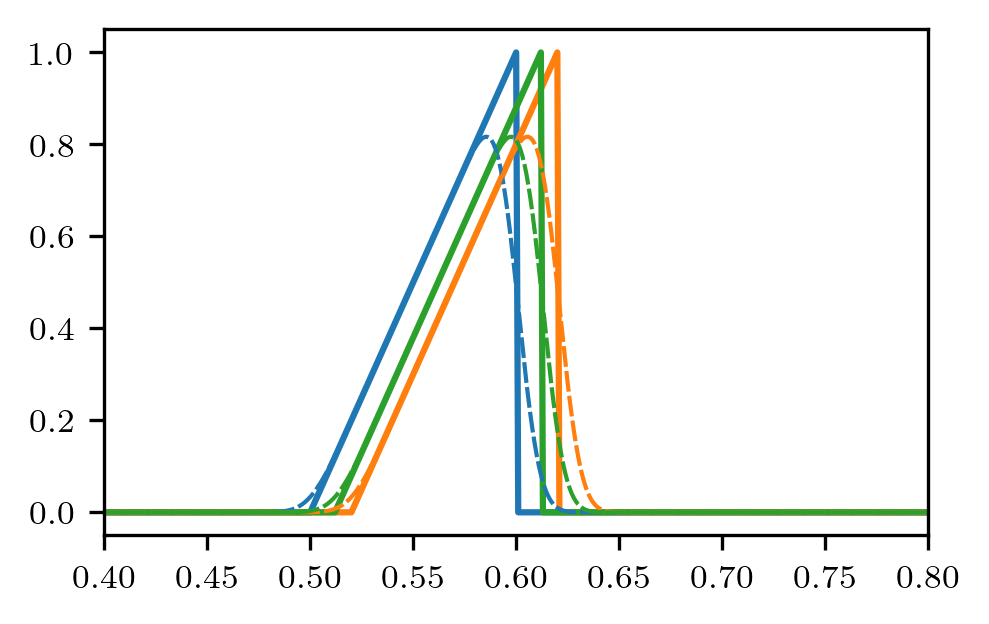

In [8]:
fig, ax = plt.subplots()
plt.plot(x, N1)
plt.plot(x, N2)
plt.plot(x, N3)

plt.plot(x, N1_s, "C0", ls=(0, (5, 1)), lw=1)
plt.plot(x, N2_s, "C1", ls=(0, (5, 1)), lw=1)
plt.plot(x, N3_s, "C2", ls=(0, (5, 1)), lw=1)
#plt.plot(x, res, "C3", ls=(0, (5, 1)), lw=1)
plt.xlim([0.4, 0.8])
plt.show()

# sharpening multiplier

In [9]:
def gaussian(x, sigma, shift=True):
    print("get g")
    dx = x[1]-x[0]
    A = dx/(sigma*(2*np.pi)**.5)
    return A * np.exp(-x**2 / (2 * sigma**2))

def riemann_sum_equispaced(x, y):
    """calc are under curve to estimate mass conservation"""
    dx = np.mean(np.diff(x))
    return np.sum(dx*y)

0.009088
get g
get g
get g
1.8019365711209143
1.7663546548962696
1.7778903574566518
1.8356555981811697
1.9355156477960331
riemann 0.050499999999999955
riemann 0.050499999999999955
riemann 0.050499999999999955
riemann 0.050499999999999955
riemann 0.050499999999999955


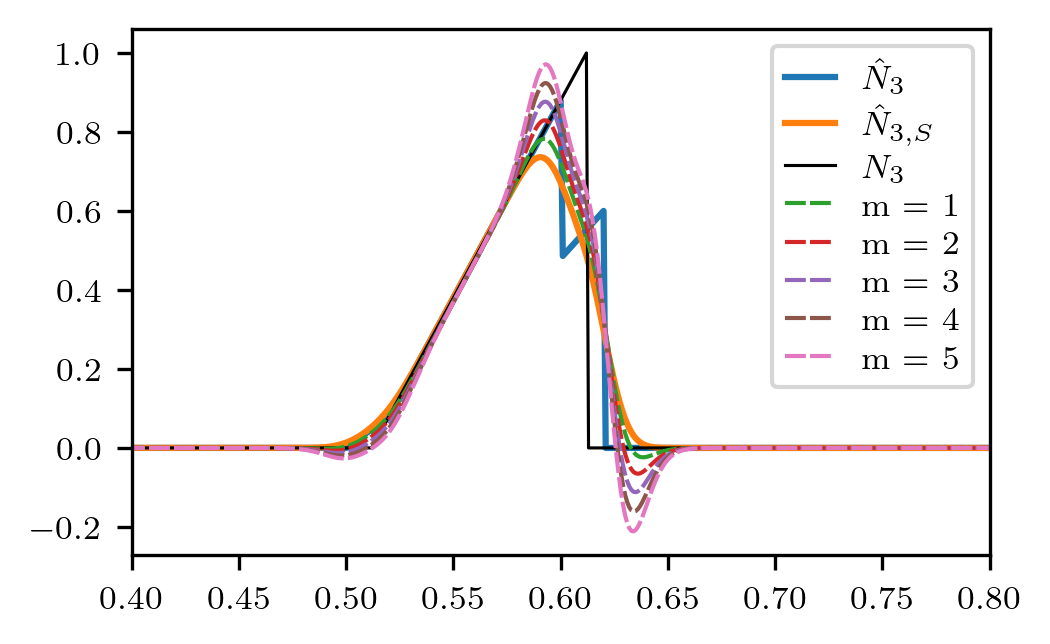

0.018176
get g
get g
get g
1.7343846058257917
1.9914496302700748
2.5328124779535433
3.218057211525076
3.9734281337929036
riemann 0.05049999999999983
riemann 0.05049999999999983
riemann 0.05049999999999983
riemann 0.05049999999999983
riemann 0.05049999999999983


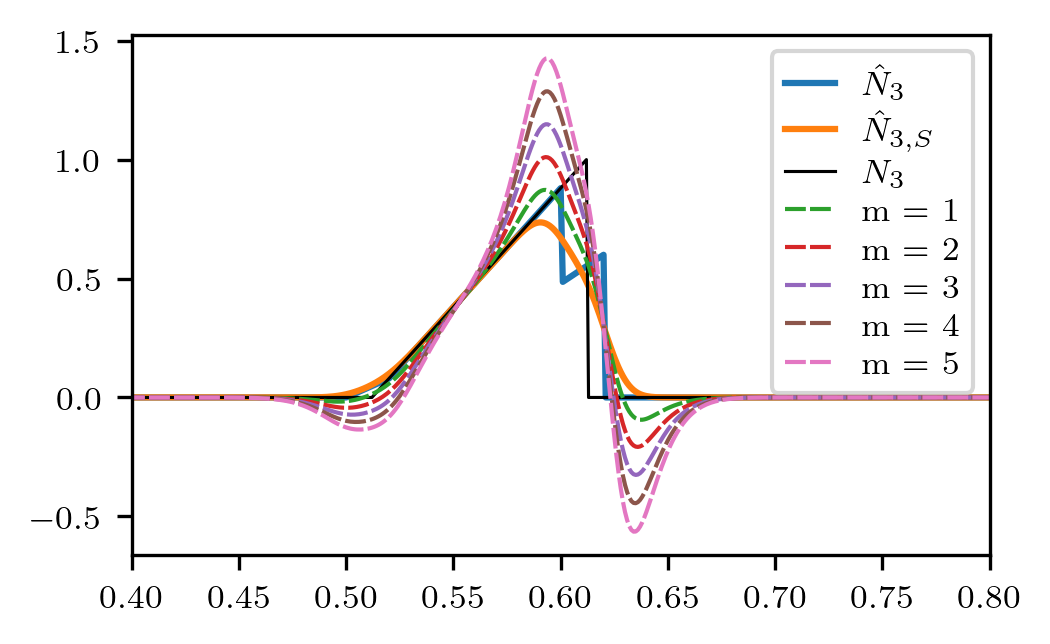

0.014417382716049386
get g
get g
get g
1.7358493990281707
1.799005490039578
2.052202936554623
2.4369081958373195
2.901271228203179
riemann 0.050499999999999844
riemann 0.050499999999999844
riemann 0.050499999999999844
riemann 0.050499999999999844
riemann 0.050499999999999844


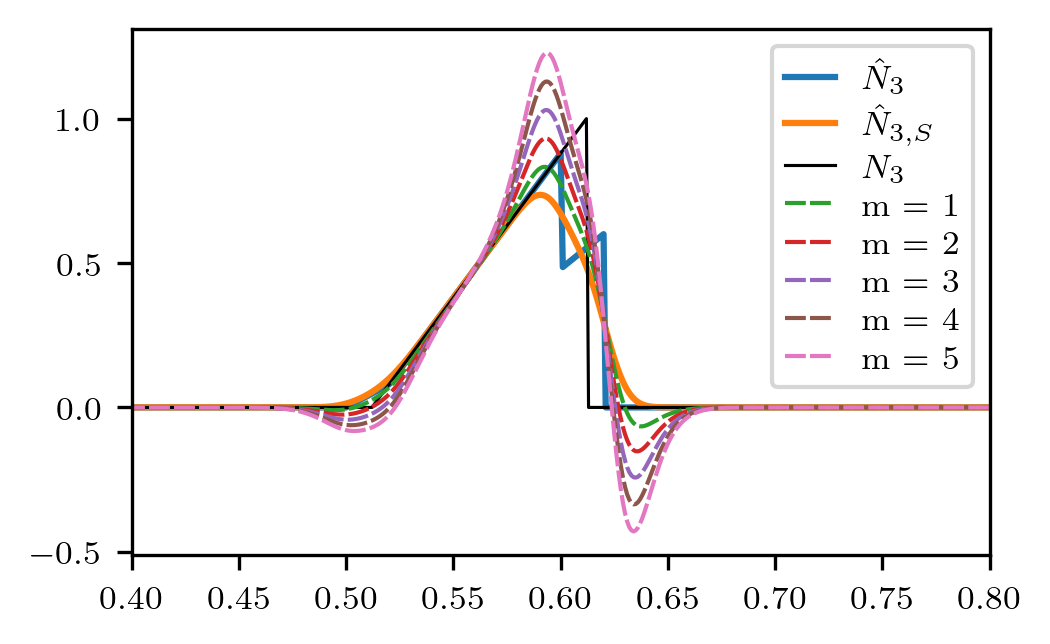

0.01291
get g
get g
get g
1.7488320854573618
1.7629123841604317
1.9209719609740261
2.192084228534954
2.5403070768424953
riemann 0.050499999999999844
riemann 0.050499999999999844
riemann 0.050499999999999844
riemann 0.050499999999999844
riemann 0.050499999999999844


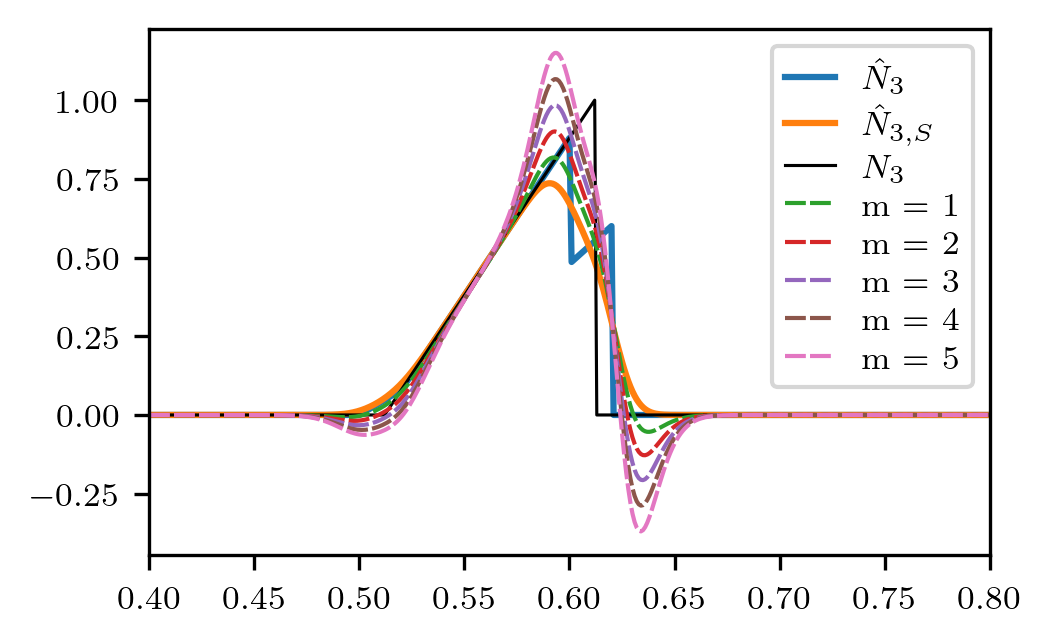

In [10]:

m = n_x

mp = 1
# sigs, c = 0.00776175, 1.31943973

I = np.zeros_like(x)
I[m//2] = 1

for sigma_D in [sigma_S, 2*sigma_S, sigma_S*(1+0.5*c), 0.01291]:
    print(sigma_D)
    gs = gaussian(x-0.5, sigma=sigma_D)+gaussian(x-1.5, sigma=sigma_D)+gaussian(x+.5, sigma=sigma_D)
    #kernel = I + (I - gs) * mp


    fig, ax = plt.subplots()
    plt.plot(x, N3_hat, label=r"$\hat{N}_{3}$")
    plt.plot(x, N3_s_hat, label=r"$\hat{N}_{3,S}$")
    plt.plot(x, N3, color="k", label="$N_3$", lw=.75)
    for mp_ in [1, 2, 3, 4, 5]:
        kernel = I + (I - gs) * mp_
        N3_k = np.convolve(N3_s_hat, kernel, mode="same")
        plt.plot(x, N3_k, label="m = "+str(mp_), ls=(0, (5, 1)), lw=1)
        print(np.sum((N3-N3_k)**2)**.5)
    for mp_ in [1, 2, 3, 4, 5]:
        print("riemann", riemann_sum_equispaced(x,  N3_k))
    plt.legend()
    plt.xlim([0.4, 0.8])
    plt.tight_layout()
    plt.savefig(pth+"sharpening_multiplier_s{:.4f}.pdf".format(sigma_D))
    plt.show()

# edge detection using a discrete laplace operator np.array([-1, 2, -1])

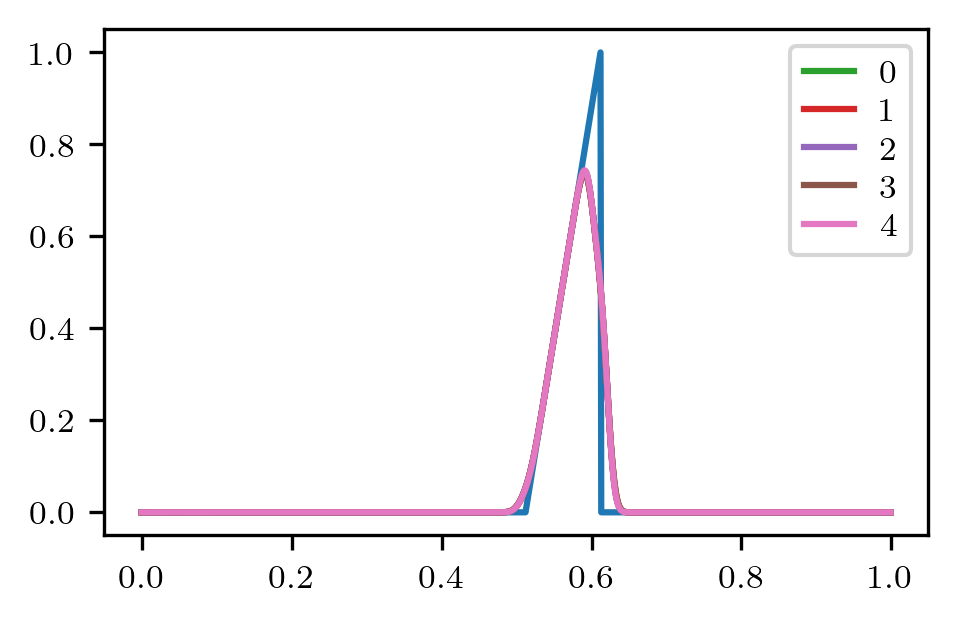

In [11]:
plt.plot(x, N3)
plt.plot(x, N3_s_hat)
N3_k = N3_s_hat
for k in range(5):
    kernel = np.array([-1, 3, -1])
    N3_k = np.convolve(N3_k, kernel, mode="same")
    plt.plot(x, N3_k, label=str(k))
plt.legend()
plt.show()

# Richardson Lucy


In [12]:
sS_all = np.linspace(0, 2*case["sigma"], 25)
sD_all = np.linspace(0, 2*case["sigma"], 27)
print(sS_all, case["sigma"])
num_iter = 1234
res = np.empty((len(sS_all), len(sD_all), case["n_test"], case["n_x"], num_iter))
internal_error = np.empty((len(sS_all), len(sD_all), case["n_test"], num_iter))
vmax = np.mean((X_test-X_test_ROM) ** 2, axis=-1) ** 0.5
for i, sS in enumerate(sS_all):
    case["sigma"] = sS
    mu_train, X_train, X_train_s = make_data_rw([0], [1], n_samples=case["n_train"], **case)
    mu_test, X_test, X_test_s = make_data_rw(mu_train[n_train//2], mu_train[n_train//2+1], n_samples=case["n_test"], **case)
    my_ROM = train_ROM_rw(mu_train, X_train)
    my_sROM = train_ROM_rw(mu_train, X_train_s)
    
    X_test_ROM = my_ROM.predict(mu_test).snapshots_matrix
    X_test_sROM, X_test_sROMs = get_predictions(my_sROM, mu_test, **case)

    for j, sD in enumerate(sD_all):
        print(i, j, sS, sD)
        for k, mu in enumerate(mu_test):
            res[i, j, k], internal_error[i, j, k] = richardson_lucy(x, X_test_sROM[k], sD, num_iter, monitor_convergence=True)
            #error = np.mean((X_test[k, :, None]-res[i, j, k]) ** 2, axis=-2) ** 0.5
pth = "../data/1_"
error = np.mean((X_test[None, None, :, :, None]-res) ** 2, axis=-2) ** 0.5
np.save(pth+"error.npy", error)
np.save(pth+"internal_error.npy", internal_error)

[0.         0.00069907 0.00139815 0.00209722 0.0027963  0.00349537
 0.00419444 0.00489352 0.00559259 0.00629167 0.00699074 0.00768981
 0.00838889 0.00908796 0.00978704 0.01048611 0.01118519 0.01188426
 0.01258333 0.01328241 0.01398148 0.01468056 0.01537963 0.0160787
 0.01677778] 0.008388888888888888
0 0 0.0 0.0
0 1 0.0 0.0006452991452991452
0 2 0.0 0.0012905982905982904
0 3 0.0 0.0019358974358974356
0 4 0.0 0.002581196581196581
0 5 0.0 0.0032264957264957262
0 6 0.0 0.003871794871794871
0 7 0.0 0.0045170940170940165
0 8 0.0 0.005162393162393162
0 9 0.0 0.005807692307692307
0 10 0.0 0.0064529914529914524
0 11 0.0 0.007098290598290598
0 12 0.0 0.007743589743589742
0 13 0.0 0.008388888888888888
0 14 0.0 0.009034188034188033
0 15 0.0 0.009679487179487179
0 16 0.0 0.010324786324786324
0 17 0.0 0.010970085470085468
0 18 0.0 0.011615384615384614
0 19 0.0 0.012260683760683759
0 20 0.0 0.012905982905982905
0 21 0.0 0.01355128205128205
0 22 0.0 0.014196581196581196
0 23 0.0 0.01484188034188034
0 

In [13]:
error = np.load(pth+"error.npy")
internal_error = np.load(pth+"internal_error.npy")

#error = np.mean((X_test[None, None, :, :, None]-res) ** 2, axis=-2) ** 0.5
X_test.shape, res.shape, error.shape  # n_sS, n_sD, n_mu, n_iter
# error: n_sS, n_sD, n_mu, n_iter
n_sS, n_sD, n_mu, n_iter = error.shape

19 25
error 0.04649714838405113
error 0.03373157794856607
error 0.029404787881879724


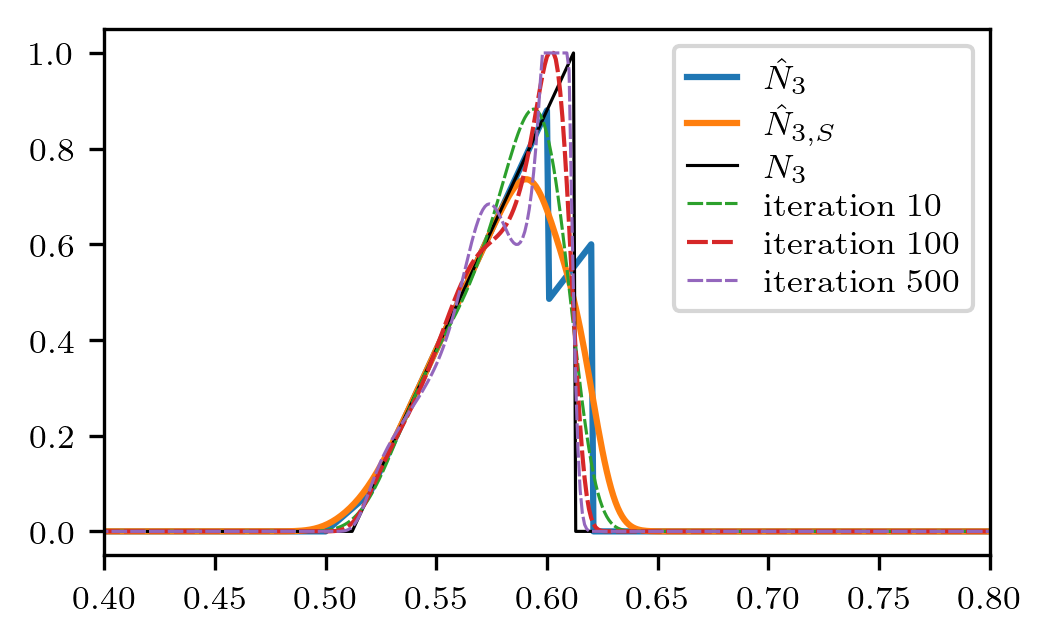

13 20
error 0.0408914799887319
error 0.027108216087520027
error 0.033311509330593736


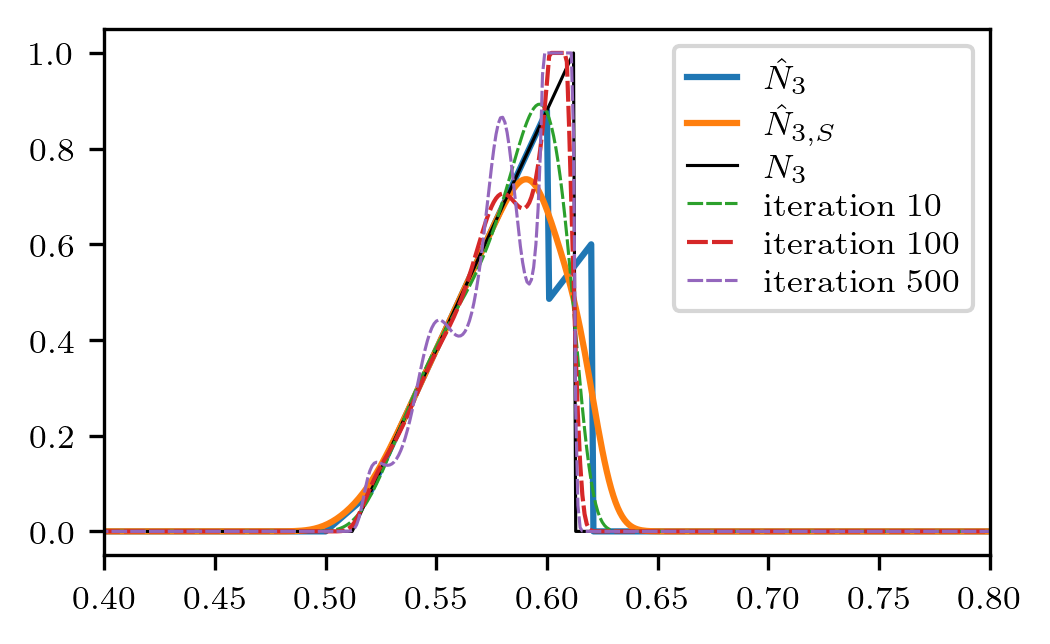

7 17
error 0.0371736283411828
error 0.024826289080100324
error 0.039465316852540275


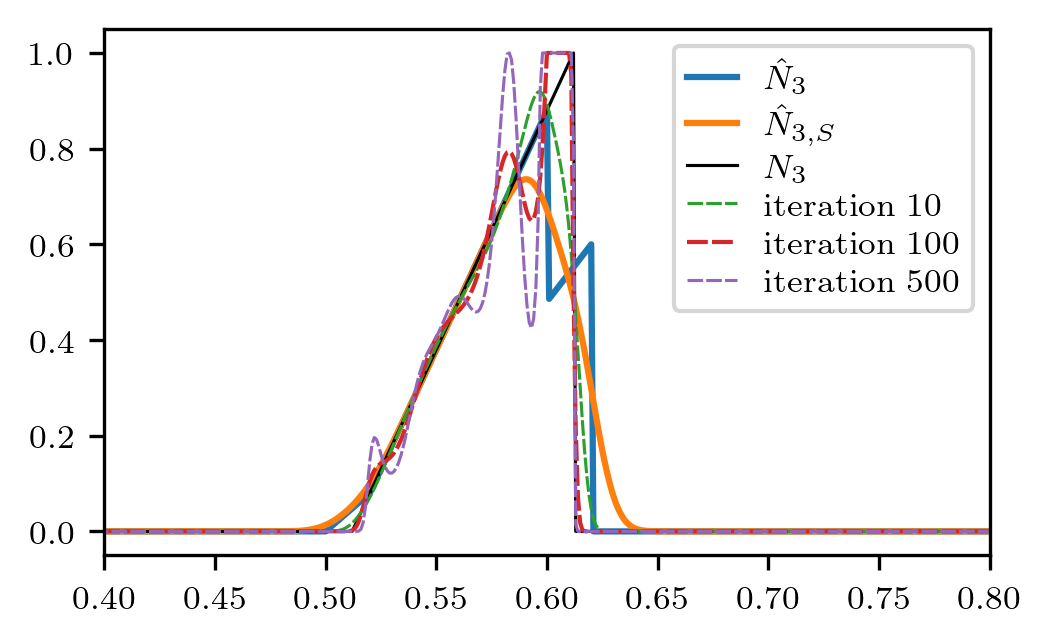

In [14]:
i_mu = 3
for ni in [999, 199, 99]:
    i_min = np.argmin(error[:, :, i_mu, ni])
    i, j = np.unravel_index(i_min, (n_sS, n_sD))
    print(i, j)
    
    fig, ax = plt.subplots()
    
    plt.plot(x, N3_hat, label=r"$\hat{N}_{3}$")
    plt.plot(x, N3_s_hat, label=r"$\hat{N}_{3,S}$")
    plt.plot(x, N3, color="k", label="$N_3$", lw=.75)
    
    for k in [9, 99, 499]:
        lw  = .75
        if k == 99:
            lw=1
        plt.plot(x, res[i, j, i_mu, :, k], label="iteration "+str(k+1), ls=(0, (5, 1)), lw=lw)
        print("error", error[i, j, i_mu, k])
        
    plt.legend()
    plt.xlim([0.4, 0.8])
    plt.tight_layout()
    plt.savefig(pth+"RL_decon"+str(ni)+".pdf")
    plt.show()


21 25


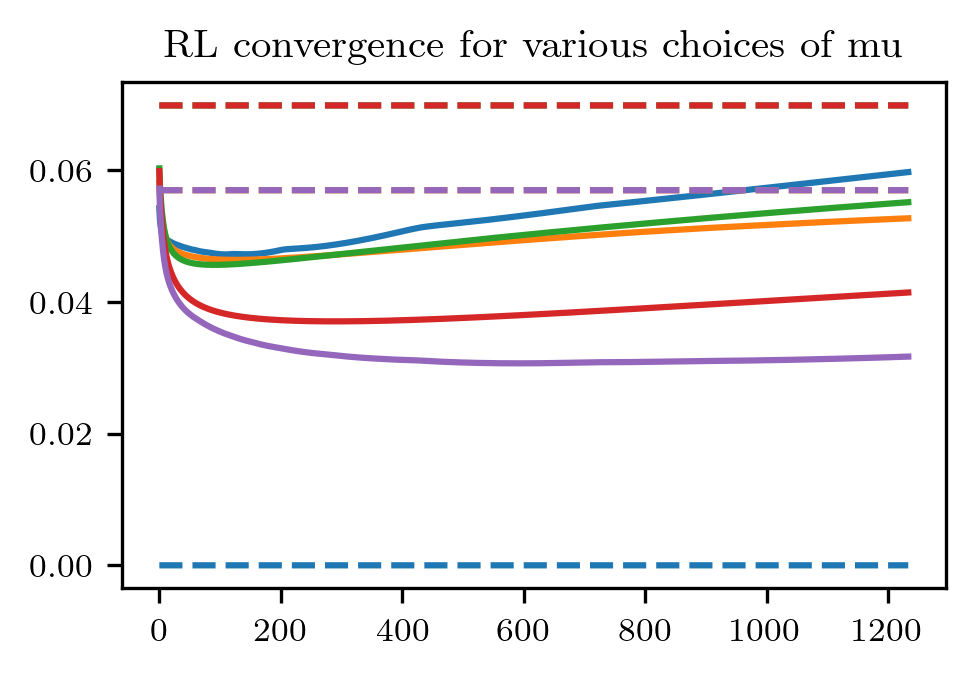

In [15]:

iters = np.arange(n_iter)
# best sS, sD for all mu, fixed sD, 100 iter:
i_min = np.argmin(np.mean(error[:, :, :, 199], axis=-1))
i, j = np.unravel_index(i_min, (n_sS, n_sD))
print(i, j)

e_ROM = np.mean((X_test-X_test_ROM) ** 2, axis=-1) ** 0.5

fig, ax = plt.subplots()
for k in range(n_mu):
    plt.plot(iters, error[i, j, k, :], "C"+str(k)+"-")
    plt.plot(iters, iters*0+e_ROM[k], "C"+str(k)+"--")
plt.title("RL convergence for various choices of mu")
plt.show()

# # best sS, sD for snapshot 3, fixed sD, 100 iter:
# i_min = np.argmin(np.mean(error[:, :, 3, 100], axis=-1))
# i, j = np.unravel_index(i_min, (n_sS, n_sD))

2 15 43 0.02229325957537376 0.02229325957537376 lowest error possible for snapshot 3
7 17 43 0.024826289080100324 0.024826289080100324 lowest error possible for snapshot 3, at n_iter = 100 iterations
13 20 43 0.027108216087520027 0.024826289080100324 lowest error possible for snapshot 3, at n_iter = 100 iterations
19 25 43 0.03004457988602607 0.03004457988602607 lowest error possible for snapshot 3, at n_iter = 1000 iterations


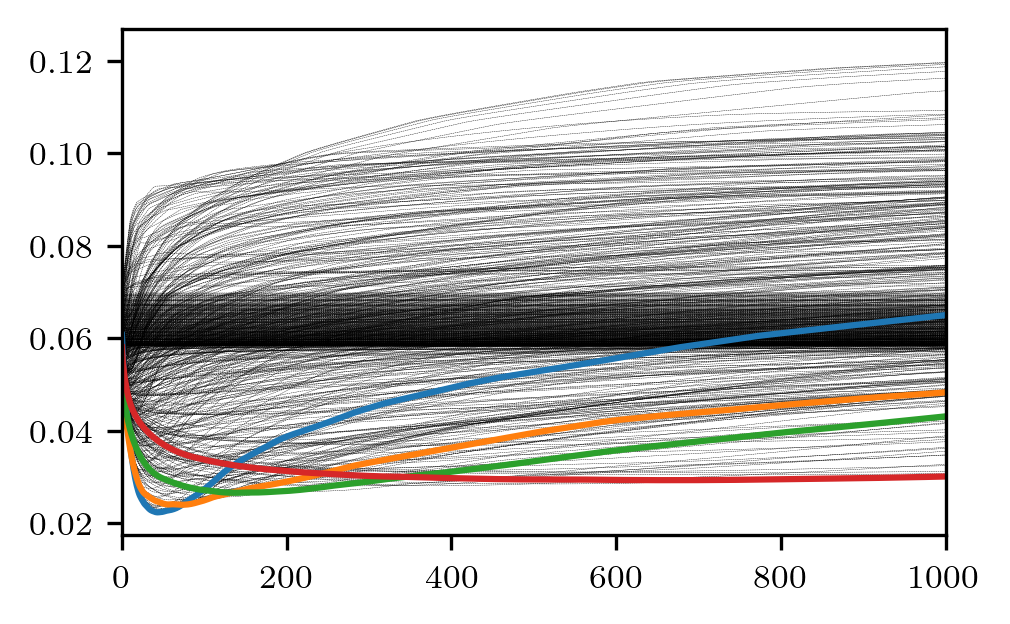

sS=0.009088; sD=0.01291


In [16]:
for i in range(n_sS):
    for j in range(n_sD):
        plt.plot(error[i, j, 3, :], "k--", lw=0.1)

i_min = np.argmin(error[:, :, 3, :])
i, j, n = np.unravel_index(i_min, (n_sS, n_sD, n_iter))
print(i, j, n, error[i, j, 3, n], np.min(error[:, :, 3, :]), "lowest error possible for snapshot 3")
plt.plot(error[i, j, 3, :])

i_min = np.argmin(error[:, :, 3, 99])
i, j = np.unravel_index(i_min, (n_sS, n_sD))
print(i, j, n, error[i, j, 3, 99], np.min(error[:, :, 3, 99]), "lowest error possible for snapshot 3, at n_iter = 100 iterations")
plt.plot(error[i, j, 3, :])

i_min = np.argmin(error[:, :, 3, 199])
i, j = np.unravel_index(i_min, (n_sS, n_sD))
print(i, j, n, error[i, j, 3, 99], np.min(error[:, :, 3, 99]), "lowest error possible for snapshot 3, at n_iter = 100 iterations")
plt.plot(error[i, j, 3, :])
i_sSopt = i
i_sDopt = j

i_min = np.argmin(error[:, :, 3, 999])
i, j = np.unravel_index(i_min, (n_sS, n_sD))
print(i, j, n, error[i, j, 3, 999], np.min(error[:, :, 3, 999]), "lowest error possible for snapshot 3, at n_iter = 1000 iterations")
plt.plot(error[i, j, 3, :])

plt.xlim(0, 1000)
plt.show()

print("sS={:.6f}; sD={:.5f}".format(sS_all[i_sSopt], sD_all[i_sDopt] ))

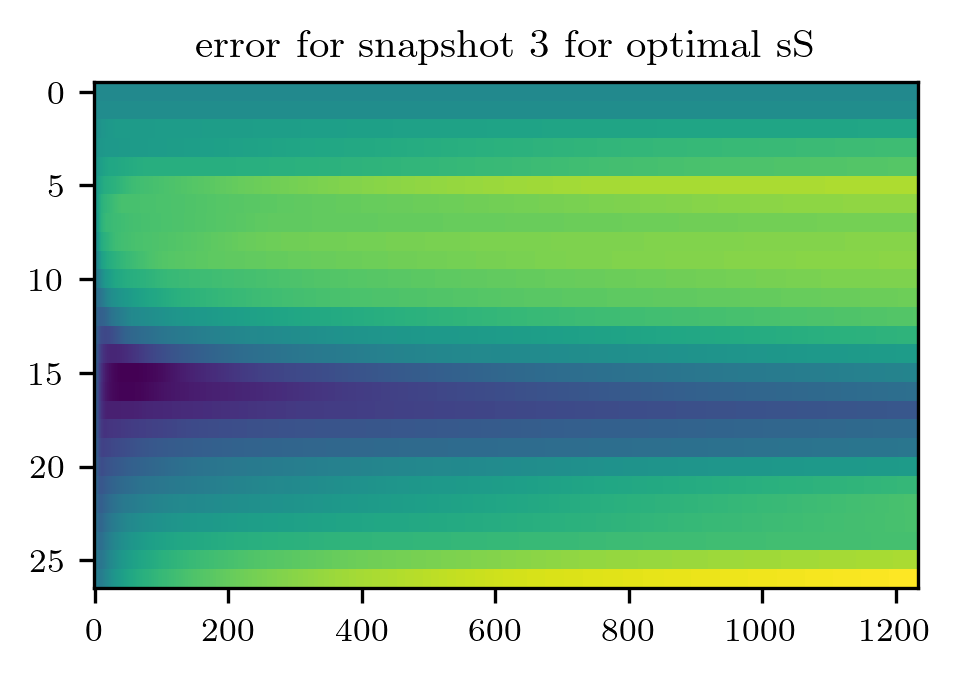

0 15 16 17 0.02288889829896784
0 0.0 11 0.05962644162694125
1 0.1 12 0.053325972539005485
2 0.2 13 0.044388186041967204
3 0.3 14 0.033460795193366095
4 0.4 15 0.02288889829896784
5 0.5 16 0.023790432377516567
6 0.6 17 0.0314097601218379
7 0.7 18 0.03737609367212591
8 0.8 19 0.04214409863207839
9 0.9 20 0.04608297272265266
10 1.0 21 0.049584524240385695


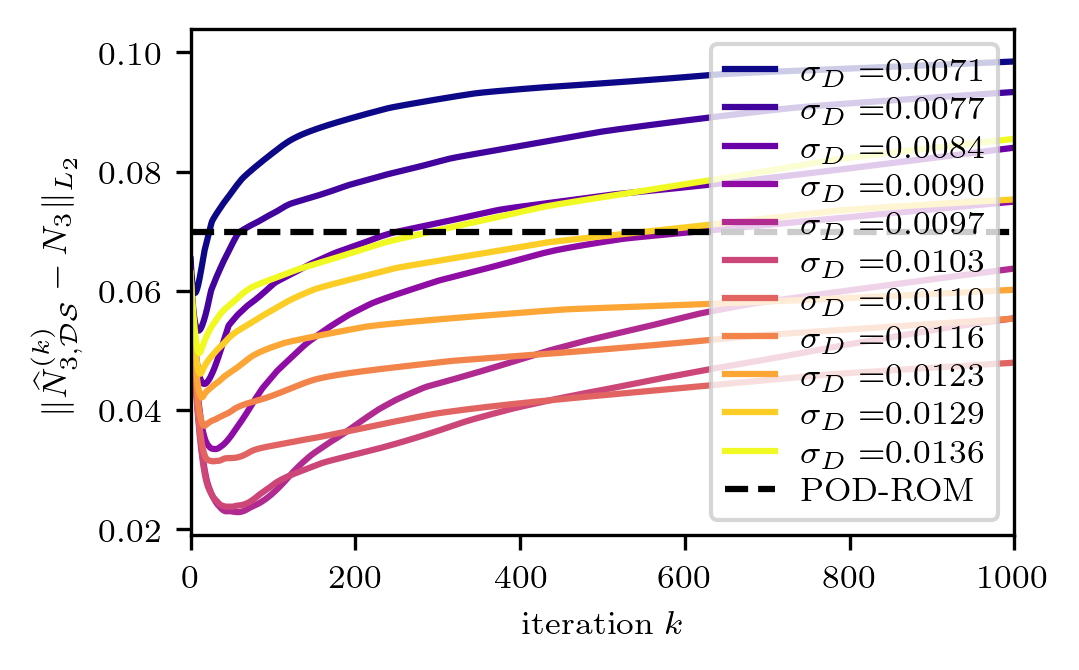

0 0.0 11 0.05962644162694125
1 0.1 12 0.053325972539005485
2 0.2 13 0.044388186041967204
3 0.3 14 0.033460795193366095
4 0.4 15 0.02288889829896784
5 0.5 16 0.023790432377516567
6 0.6 17 0.0314097601218379
7 0.7 18 0.03737609367212591
8 0.8 19 0.04214409863207839
9 0.9 20 0.04608297272265266
10 1.0 21 0.049584524240385695


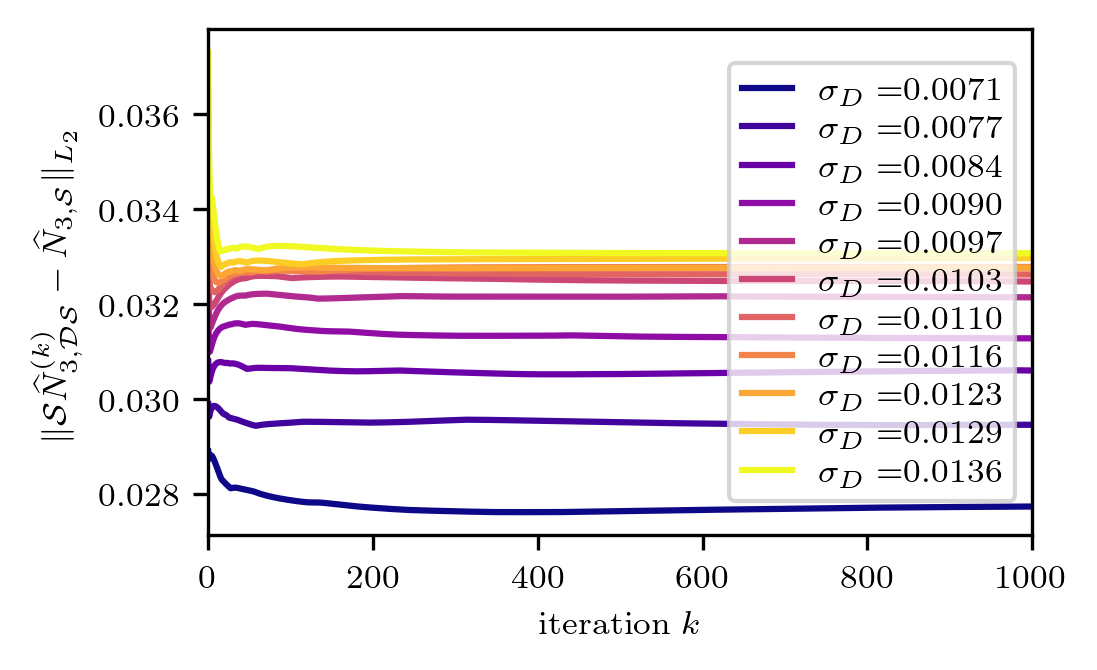

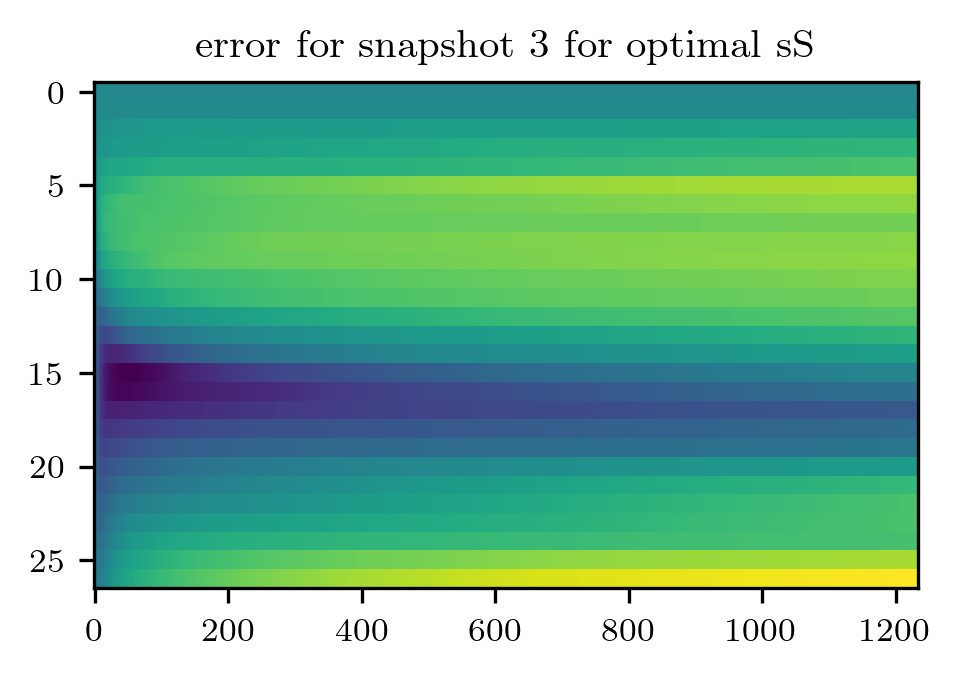

1 15 16 17 0.022344533977455516
0 0.0 11 0.059224845087137025
1 0.1 12 0.05299888059687309
2 0.2 13 0.04405281684002064
3 0.3 14 0.033026822638113074
4 0.4 15 0.022344533977455516
5 0.5 16 0.0235976431555891
6 0.6 17 0.0314677794276395
7 0.7 18 0.03747982682436979
8 0.8 19 0.04230095514418406
9 0.9 20 0.04633513927158586
10 1.0 21 0.049901558604976415


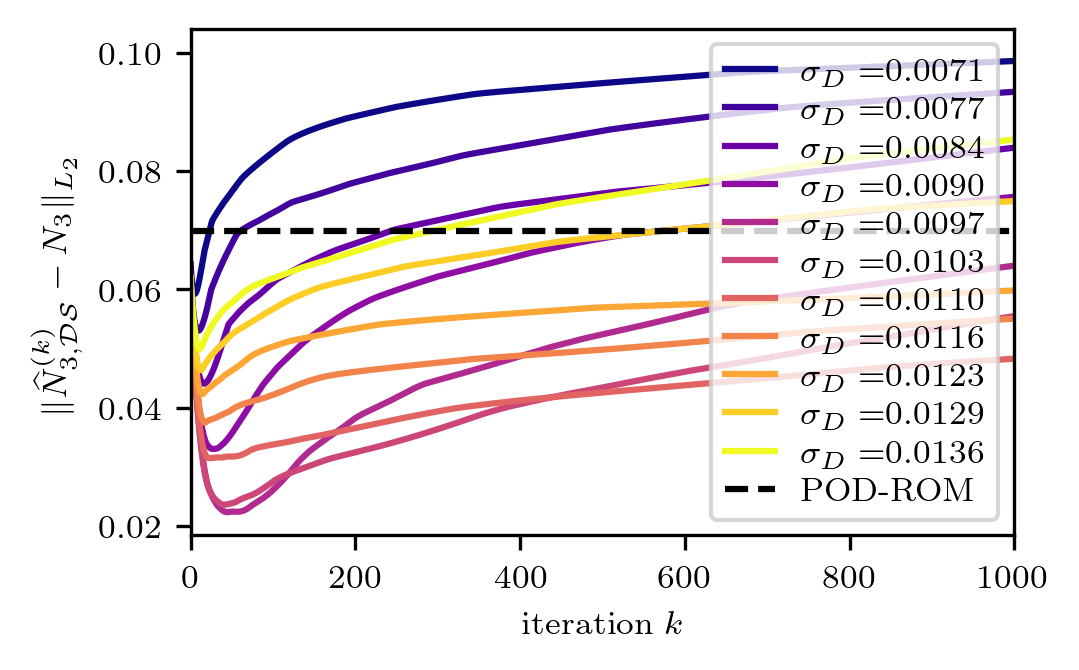

0 0.0 11 0.059224845087137025
1 0.1 12 0.05299888059687309
2 0.2 13 0.04405281684002064
3 0.3 14 0.033026822638113074
4 0.4 15 0.022344533977455516
5 0.5 16 0.0235976431555891
6 0.6 17 0.0314677794276395
7 0.7 18 0.03747982682436979
8 0.8 19 0.04230095514418406
9 0.9 20 0.04633513927158586
10 1.0 21 0.049901558604976415


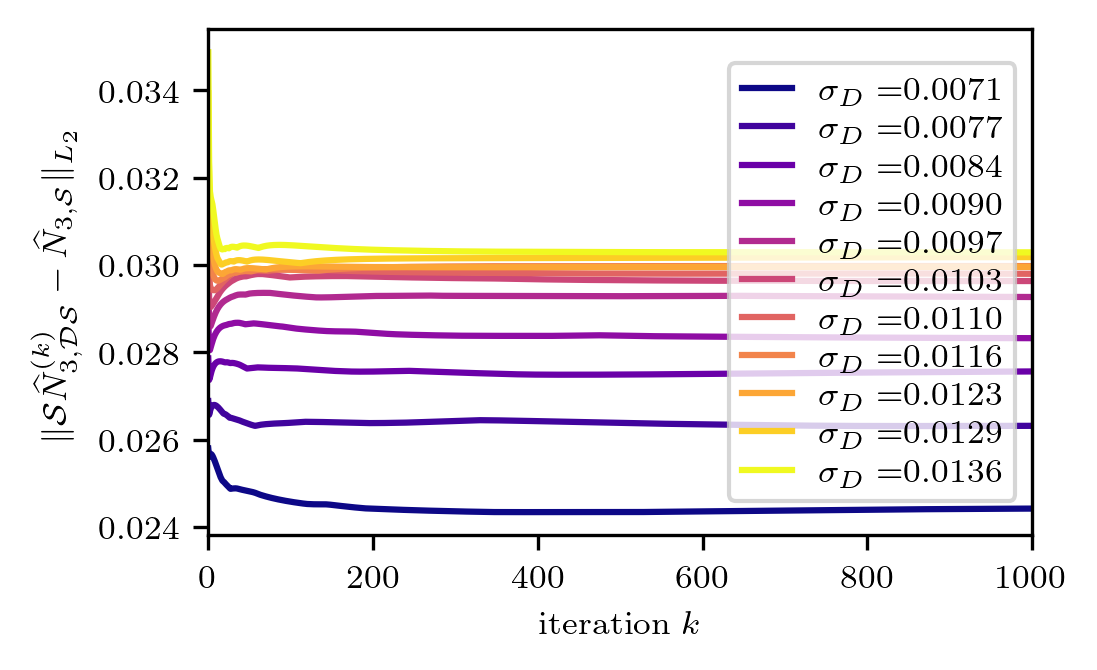

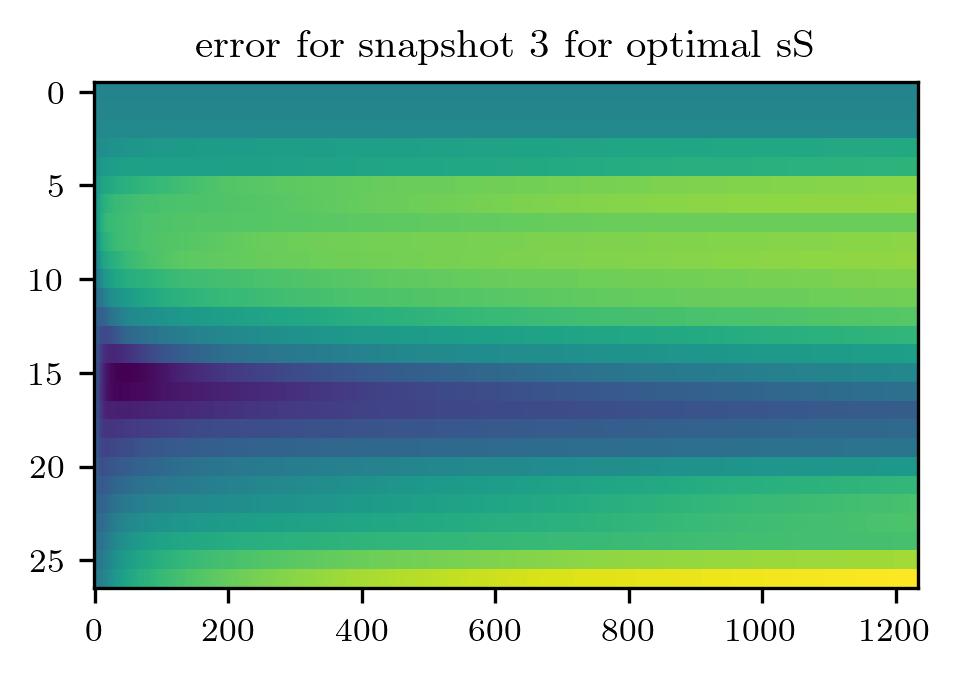

2 15 16 17 0.02229325957537376
0 0.0 11 0.05883007228015318
1 0.1 12 0.052865936143310116
2 0.2 13 0.0441071132140507
3 0.3 14 0.033105692597482125
4 0.4 15 0.02229325957537376
5 0.5 16 0.02332587439342127
6 0.6 17 0.030997081056660405
7 0.7 18 0.037319169877934
8 0.8 19 0.04223202800313439
9 0.9 20 0.04641055597265217
10 1.0 21 0.05002878716780422


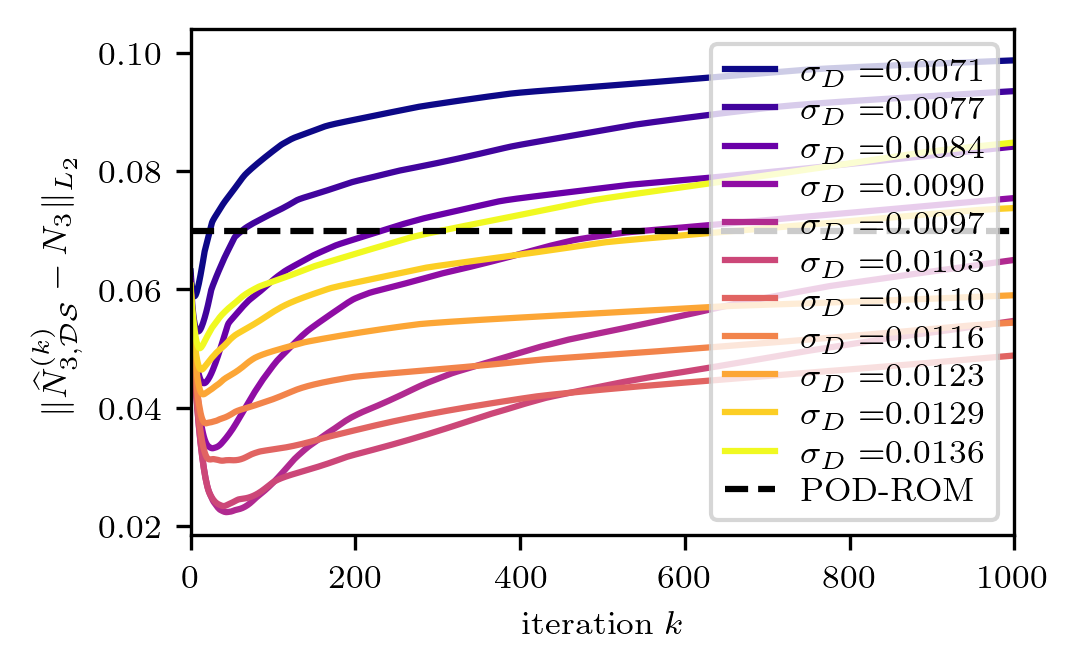

0 0.0 11 0.05883007228015318
1 0.1 12 0.052865936143310116
2 0.2 13 0.0441071132140507
3 0.3 14 0.033105692597482125
4 0.4 15 0.02229325957537376
5 0.5 16 0.02332587439342127
6 0.6 17 0.030997081056660405
7 0.7 18 0.037319169877934
8 0.8 19 0.04223202800313439
9 0.9 20 0.04641055597265217
10 1.0 21 0.05002878716780422


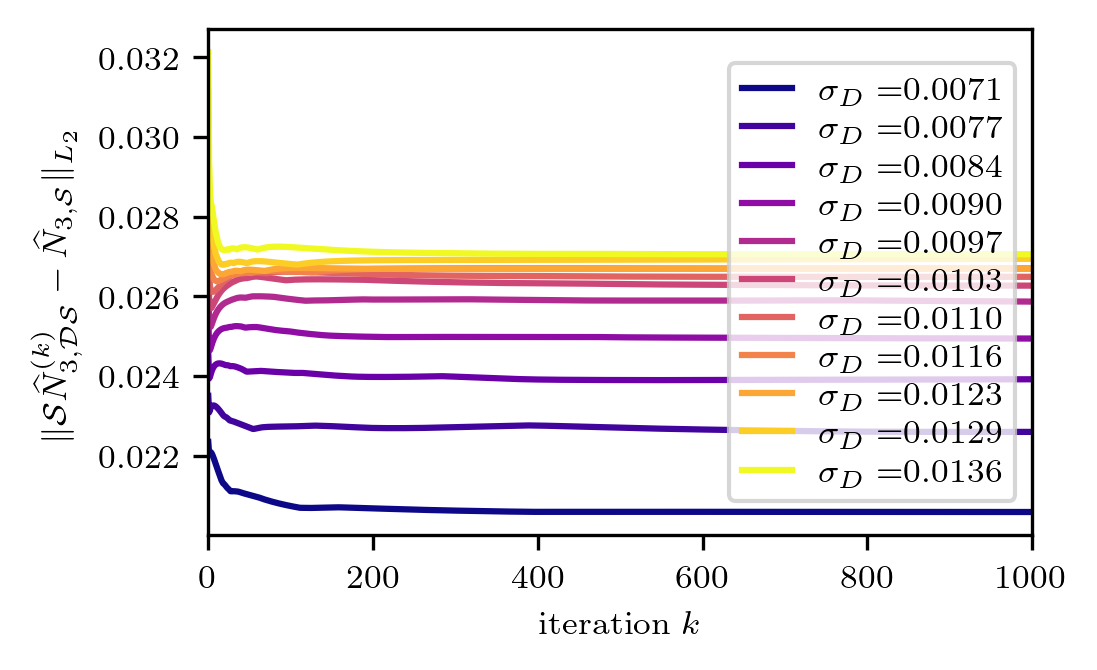

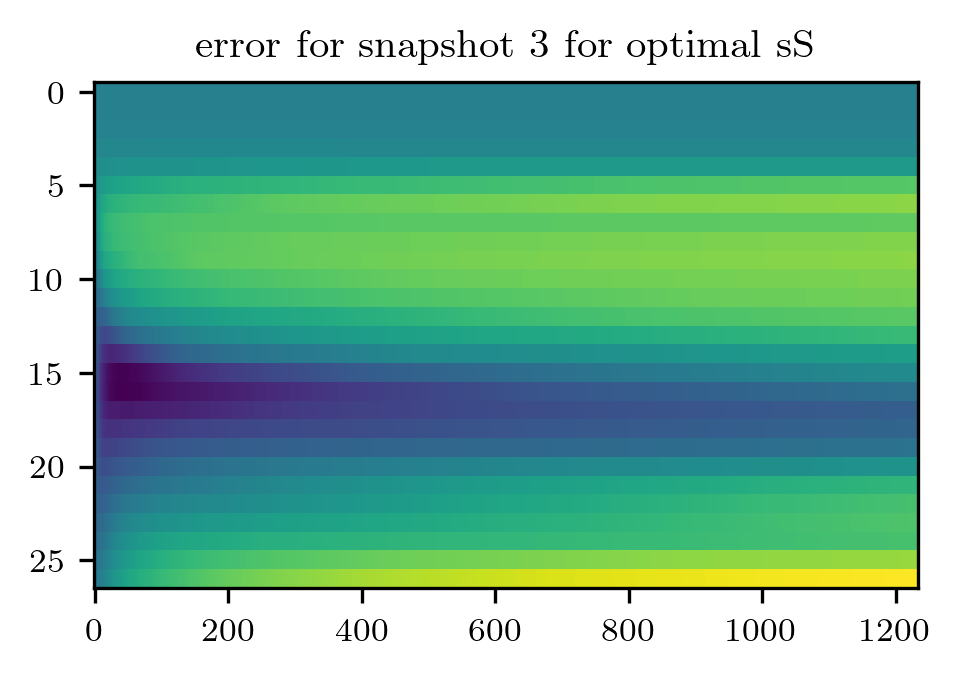

3 16 16 17 0.022826076364610925
0 0.0 11 0.05830040561706765
1 0.1 12 0.052927854801543335
2 0.2 13 0.04466726231213116
3 0.3 14 0.03396400930788808
4 0.4 15 0.023351541760196538
5 0.5 16 0.022826076364610925
6 0.6 17 0.02996568628302872
7 0.7 18 0.036744788913732195
8 0.8 19 0.04189727662411278
9 0.9 20 0.0462614490855658
10 1.0 21 0.04995135786452893


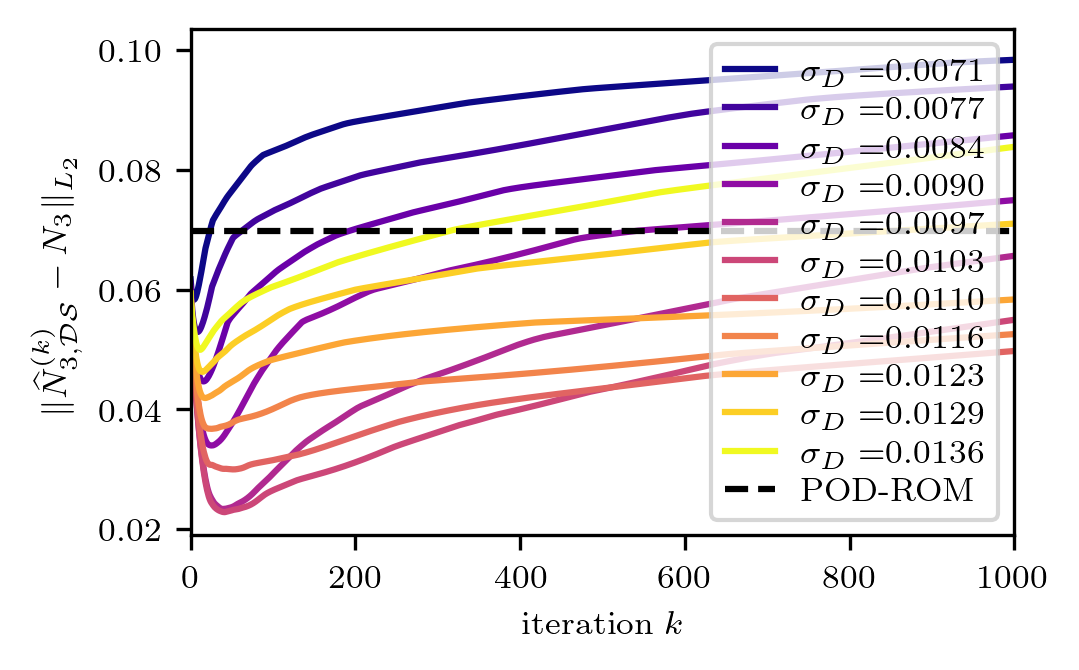

0 0.0 11 0.05830040561706765
1 0.1 12 0.052927854801543335
2 0.2 13 0.04466726231213116
3 0.3 14 0.03396400930788808
4 0.4 15 0.023351541760196538
5 0.5 16 0.022826076364610925
6 0.6 17 0.02996568628302872
7 0.7 18 0.036744788913732195
8 0.8 19 0.04189727662411278
9 0.9 20 0.0462614490855658
10 1.0 21 0.04995135786452893


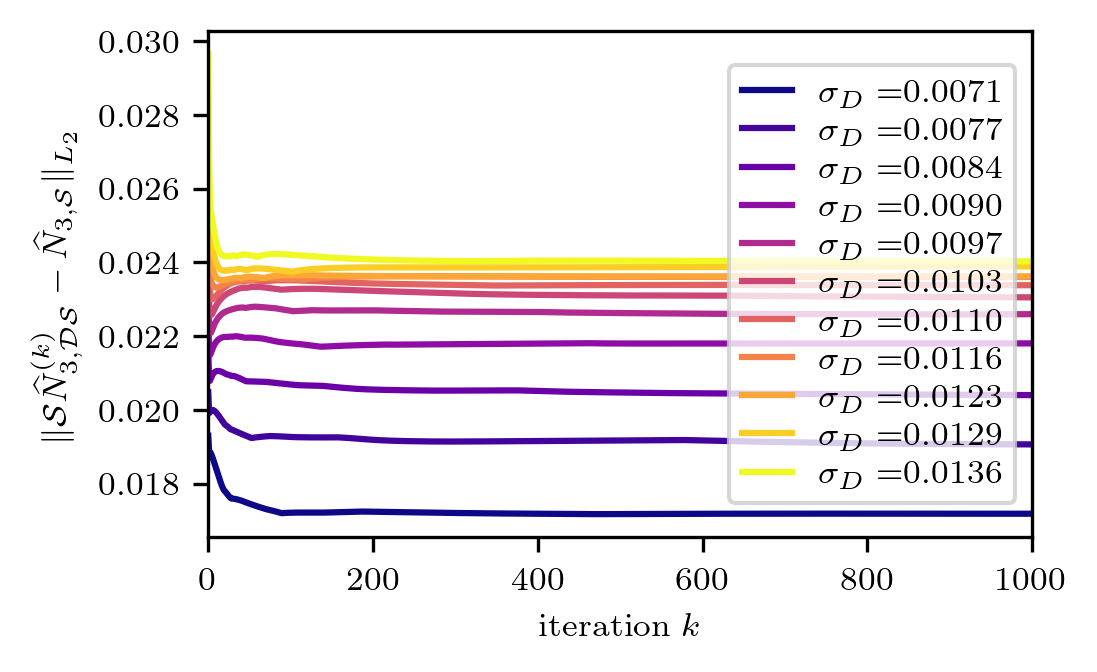

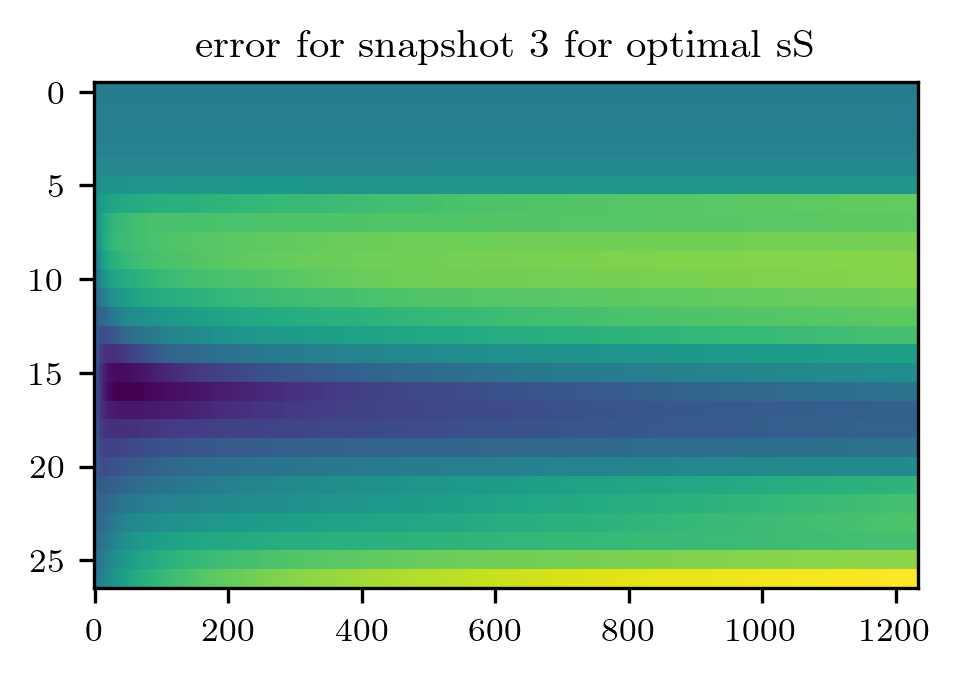

4 16 16 17 0.022419939870207923
0 0.0 11 0.05756107229608924
1 0.1 12 0.052899906050172314
2 0.2 13 0.04552458044099406
3 0.3 14 0.03539874107642519
4 0.4 15 0.02512248902371516
5 0.5 16 0.022419939870207923
6 0.6 17 0.028503726654684362
7 0.7 18 0.03562354499146355
8 0.8 19 0.04116754379482325
9 0.9 20 0.045757618788018734
10 1.0 21 0.049581088061884826


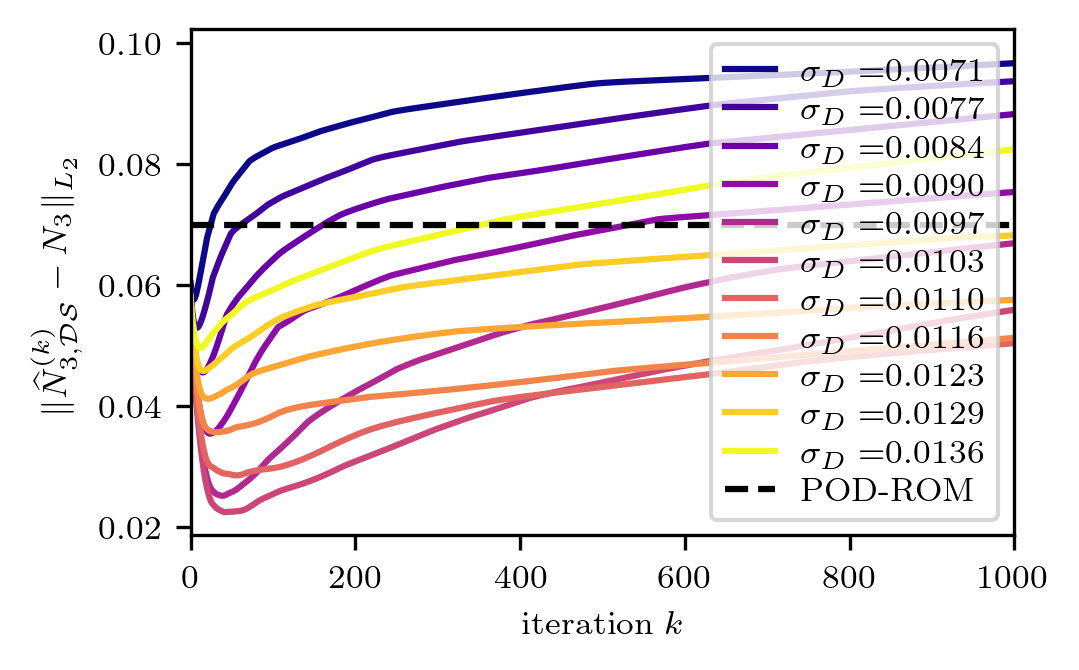

0 0.0 11 0.05756107229608924
1 0.1 12 0.052899906050172314
2 0.2 13 0.04552458044099406
3 0.3 14 0.03539874107642519
4 0.4 15 0.02512248902371516
5 0.5 16 0.022419939870207923
6 0.6 17 0.028503726654684362
7 0.7 18 0.03562354499146355
8 0.8 19 0.04116754379482325
9 0.9 20 0.045757618788018734
10 1.0 21 0.049581088061884826


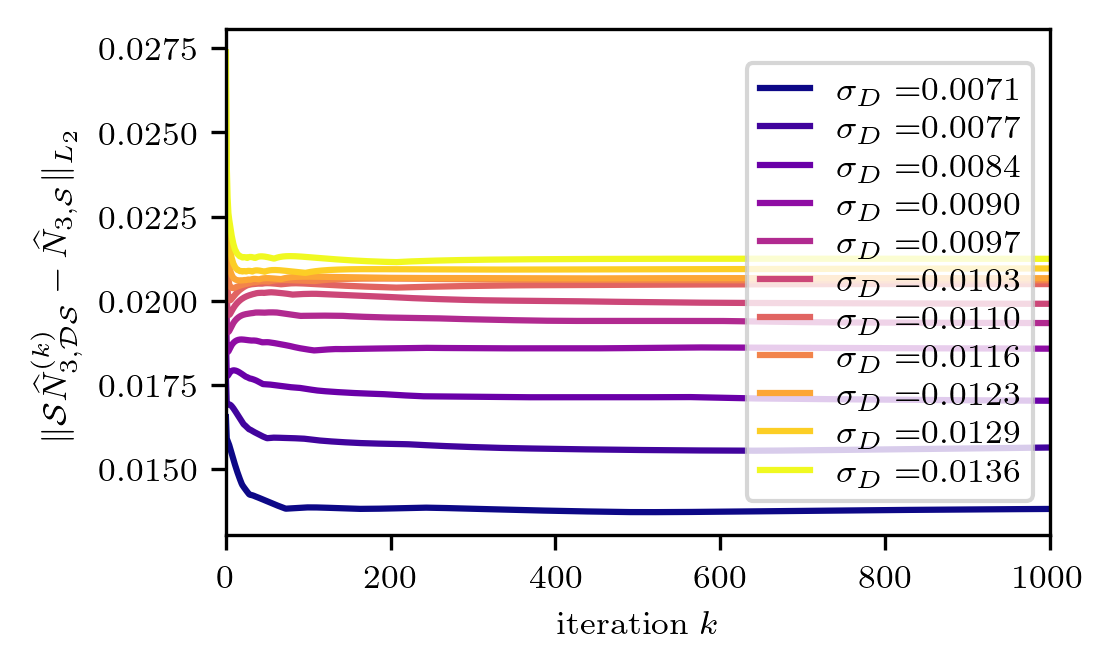

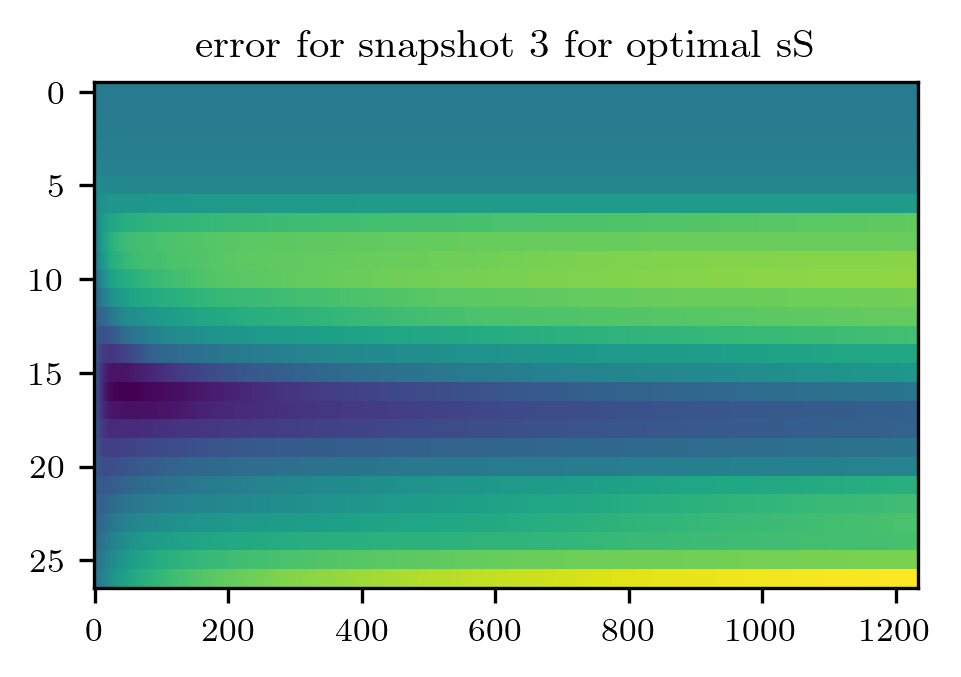

5 16 16 17 0.022554441447991007
0 0.0 11 0.05657111163427104
1 0.1 12 0.0526876629973649
2 0.2 13 0.046438632107972944
3 0.3 14 0.037289072070465036
4 0.4 15 0.027446244276700695
5 0.5 16 0.022554441447991007
6 0.6 17 0.026716634055386938
7 0.7 18 0.03401255619760594
8 0.8 19 0.040022941645810314
9 0.9 20 0.04491841586754934
10 1.0 21 0.04889194082937283


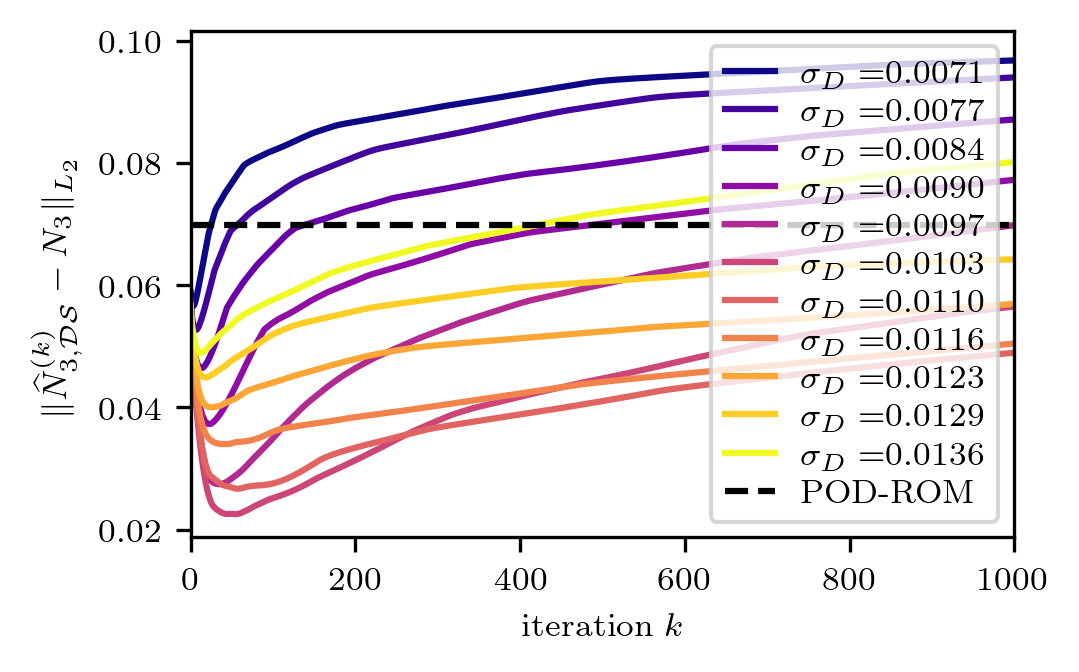

0 0.0 11 0.05657111163427104
1 0.1 12 0.0526876629973649
2 0.2 13 0.046438632107972944
3 0.3 14 0.037289072070465036
4 0.4 15 0.027446244276700695
5 0.5 16 0.022554441447991007
6 0.6 17 0.026716634055386938
7 0.7 18 0.03401255619760594
8 0.8 19 0.040022941645810314
9 0.9 20 0.04491841586754934
10 1.0 21 0.04889194082937283


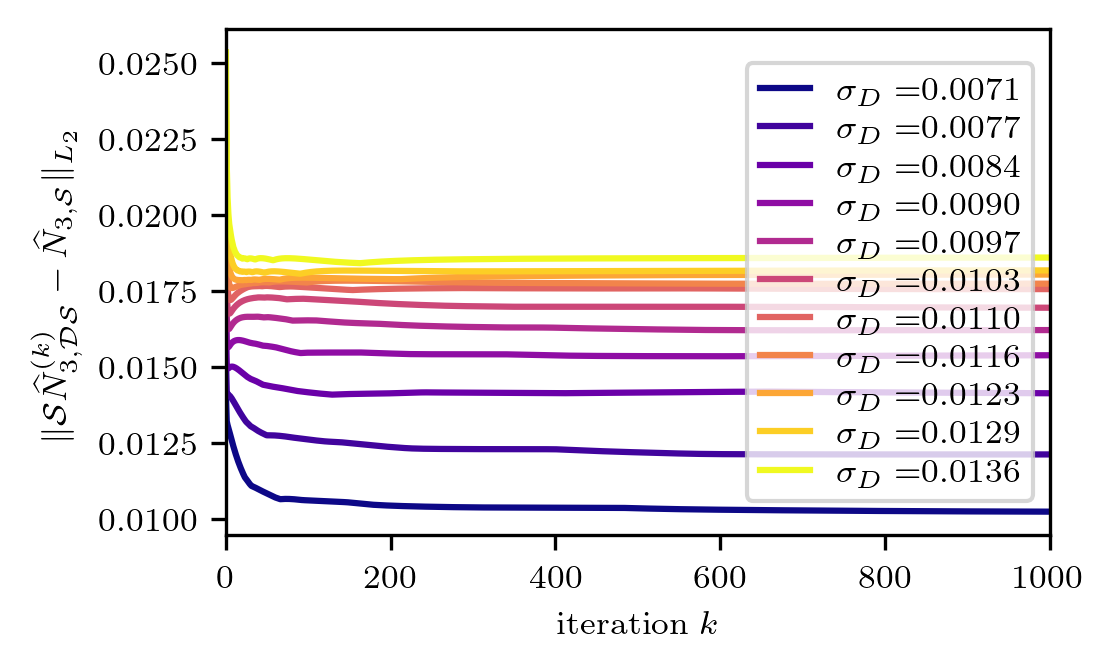

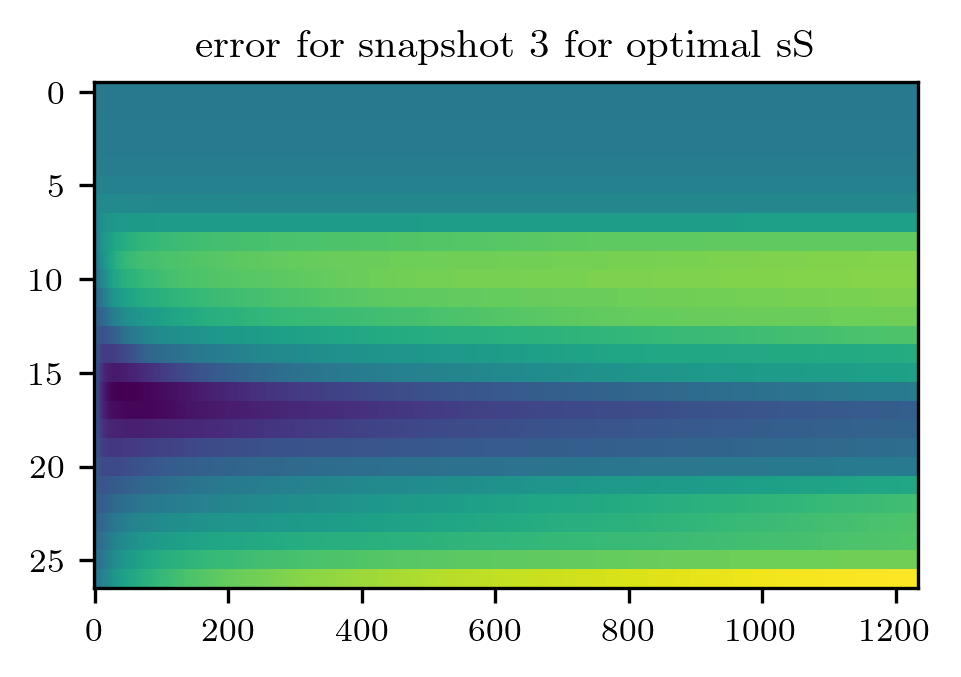

6 17 17 17 0.023651875493347116
0 0.0 12 0.052413315849094554
1 0.1 13 0.04731016928103738
2 0.2 14 0.03949924385499444
3 0.3 15 0.030088115574659156
4 0.4 16 0.023651875493347116
5 0.5 17 0.02497518112672888
6 0.6 18 0.03180222834521997
7 0.7 19 0.038423315647635896
8 0.8 20 0.043754183637547545
9 0.9 21 0.04797455255625561
10 1.0 22 0.051201845850354595


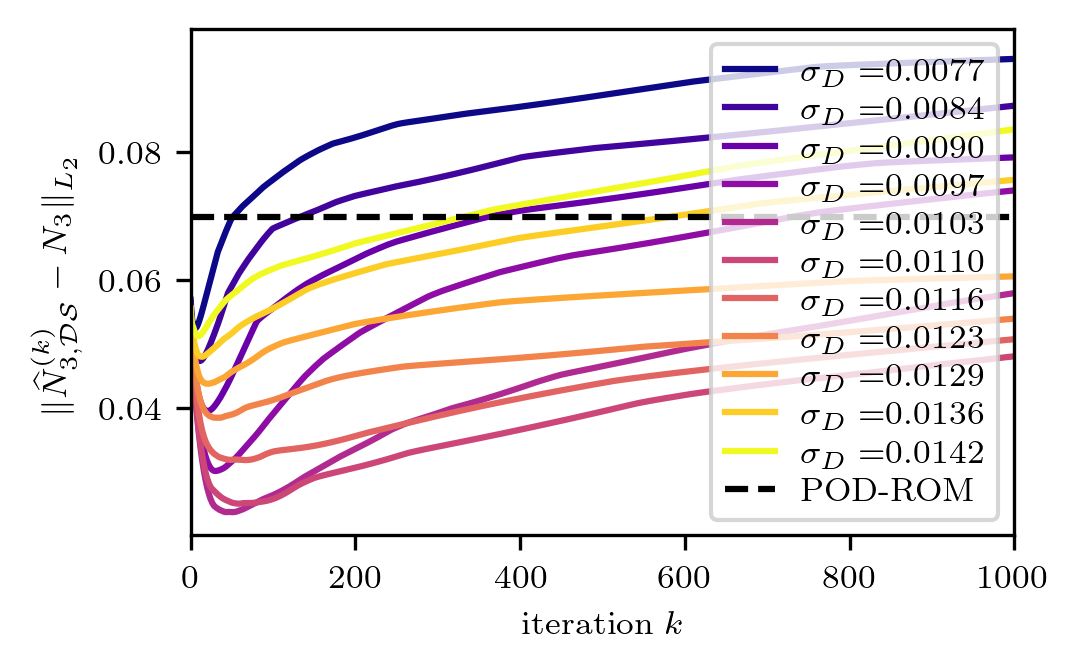

0 0.0 12 0.052413315849094554
1 0.1 13 0.04731016928103738
2 0.2 14 0.03949924385499444
3 0.3 15 0.030088115574659156
4 0.4 16 0.023651875493347116
5 0.5 17 0.02497518112672888
6 0.6 18 0.03180222834521997
7 0.7 19 0.038423315647635896
8 0.8 20 0.043754183637547545
9 0.9 21 0.04797455255625561
10 1.0 22 0.051201845850354595


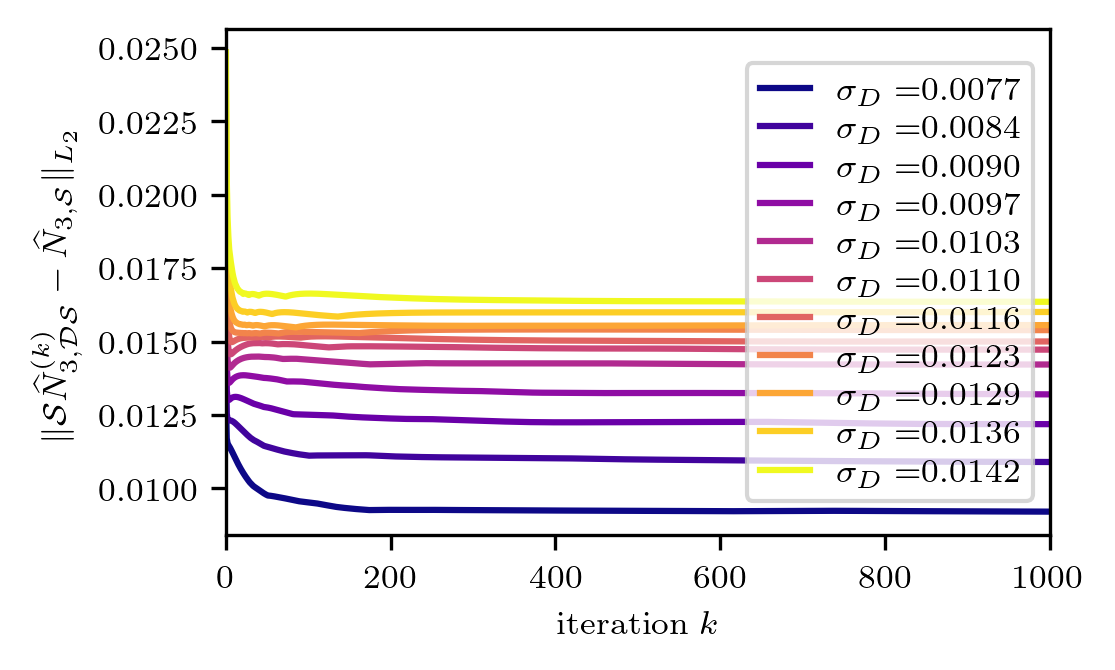

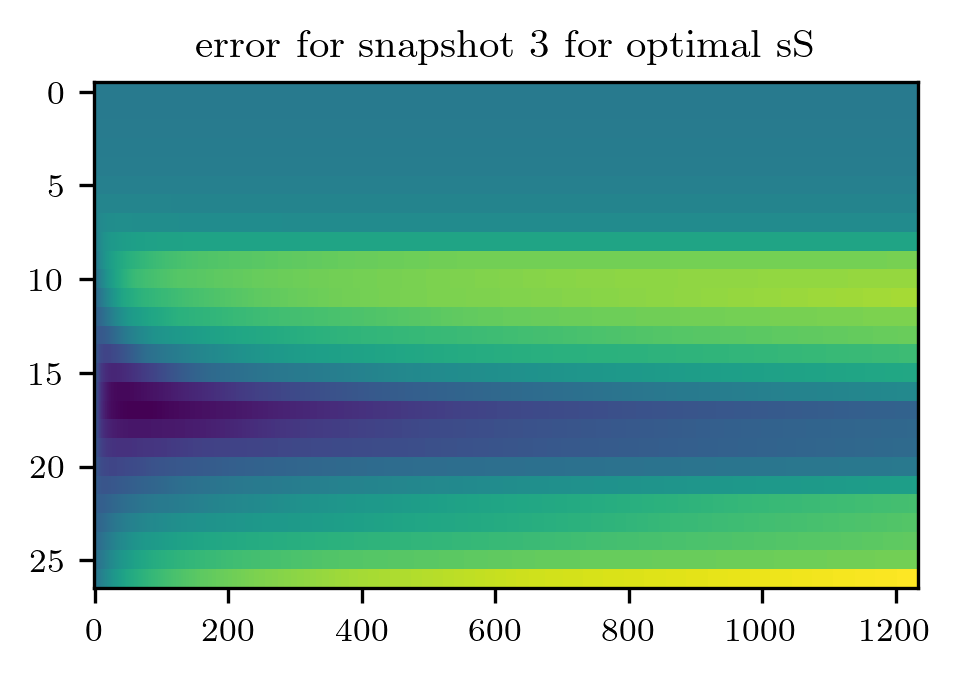

7 17 17 17 0.02393811567137476
0 0.0 12 0.05221886228531788
1 0.1 13 0.048127827524922555
2 0.2 14 0.041805285059334174
3 0.3 15 0.03316680782869664
4 0.4 16 0.025757074280423738
5 0.5 17 0.02393811567137476
6 0.6 18 0.02903180912853668
7 0.7 19 0.03628345198687133
8 0.8 20 0.0421514628723873
9 0.9 21 0.04683586444848245
10 1.0 22 0.05019941844453194


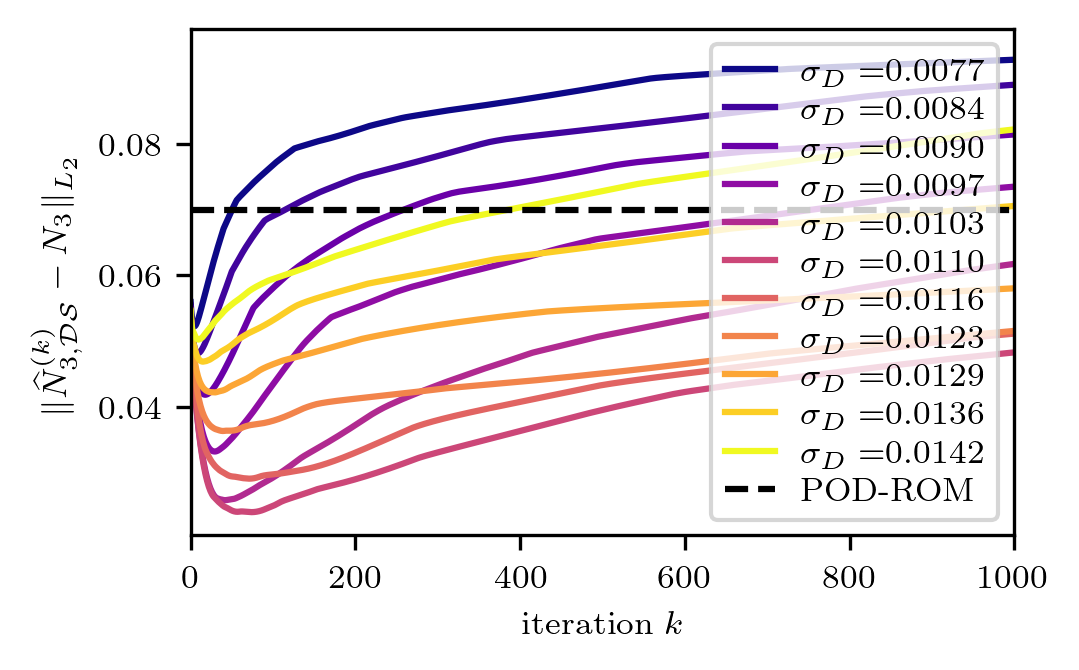

0 0.0 12 0.05221886228531788
1 0.1 13 0.048127827524922555
2 0.2 14 0.041805285059334174
3 0.3 15 0.03316680782869664
4 0.4 16 0.025757074280423738
5 0.5 17 0.02393811567137476
6 0.6 18 0.02903180912853668
7 0.7 19 0.03628345198687133
8 0.8 20 0.0421514628723873
9 0.9 21 0.04683586444848245
10 1.0 22 0.05019941844453194


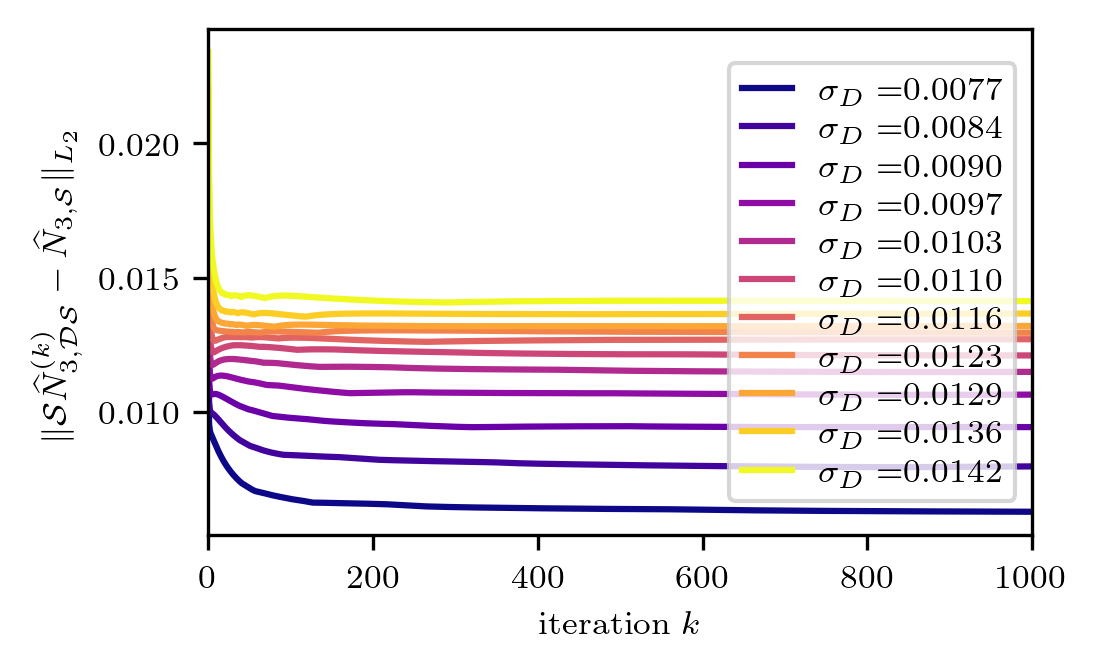

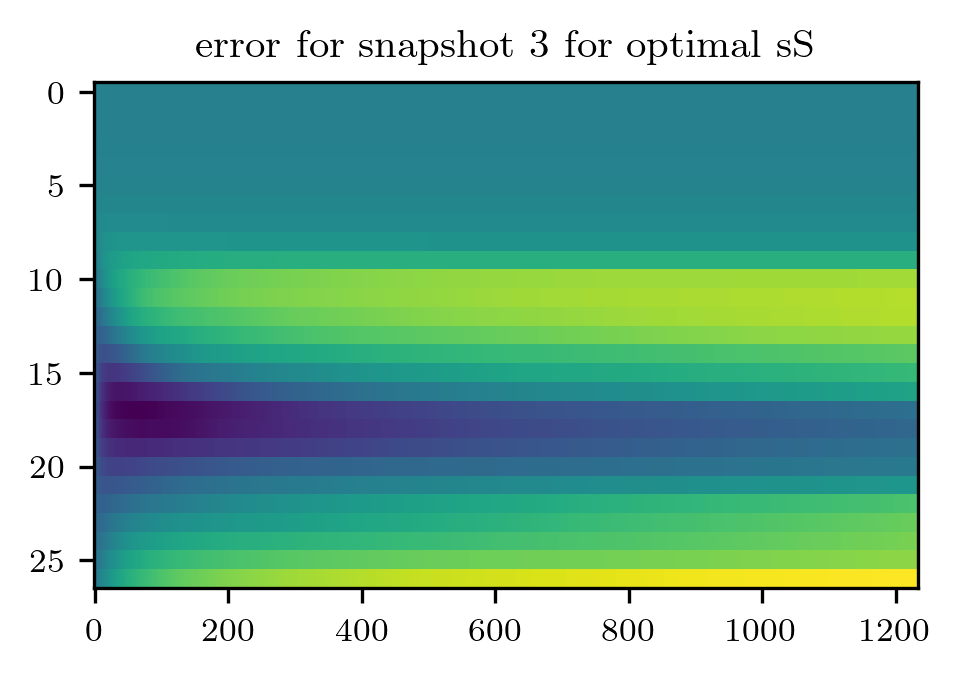

8 17 17 18 0.02432966297656134
0 0.0 12 0.05217115219059544
1 0.1 13 0.0489201794778844
2 0.2 14 0.0439811063610077
3 0.3 15 0.036645051919756866
4 0.4 16 0.02866355089724565
5 0.5 17 0.02432966297656134
6 0.6 18 0.02646074036263448
7 0.7 19 0.03352284874564401
8 0.8 20 0.04003973591540326
9 0.9 21 0.04536148274123573
10 1.0 22 0.04912173567289542


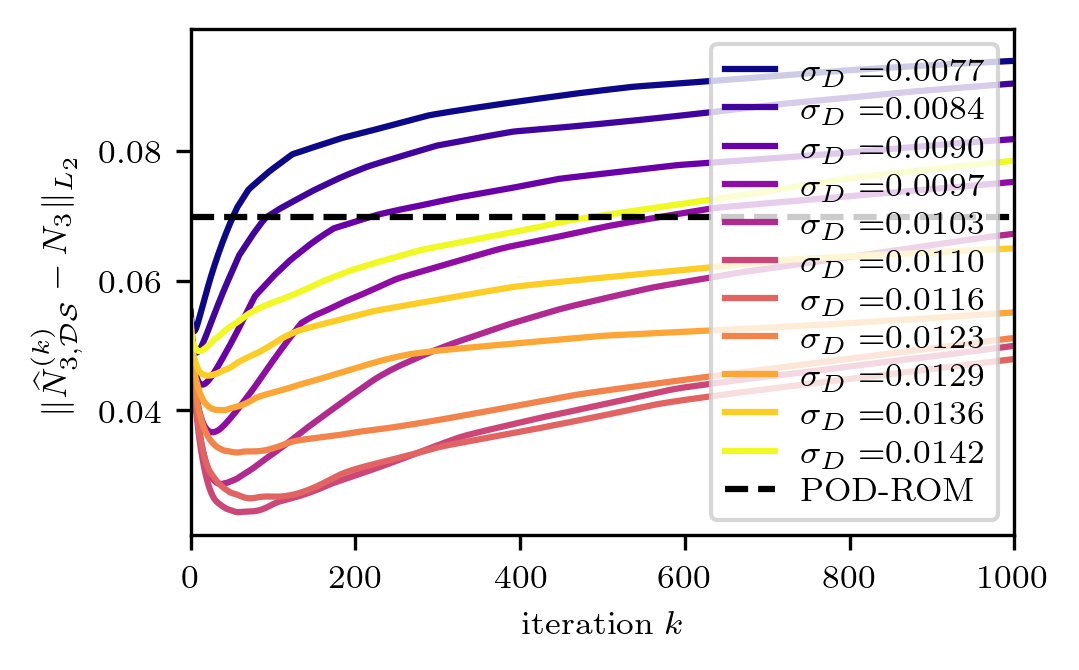

0 0.0 12 0.05217115219059544
1 0.1 13 0.0489201794778844
2 0.2 14 0.0439811063610077
3 0.3 15 0.036645051919756866
4 0.4 16 0.02866355089724565
5 0.5 17 0.02432966297656134
6 0.6 18 0.02646074036263448
7 0.7 19 0.03352284874564401
8 0.8 20 0.04003973591540326
9 0.9 21 0.04536148274123573
10 1.0 22 0.04912173567289542


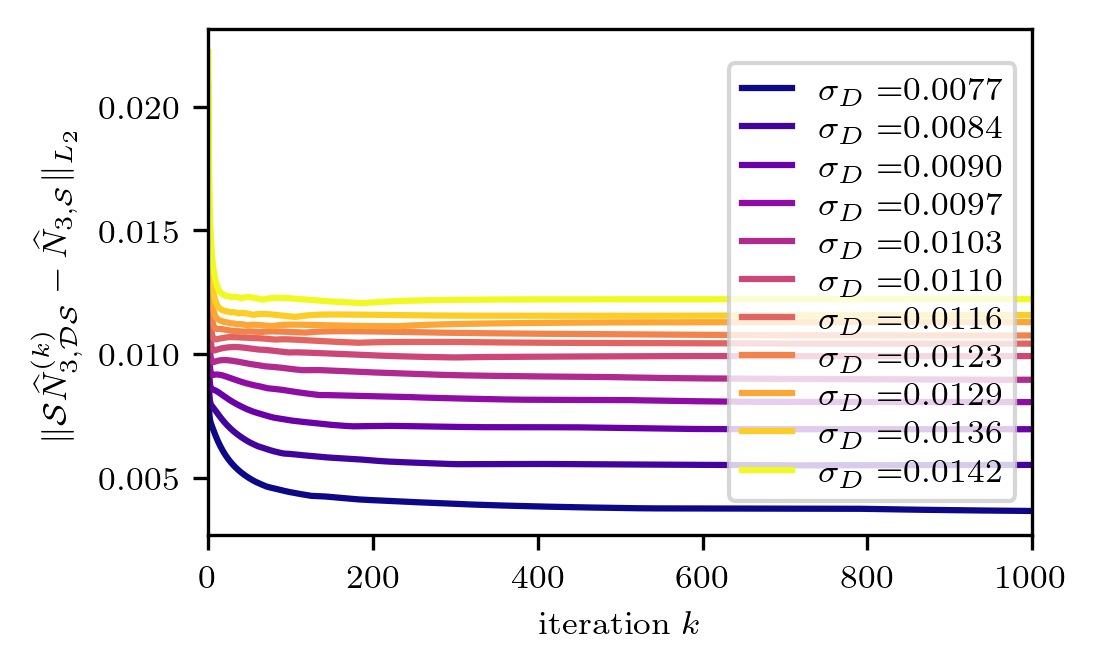

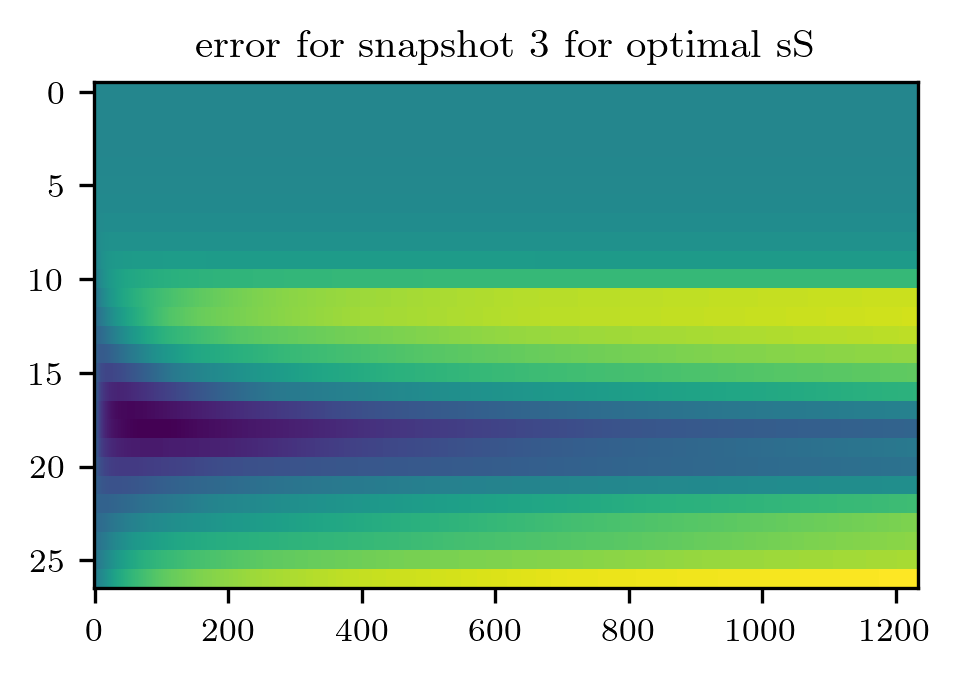

9 18 18 18 0.024956590622524488
0 0.0 13 0.049712130968353814
1 0.1 14 0.04589551482869484
2 0.2 15 0.04012548833535672
3 0.3 16 0.03237511473494534
4 0.4 17 0.026331115436142912
5 0.5 18 0.024956590622524488
6 0.6 19 0.03018183130265777
7 0.7 20 0.03731951802964078
8 0.8 21 0.04330115306326771
9 0.9 22 0.04786562859514162
10 1.0 23 0.050812226849463044


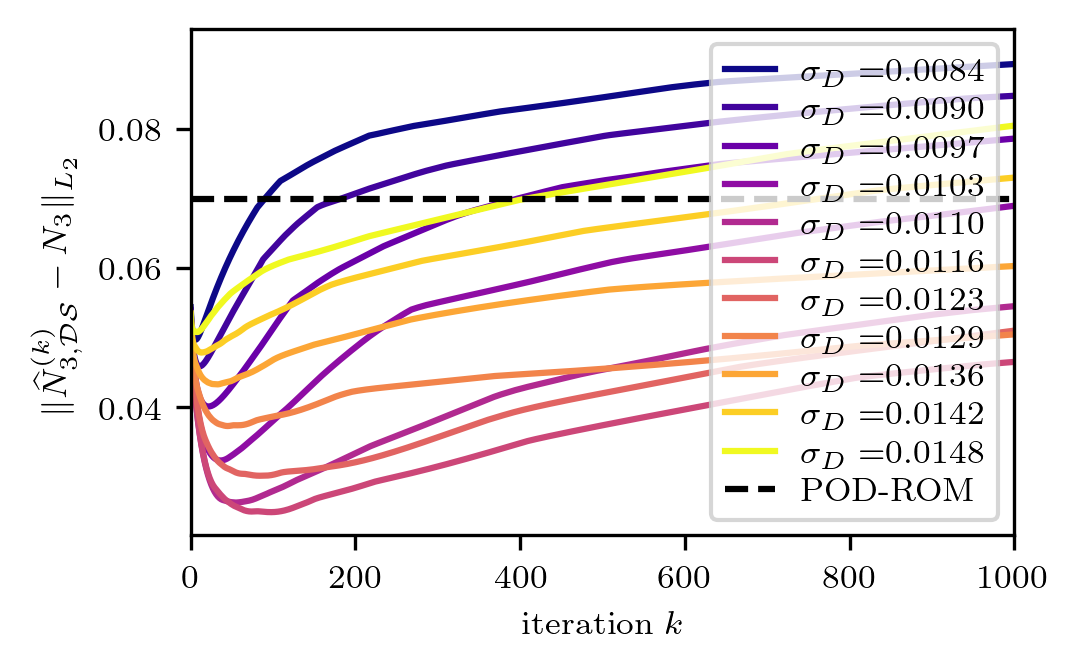

0 0.0 13 0.049712130968353814
1 0.1 14 0.04589551482869484
2 0.2 15 0.04012548833535672
3 0.3 16 0.03237511473494534
4 0.4 17 0.026331115436142912
5 0.5 18 0.024956590622524488
6 0.6 19 0.03018183130265777
7 0.7 20 0.03731951802964078
8 0.8 21 0.04330115306326771
9 0.9 22 0.04786562859514162
10 1.0 23 0.050812226849463044


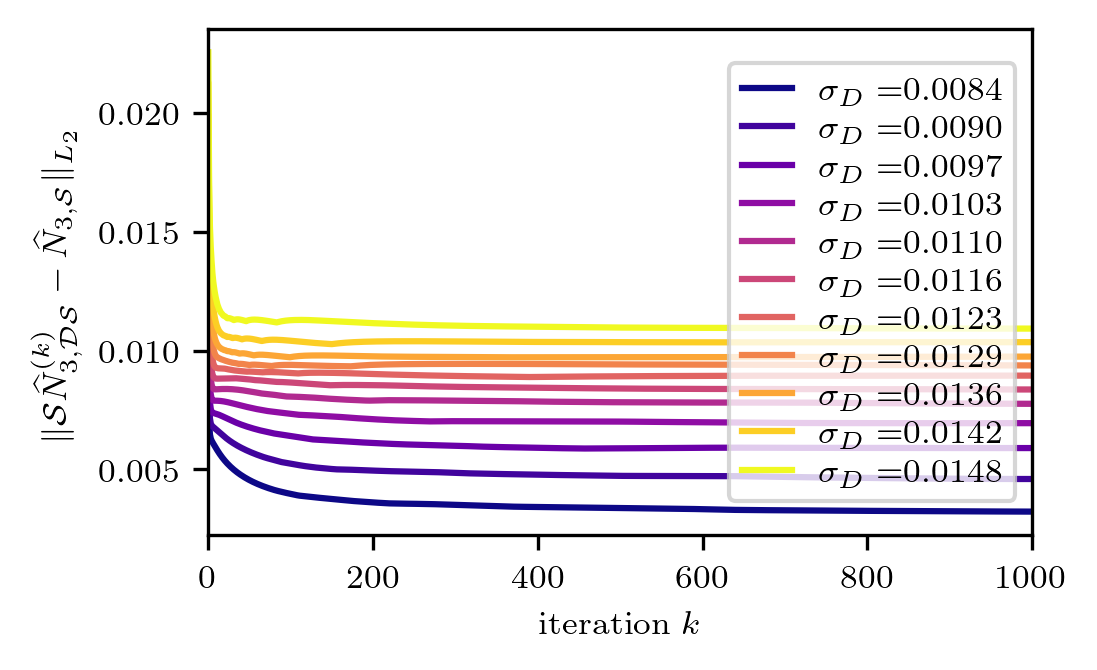

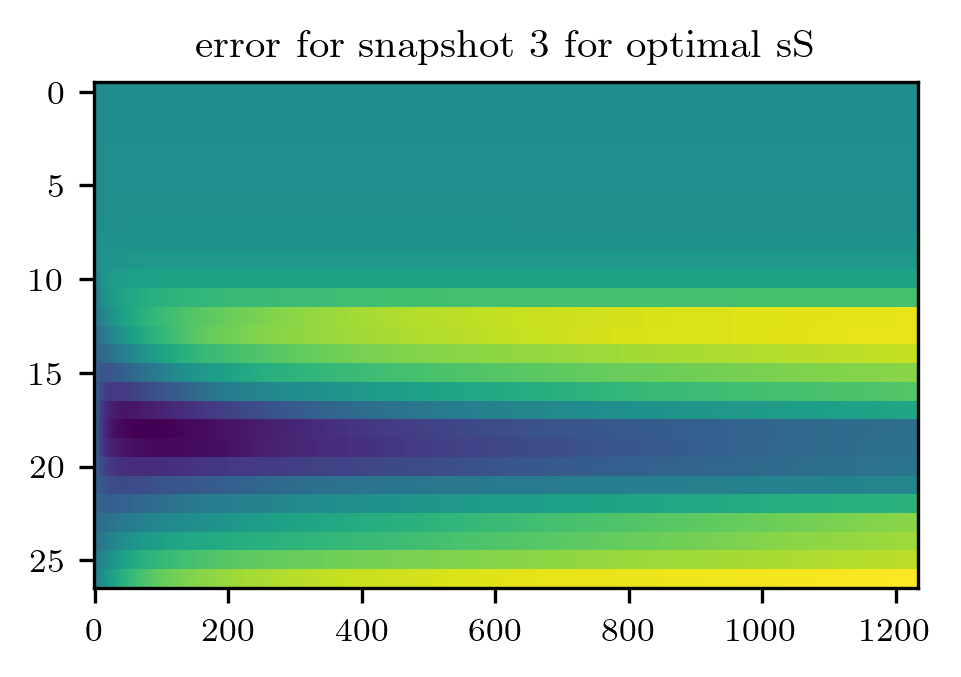

10 18 19 18 0.025404566856112528
0 0.0 14 0.04755558108455193
1 0.1 15 0.0431829687353144
2 0.2 16 0.03668925605486777
3 0.3 17 0.029424540163847896
4 0.4 18 0.025404566856112528
5 0.5 19 0.027104345702494502
6 0.6 20 0.03398062072965072
7 0.7 21 0.040575439441117155
8 0.8 22 0.04617350680007966
9 0.9 23 0.04968586692616512
10 1.0 24 0.05154483860345519


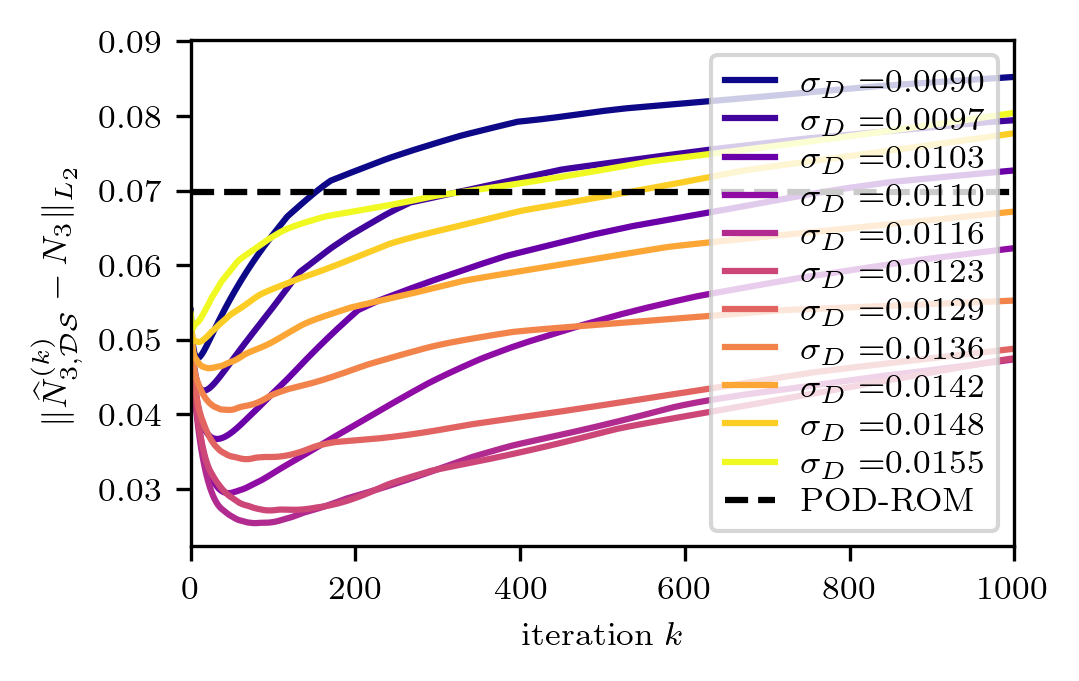

0 0.0 14 0.04755558108455193
1 0.1 15 0.0431829687353144
2 0.2 16 0.03668925605486777
3 0.3 17 0.029424540163847896
4 0.4 18 0.025404566856112528
5 0.5 19 0.027104345702494502
6 0.6 20 0.03398062072965072
7 0.7 21 0.040575439441117155
8 0.8 22 0.04617350680007966
9 0.9 23 0.04968586692616512
10 1.0 24 0.05154483860345519


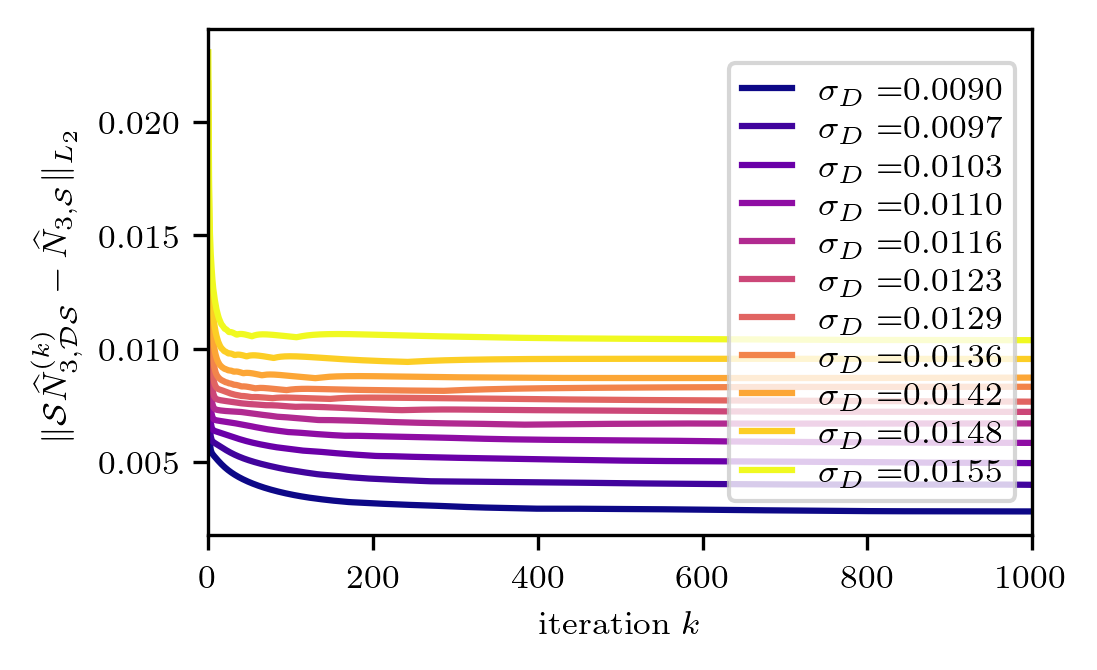

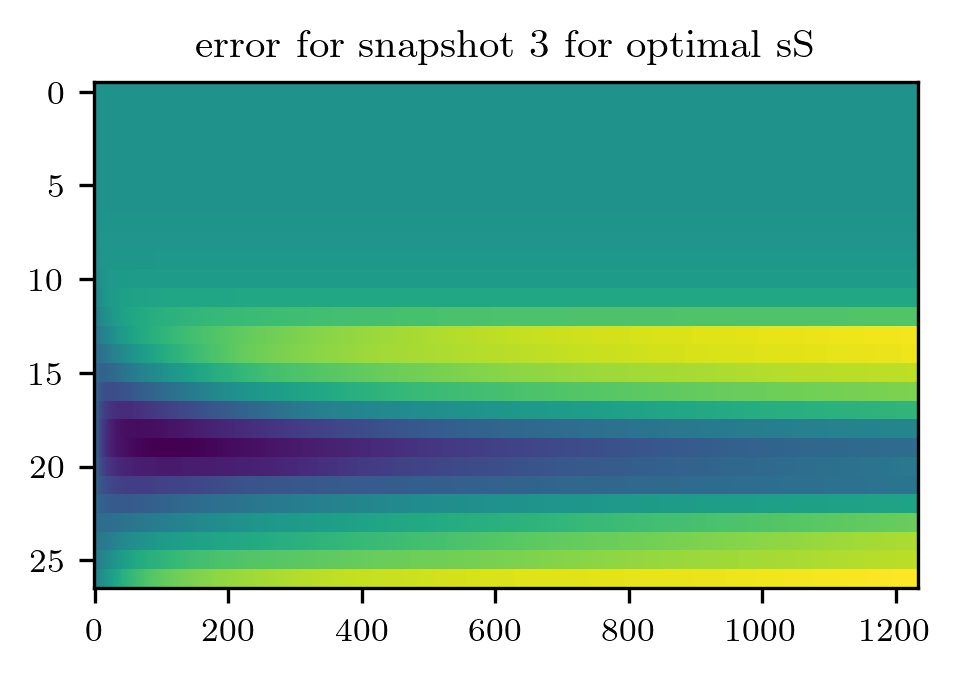

11 19 19 19 0.025620878441466717
0 0.0 14 0.04901398692026527
1 0.1 15 0.045685835937449855
2 0.2 16 0.04077412050189743
3 0.3 17 0.03379822627638612
4 0.4 18 0.02784051901292591
5 0.5 19 0.025620878441466717
6 0.6 20 0.030123852255182135
7 0.7 21 0.03732717044033342
8 0.8 22 0.04357879025309976
9 0.9 23 0.04833802976137904
10 1.0 24 0.0507533242378194


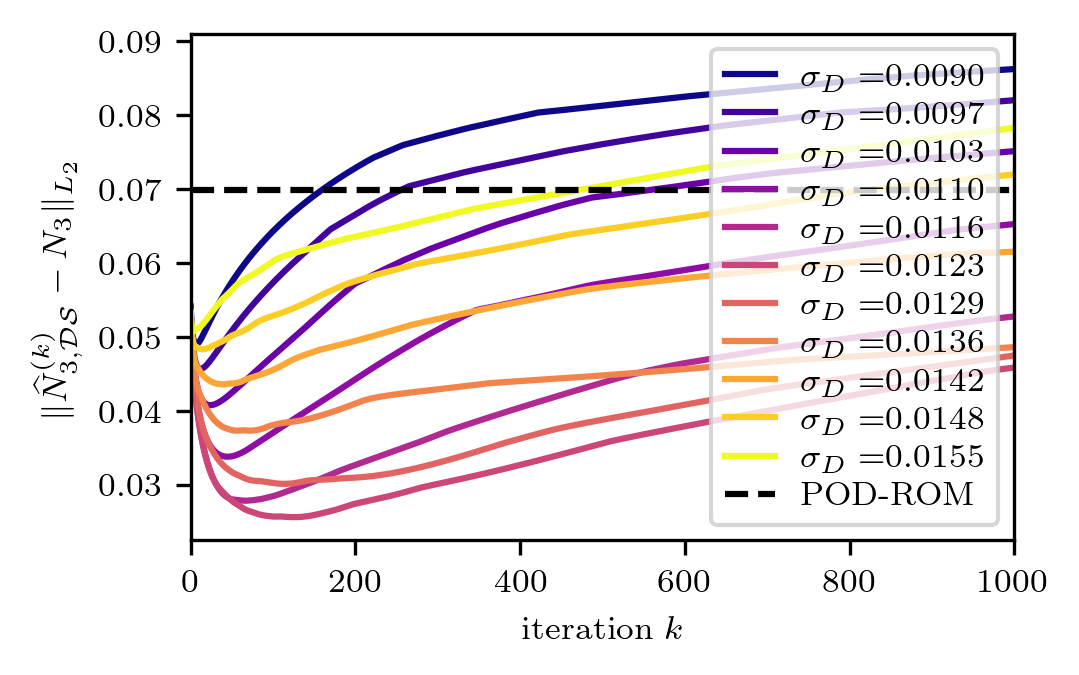

0 0.0 14 0.04901398692026527
1 0.1 15 0.045685835937449855
2 0.2 16 0.04077412050189743
3 0.3 17 0.03379822627638612
4 0.4 18 0.02784051901292591
5 0.5 19 0.025620878441466717
6 0.6 20 0.030123852255182135
7 0.7 21 0.03732717044033342
8 0.8 22 0.04357879025309976
9 0.9 23 0.04833802976137904
10 1.0 24 0.0507533242378194


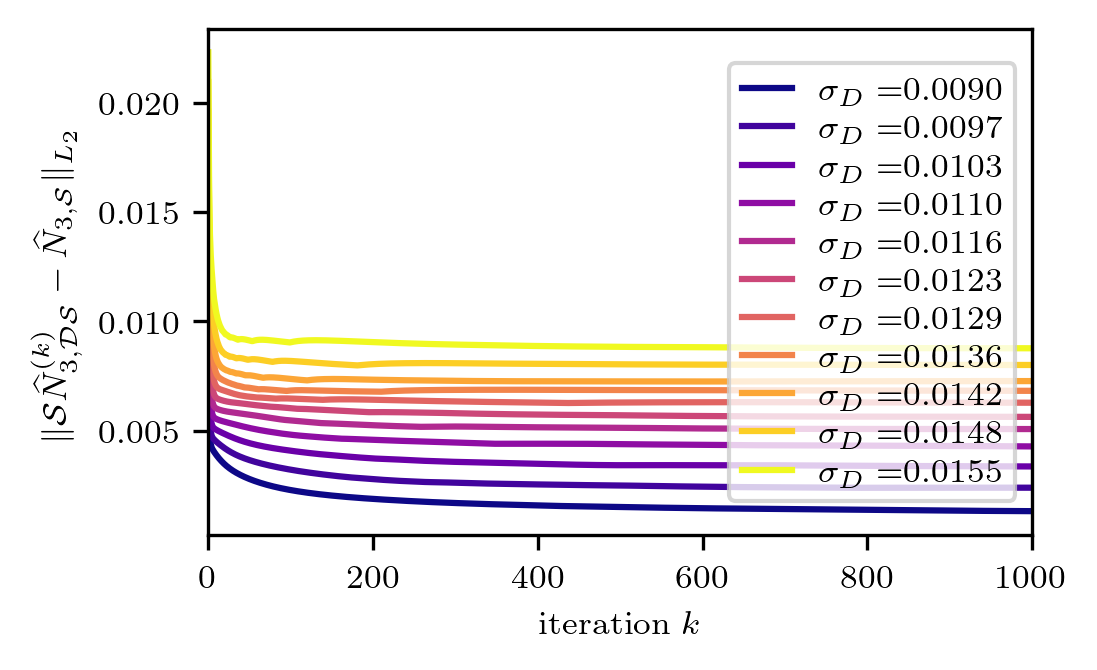

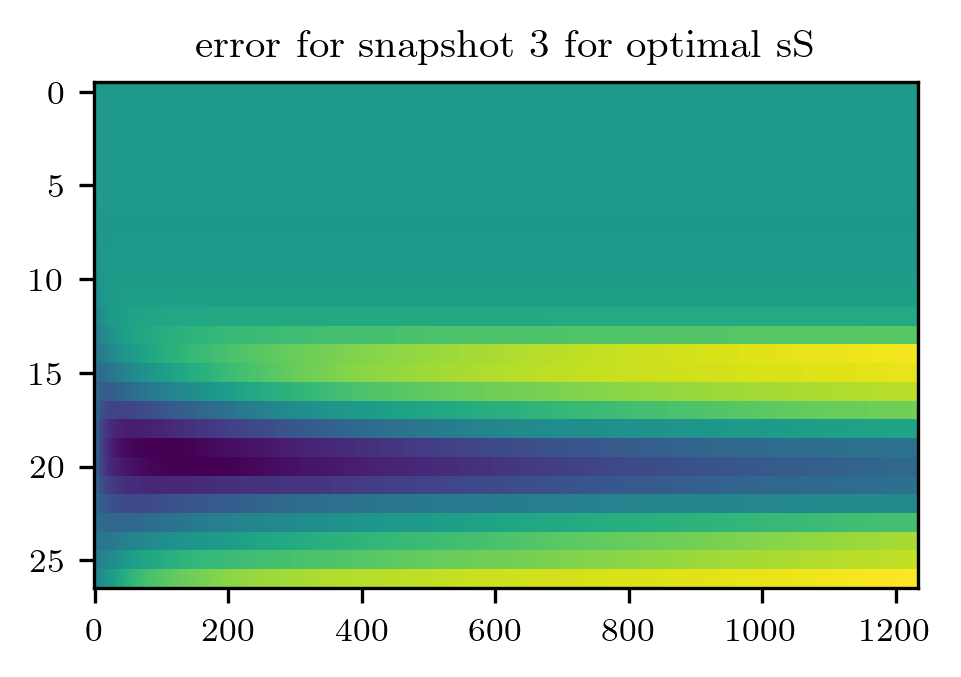

12 19 20 20 0.02686423559327344
0 0.0 15 0.047750724712074664
1 0.1 16 0.04409281456820442
2 0.2 17 0.03864760046602796
3 0.3 18 0.03156242932141816
4 0.4 19 0.02686423559327344
5 0.5 20 0.026950676094088088
6 0.6 21 0.033437881609994224
7 0.7 22 0.04013640982158832
8 0.8 23 0.04628226970018736
9 0.9 24 0.04980907069658639
10 1.0 25 0.05169513904687555


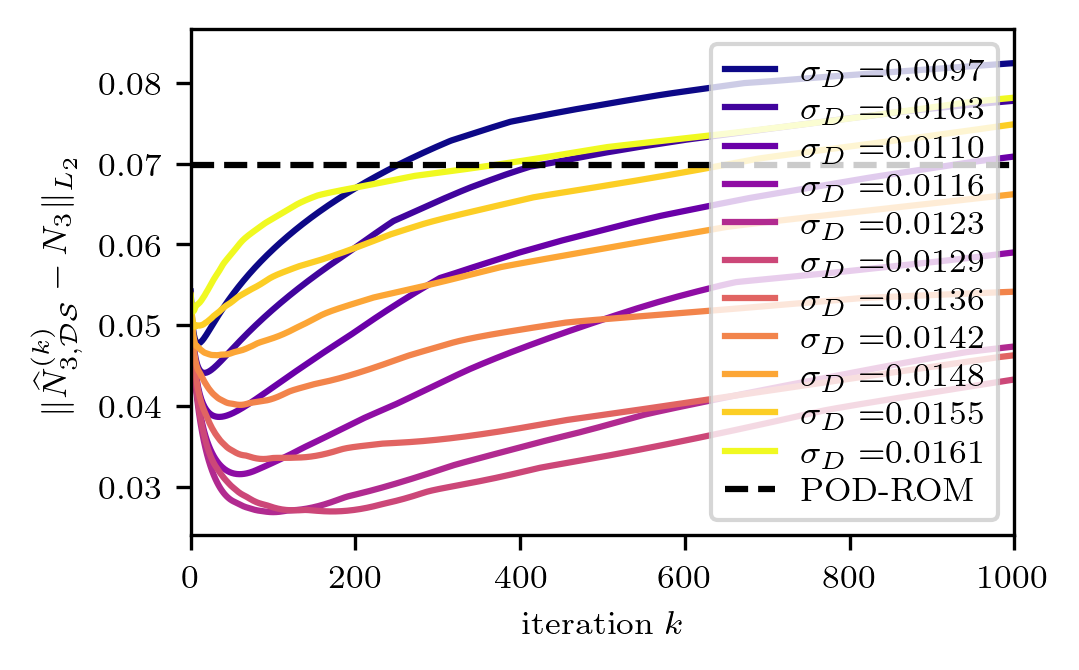

0 0.0 15 0.047750724712074664
1 0.1 16 0.04409281456820442
2 0.2 17 0.03864760046602796
3 0.3 18 0.03156242932141816
4 0.4 19 0.02686423559327344
5 0.5 20 0.026950676094088088
6 0.6 21 0.033437881609994224
7 0.7 22 0.04013640982158832
8 0.8 23 0.04628226970018736
9 0.9 24 0.04980907069658639
10 1.0 25 0.05169513904687555


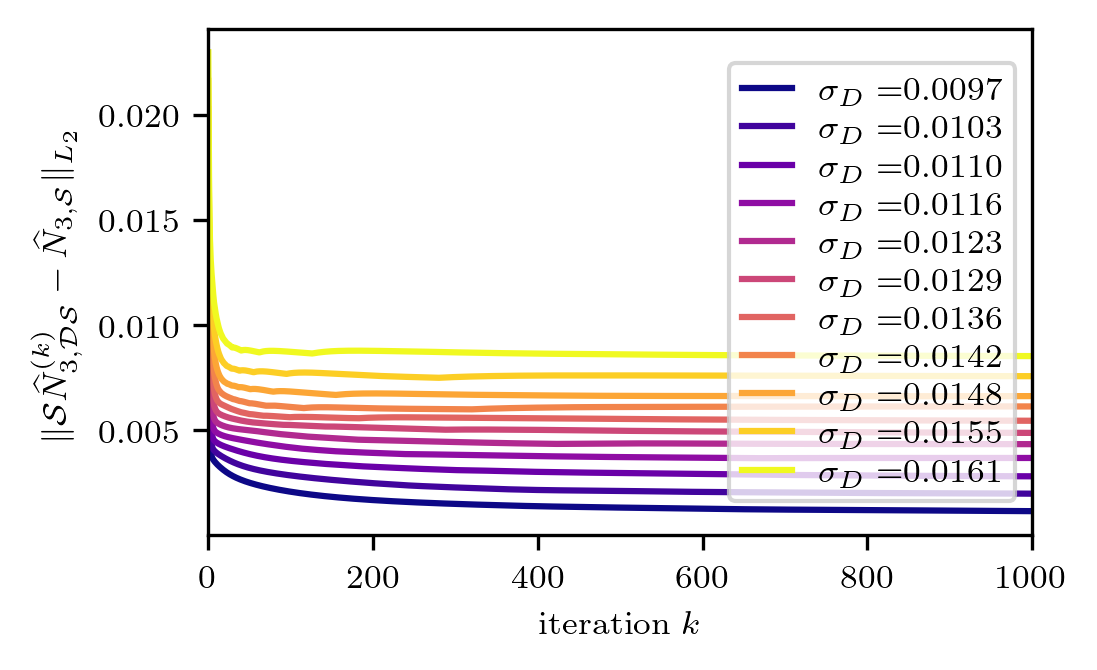

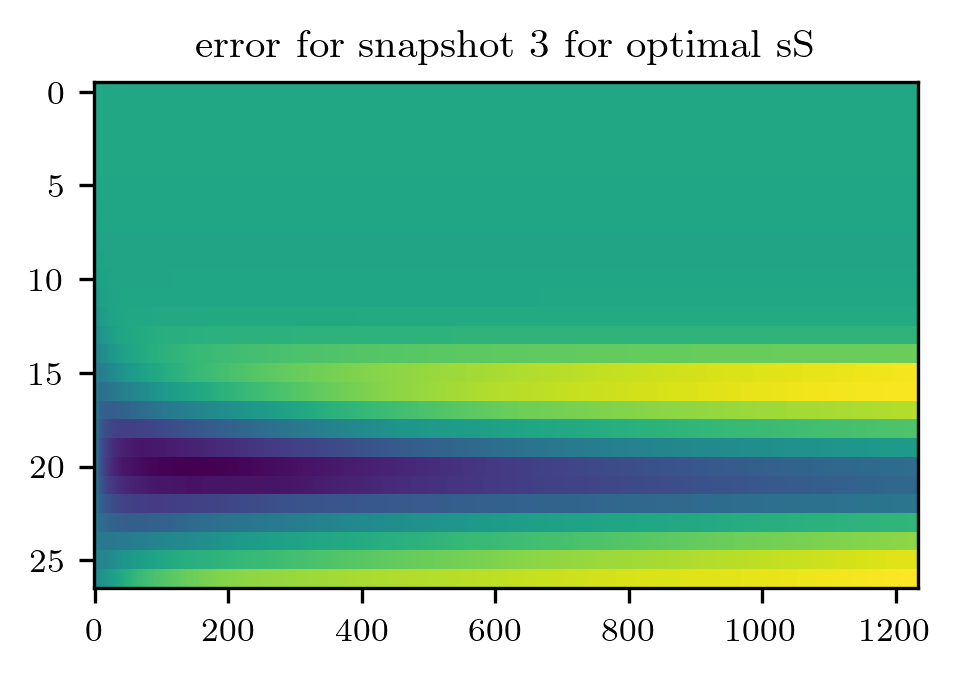

13 20 20 21 0.026518342552055693
0 0.0 15 0.04952857514125464
1 0.1 16 0.04671399344604058
2 0.2 17 0.04273264853309291
3 0.3 18 0.03678018315903762
4 0.4 19 0.030057780875200585
5 0.5 20 0.026518342552055693
6 0.6 21 0.02923359685935565
7 0.7 22 0.03627855063161555
8 0.8 23 0.04291088952991462
9 0.9 24 0.04835268541475512
10 1.0 25 0.05093643462773153


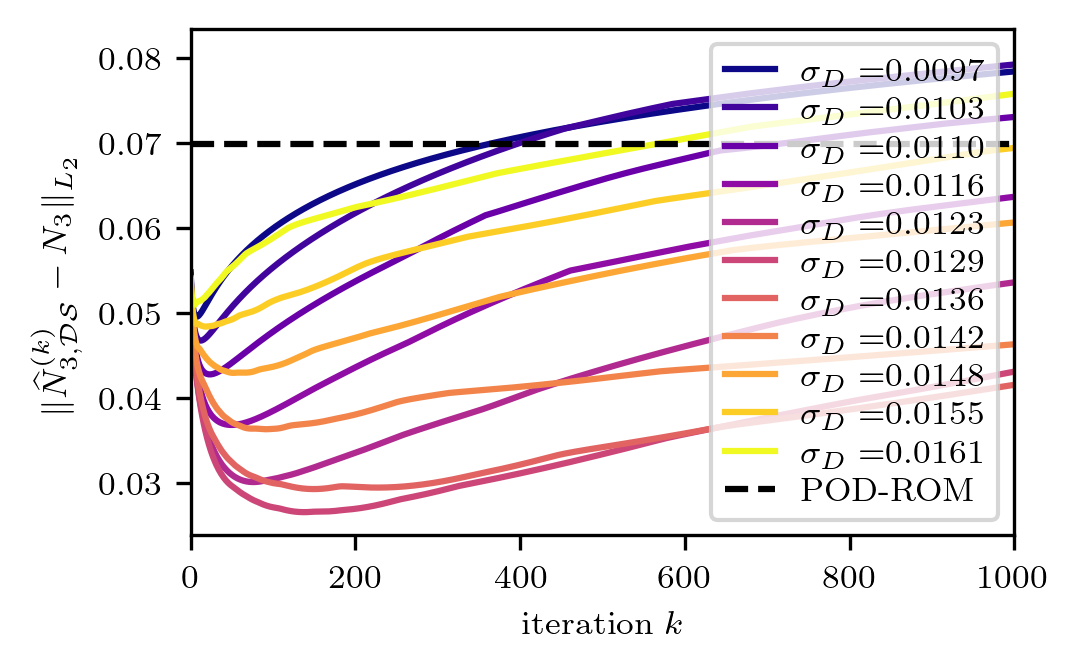

0 0.0 15 0.04952857514125464
1 0.1 16 0.04671399344604058
2 0.2 17 0.04273264853309291
3 0.3 18 0.03678018315903762
4 0.4 19 0.030057780875200585
5 0.5 20 0.026518342552055693
6 0.6 21 0.02923359685935565
7 0.7 22 0.03627855063161555
8 0.8 23 0.04291088952991462
9 0.9 24 0.04835268541475512
10 1.0 25 0.05093643462773153


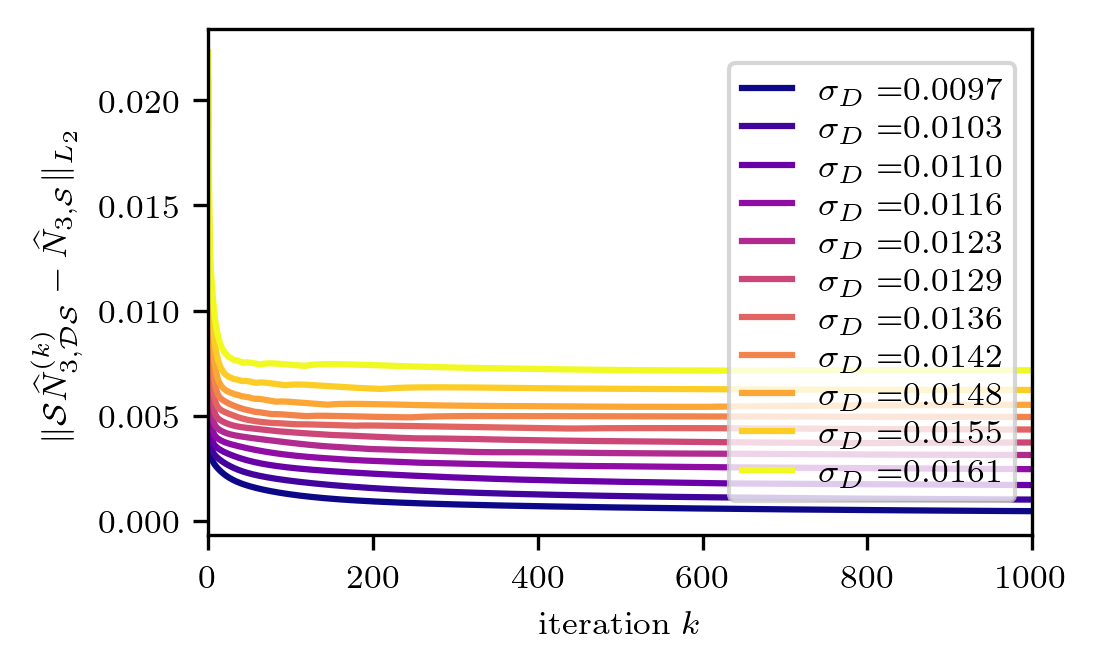

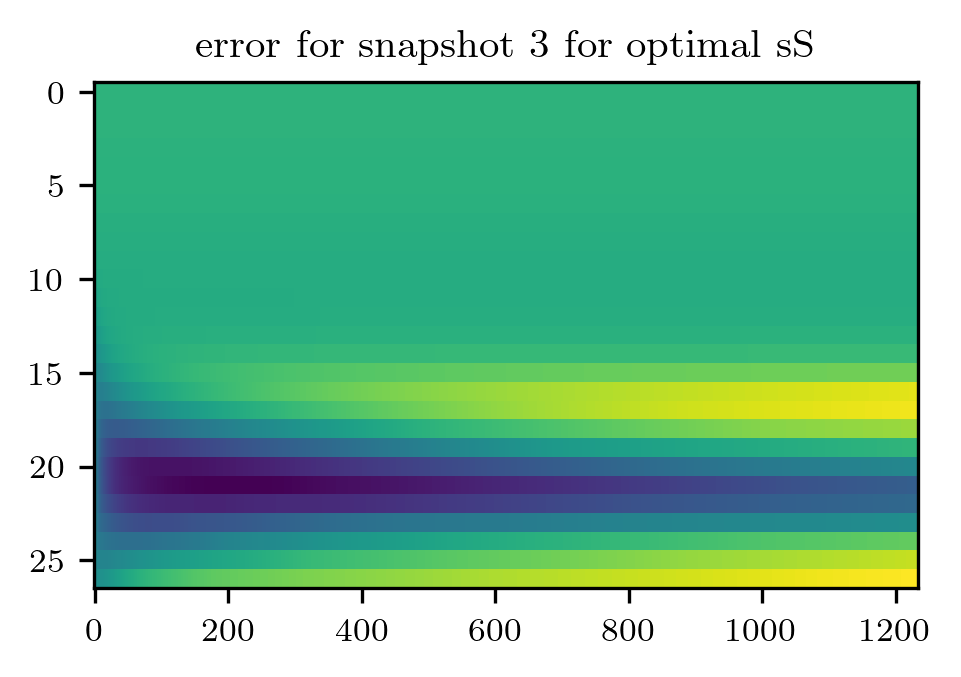

14 21 21 21 0.026837096763646366
0 0.0 16 0.04887528960021982
1 0.1 17 0.04587222476429992
2 0.2 18 0.04156782596249733
3 0.3 19 0.03516359068406492
4 0.4 20 0.02923917842114302
5 0.5 21 0.026837096763646366
6 0.6 22 0.031901347179000894
7 0.7 23 0.03880213895496853
8 0.8 24 0.0454729336494374
9 0.9 25 0.049861970769644465
10 1.0 26 0.052066326044722194


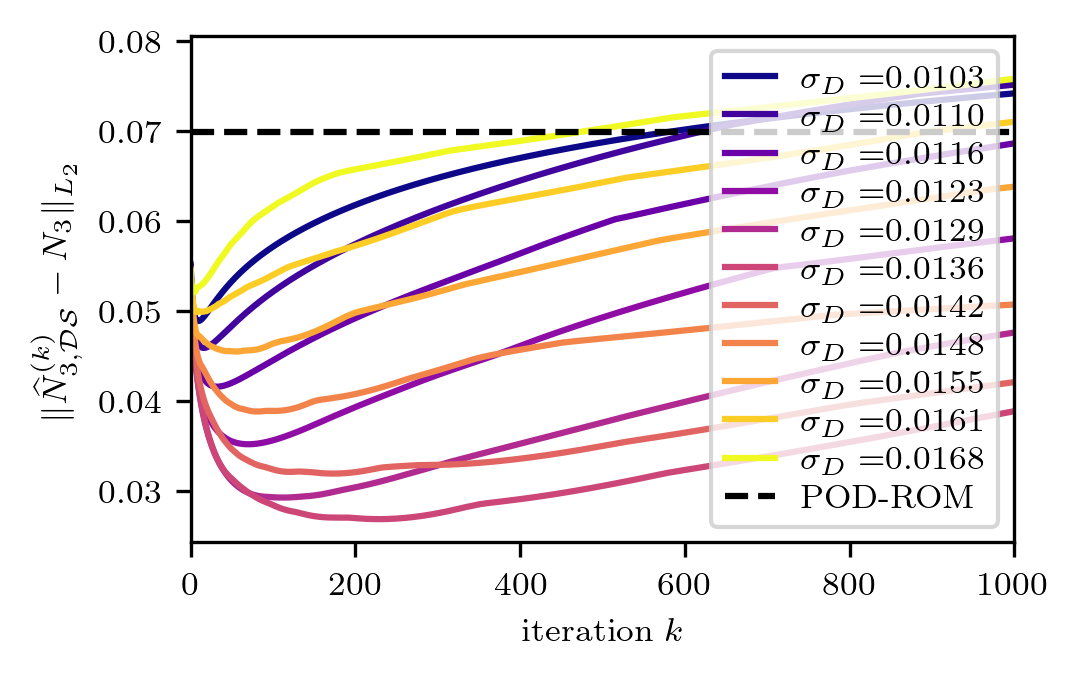

0 0.0 16 0.04887528960021982
1 0.1 17 0.04587222476429992
2 0.2 18 0.04156782596249733
3 0.3 19 0.03516359068406492
4 0.4 20 0.02923917842114302
5 0.5 21 0.026837096763646366
6 0.6 22 0.031901347179000894
7 0.7 23 0.03880213895496853
8 0.8 24 0.0454729336494374
9 0.9 25 0.049861970769644465
10 1.0 26 0.052066326044722194


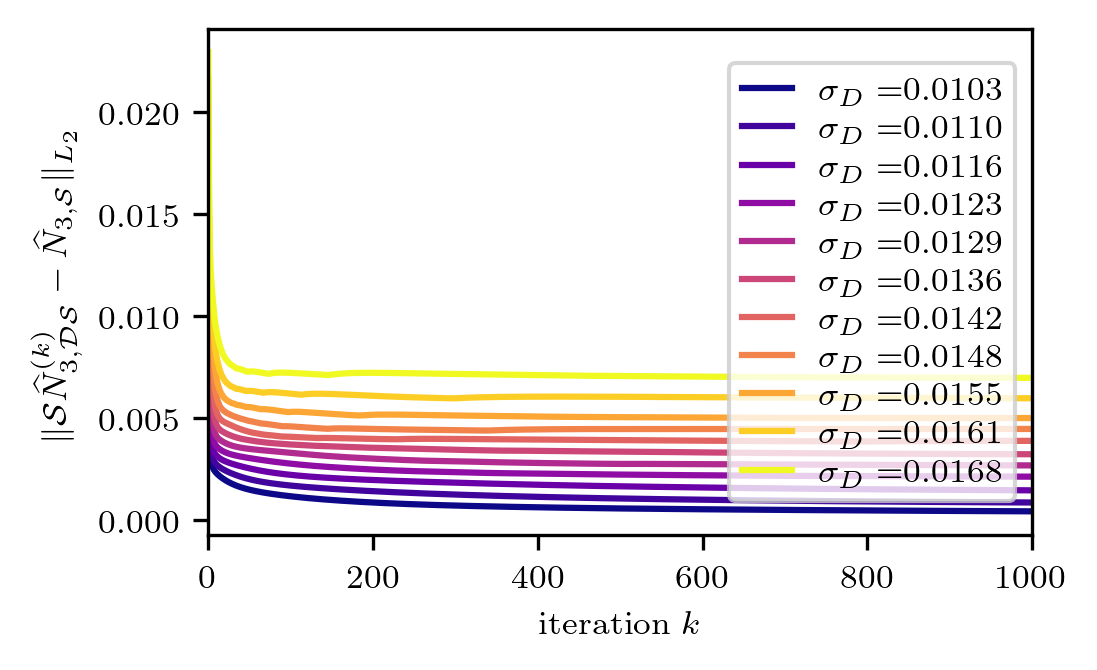

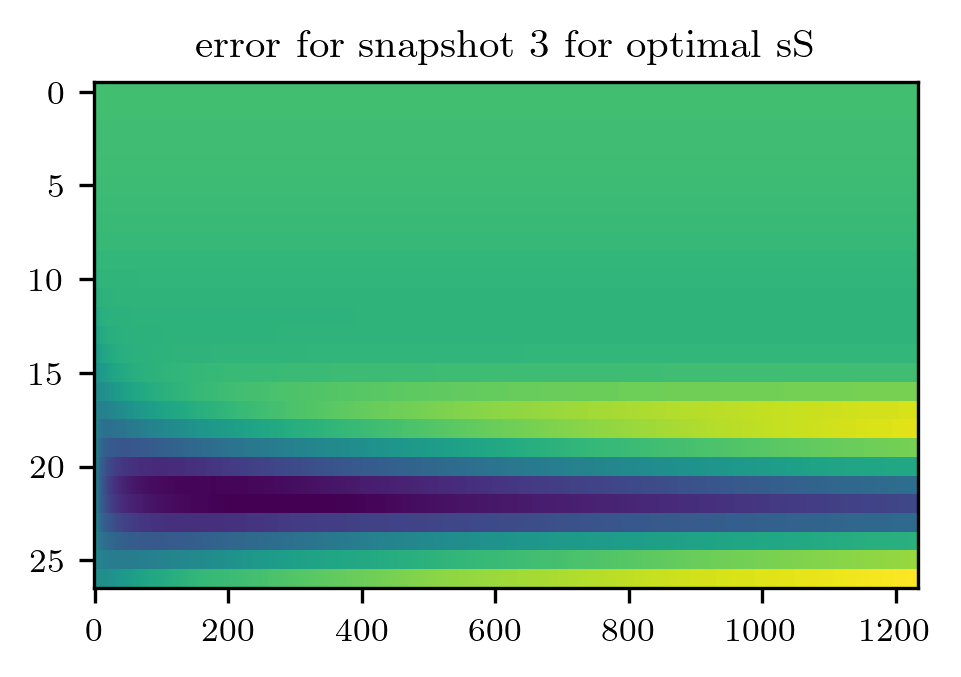

15 21 22 22 0.028011835756797037
0 0.0 17 0.048373433359793654
1 0.1111111111111111 18 0.04519639651649541
2 0.2222222222222222 19 0.0405667050510655
3 0.3333333333333333 20 0.033804248129928896
4 0.4444444444444444 21 0.02855748410167939
5 0.5555555555555556 22 0.028011835756797037
6 0.6666666666666666 23 0.03436164100202692
7 0.7777777777777778 24 0.04111165276997864
8 0.8888888888888888 25 0.04771419779918832
9 1.0 26 0.051052487344793174


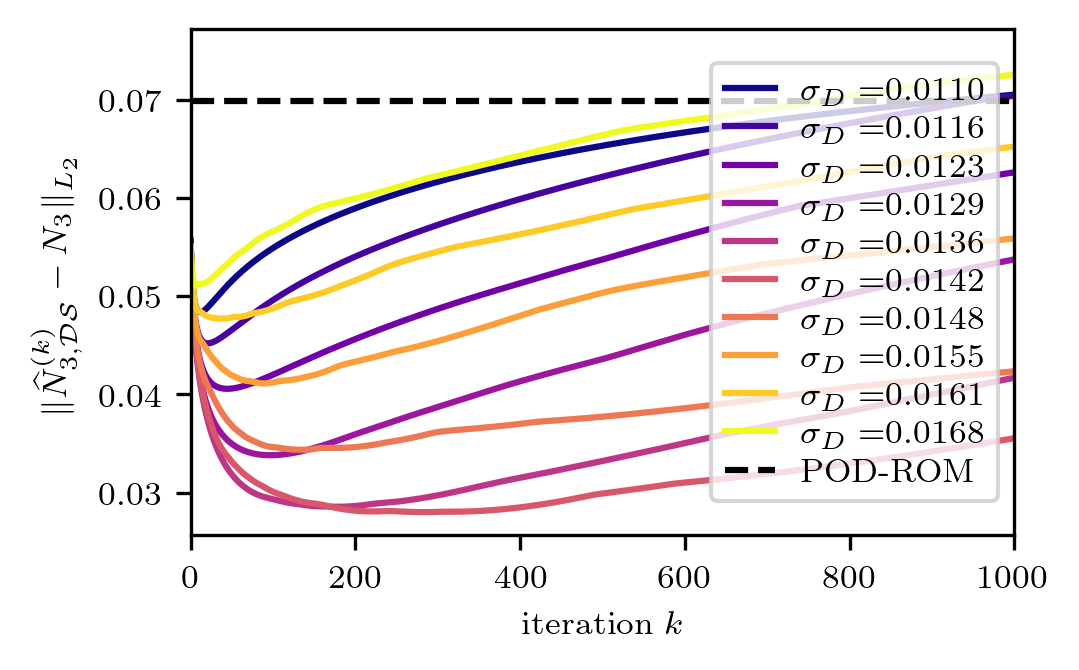

0 0.0 17 0.048373433359793654
1 0.1111111111111111 18 0.04519639651649541
2 0.2222222222222222 19 0.0405667050510655
3 0.3333333333333333 20 0.033804248129928896
4 0.4444444444444444 21 0.02855748410167939
5 0.5555555555555556 22 0.028011835756797037
6 0.6666666666666666 23 0.03436164100202692
7 0.7777777777777778 24 0.04111165276997864
8 0.8888888888888888 25 0.04771419779918832
9 1.0 26 0.051052487344793174


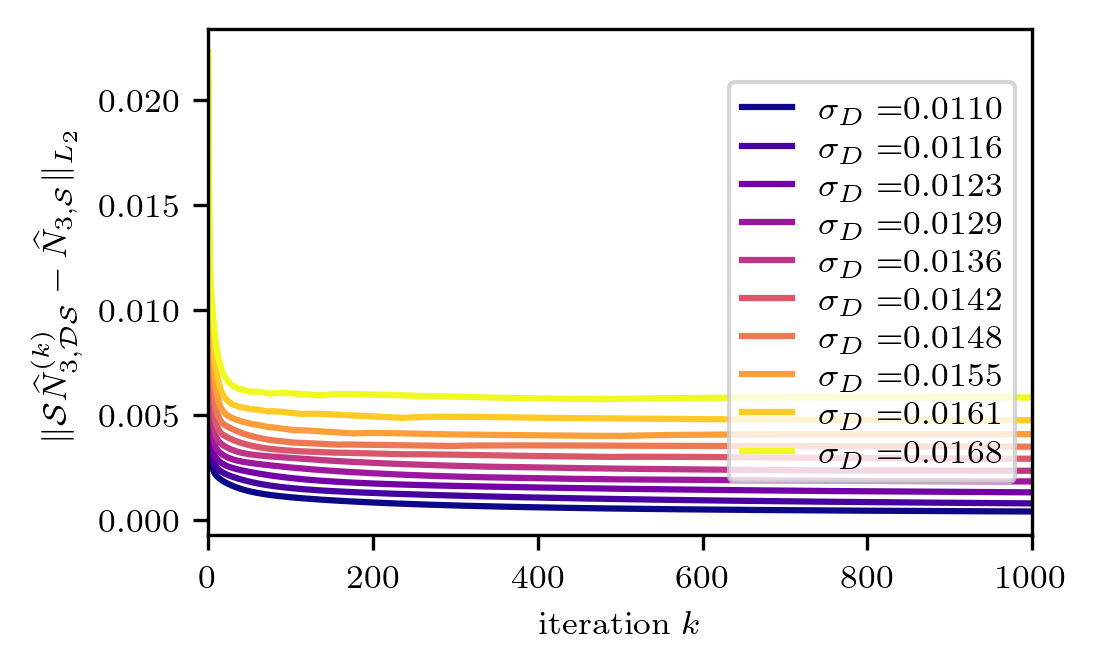

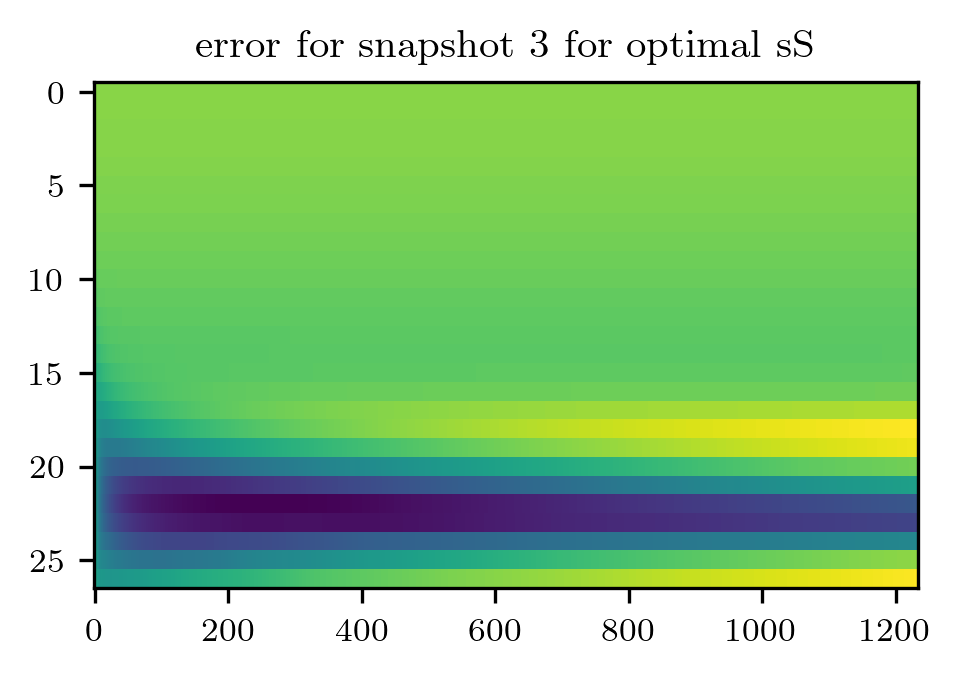

16 22 22 23 0.028175830974428846
0 0.0 17 0.050490938200746786
1 0.1111111111111111 18 0.04800579240747254
2 0.2222222222222222 19 0.044659788053317606
3 0.3333333333333333 20 0.039704271160429586
4 0.4444444444444444 21 0.032717674272065844
5 0.5555555555555556 22 0.028175830974428846
6 0.6666666666666666 23 0.02980885703150416
7 0.7777777777777778 24 0.03643394143919276
8 0.8888888888888888 25 0.0434474017532415
9 1.0 26 0.049344670982791924


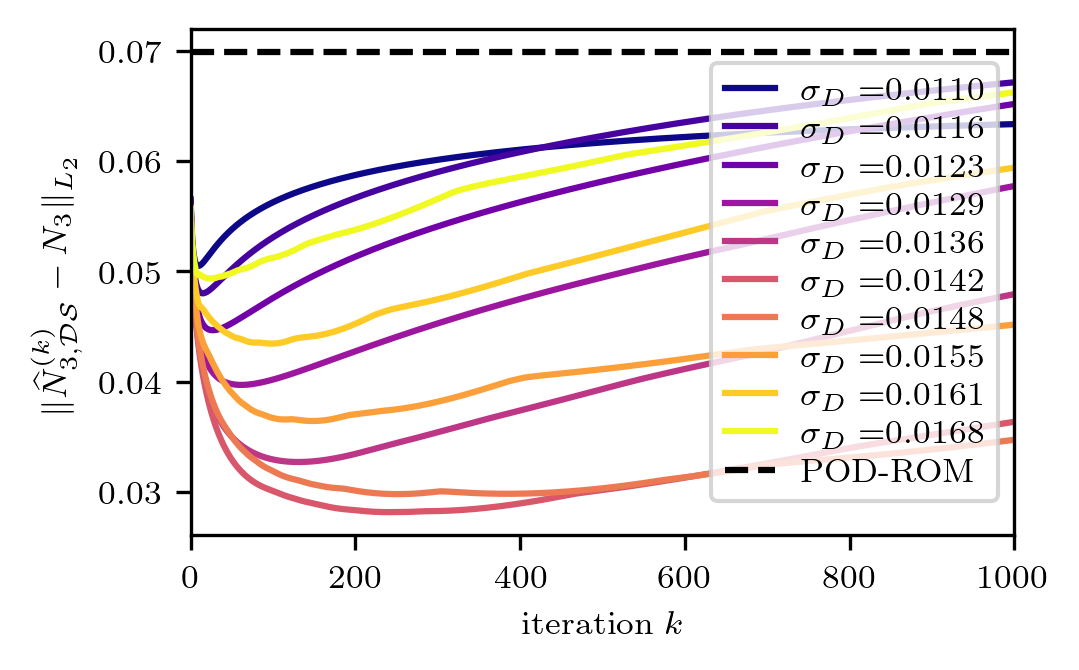

0 0.0 17 0.050490938200746786
1 0.1111111111111111 18 0.04800579240747254
2 0.2222222222222222 19 0.044659788053317606
3 0.3333333333333333 20 0.039704271160429586
4 0.4444444444444444 21 0.032717674272065844
5 0.5555555555555556 22 0.028175830974428846
6 0.6666666666666666 23 0.02980885703150416
7 0.7777777777777778 24 0.03643394143919276
8 0.8888888888888888 25 0.0434474017532415
9 1.0 26 0.049344670982791924


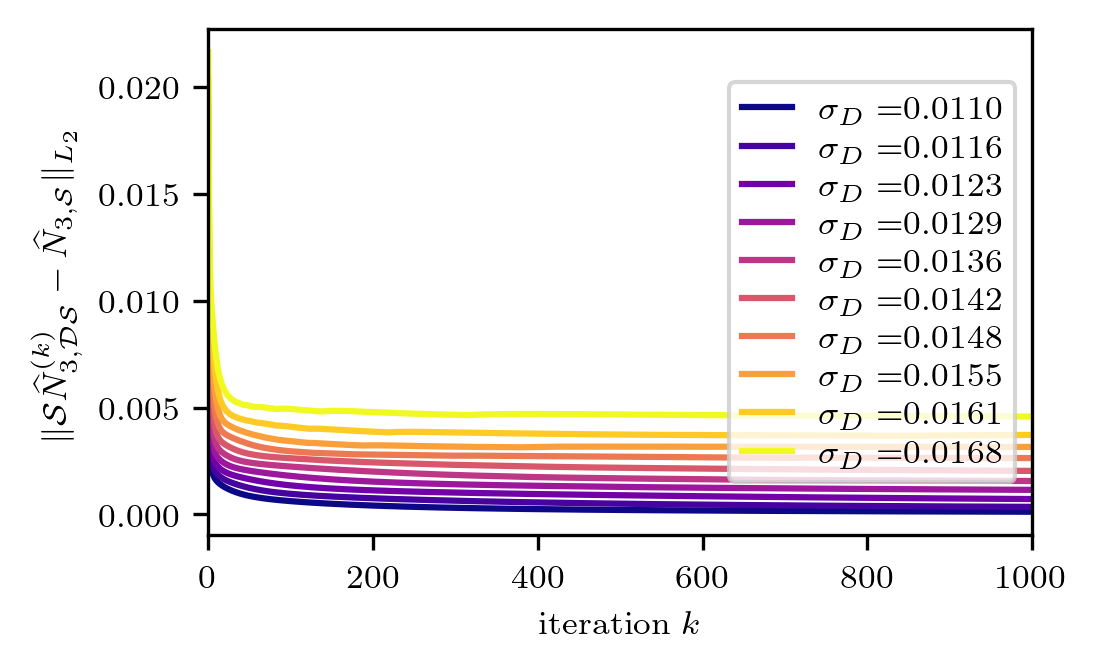

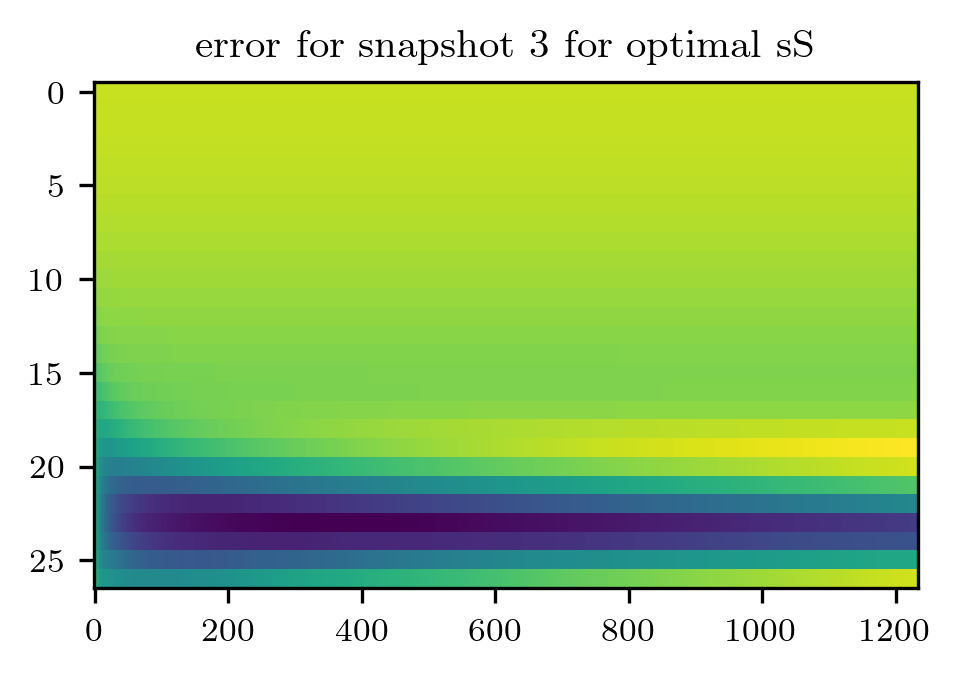

17 23 23 23 0.028103314036787015
0 0.0 18 0.05033306274047823
1 0.125 19 0.04774791814137232
2 0.25 20 0.04424206820506461
3 0.375 21 0.038963912303568986
4 0.5 22 0.031920535466333944
5 0.625 23 0.028103314036787015
6 0.75 24 0.03175618536778388
7 0.875 25 0.0384480554786328
8 1.0 26 0.0457117265335386


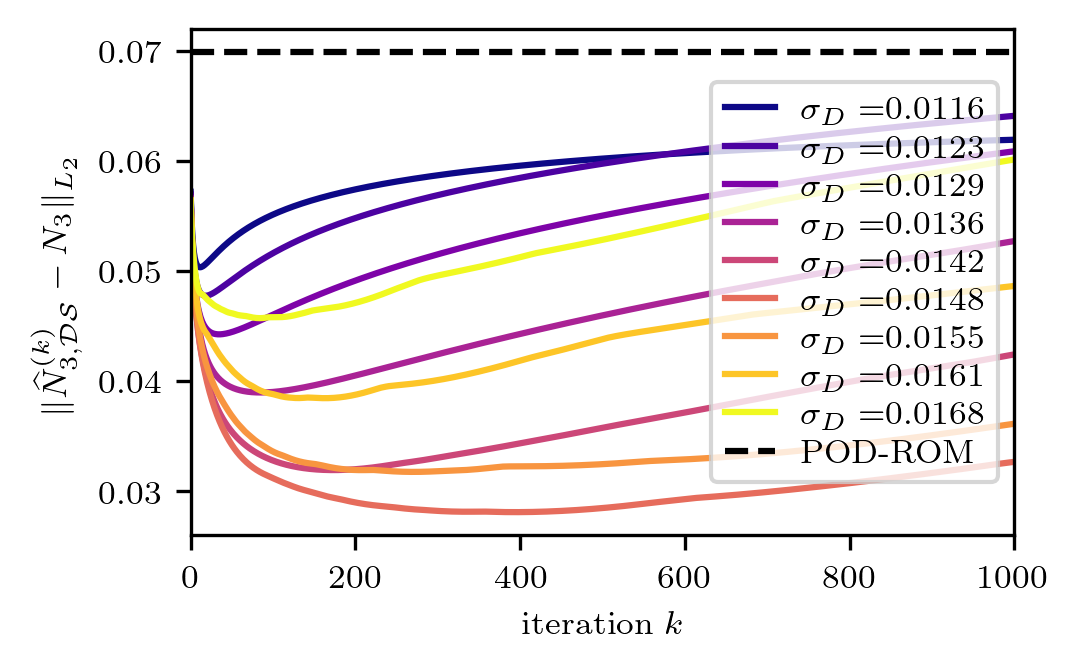

0 0.0 18 0.05033306274047823
1 0.125 19 0.04774791814137232
2 0.25 20 0.04424206820506461
3 0.375 21 0.038963912303568986
4 0.5 22 0.031920535466333944
5 0.625 23 0.028103314036787015
6 0.75 24 0.03175618536778388
7 0.875 25 0.0384480554786328
8 1.0 26 0.0457117265335386


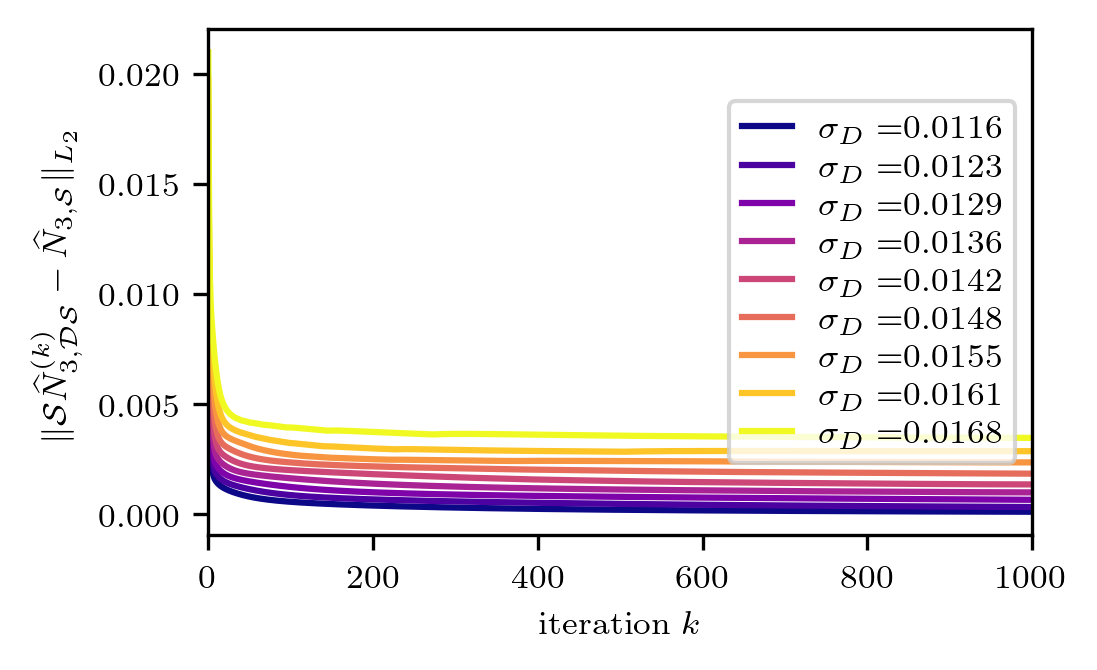

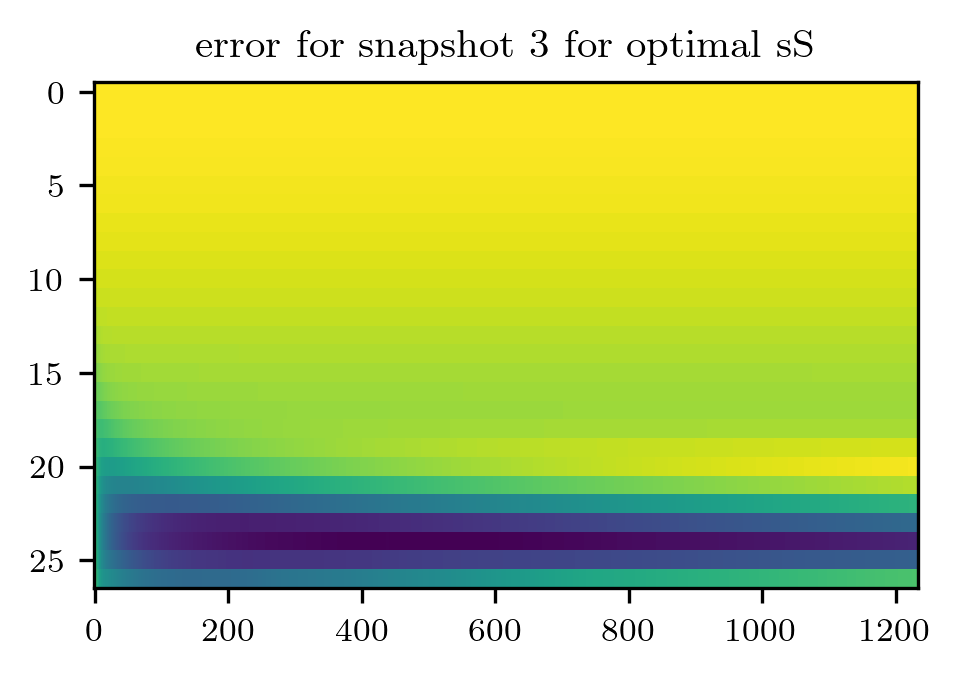

18 24 24 24 0.02843473741894764
0 0.0 19 0.05025919379992764
1 0.14285714285714285 20 0.047583250163082555
2 0.2857142857142857 21 0.043925695805550835
3 0.42857142857142855 22 0.038334613518063373
4 0.5714285714285714 23 0.03141957180295533
5 0.7142857142857143 24 0.02843473741894764
6 0.8571428571428571 25 0.03345008679961596
7 1.0 26 0.04030484562465272


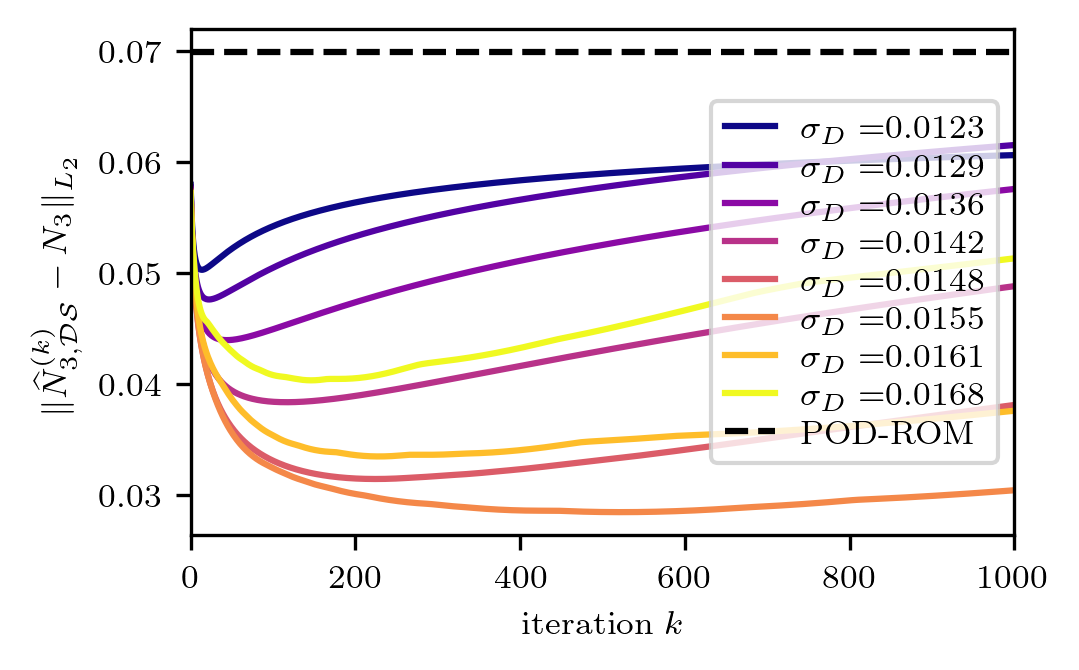

0 0.0 19 0.05025919379992764
1 0.14285714285714285 20 0.047583250163082555
2 0.2857142857142857 21 0.043925695805550835
3 0.42857142857142855 22 0.038334613518063373
4 0.5714285714285714 23 0.03141957180295533
5 0.7142857142857143 24 0.02843473741894764
6 0.8571428571428571 25 0.03345008679961596
7 1.0 26 0.04030484562465272


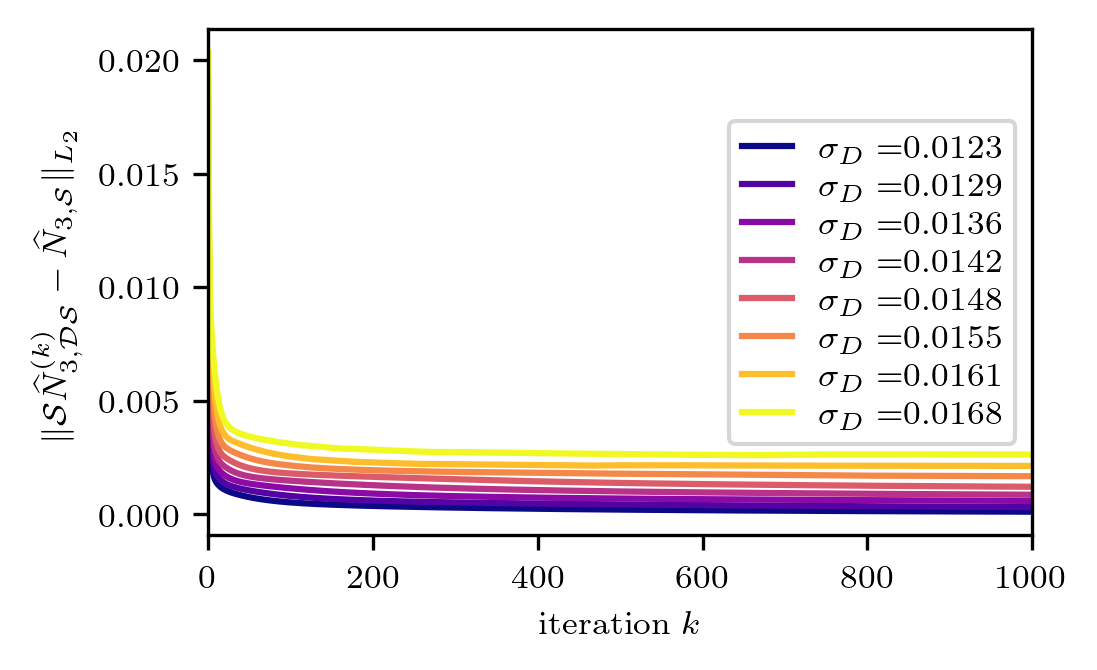

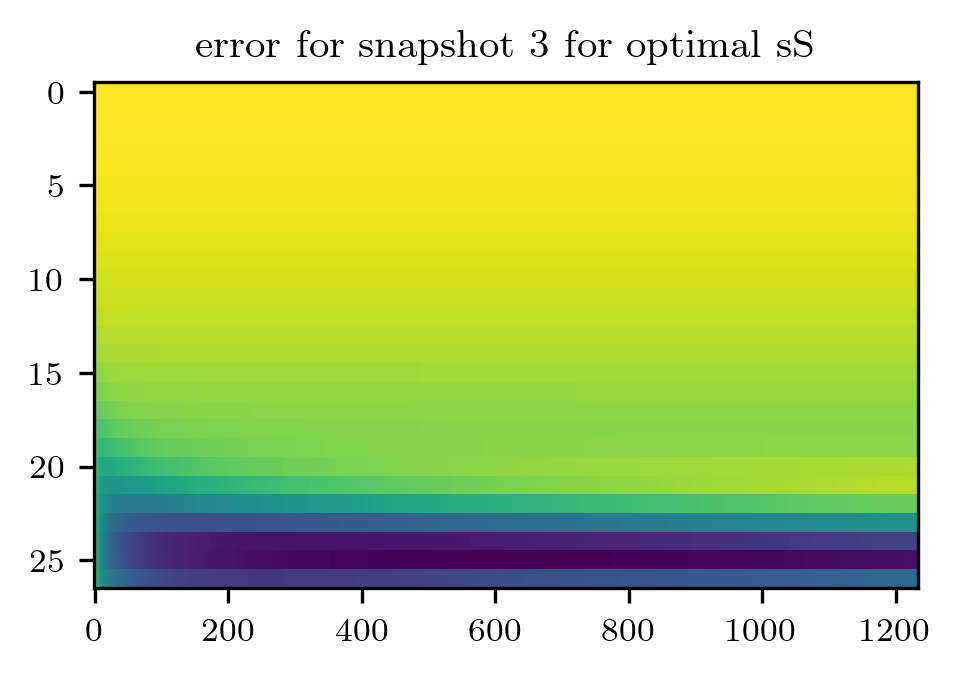

19 24 25 25 0.029251339410804524
0 0.0 20 0.050256987424137894
1 0.16666666666666666 21 0.04749771791044361
2 0.3333333333333333 22 0.043698395294245705
3 0.5 23 0.037809286478143356
4 0.6666666666666666 24 0.03119861737405901
5 0.8333333333333334 25 0.029251339410804524
6 1.0 26 0.03490105042250319


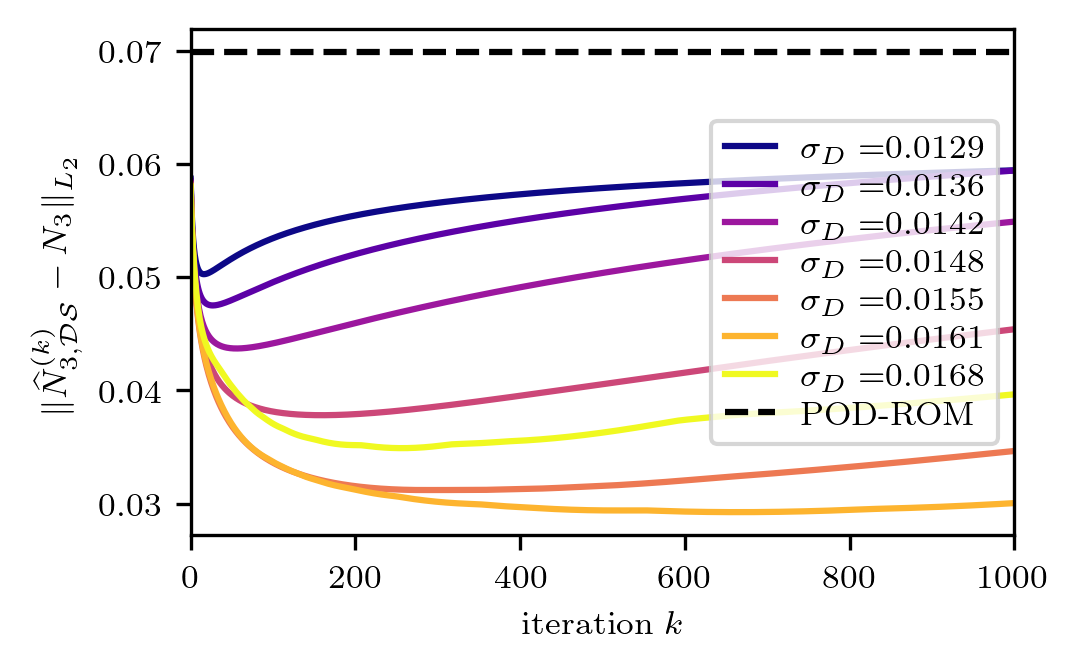

0 0.0 20 0.050256987424137894
1 0.16666666666666666 21 0.04749771791044361
2 0.3333333333333333 22 0.043698395294245705
3 0.5 23 0.037809286478143356
4 0.6666666666666666 24 0.03119861737405901
5 0.8333333333333334 25 0.029251339410804524
6 1.0 26 0.03490105042250319


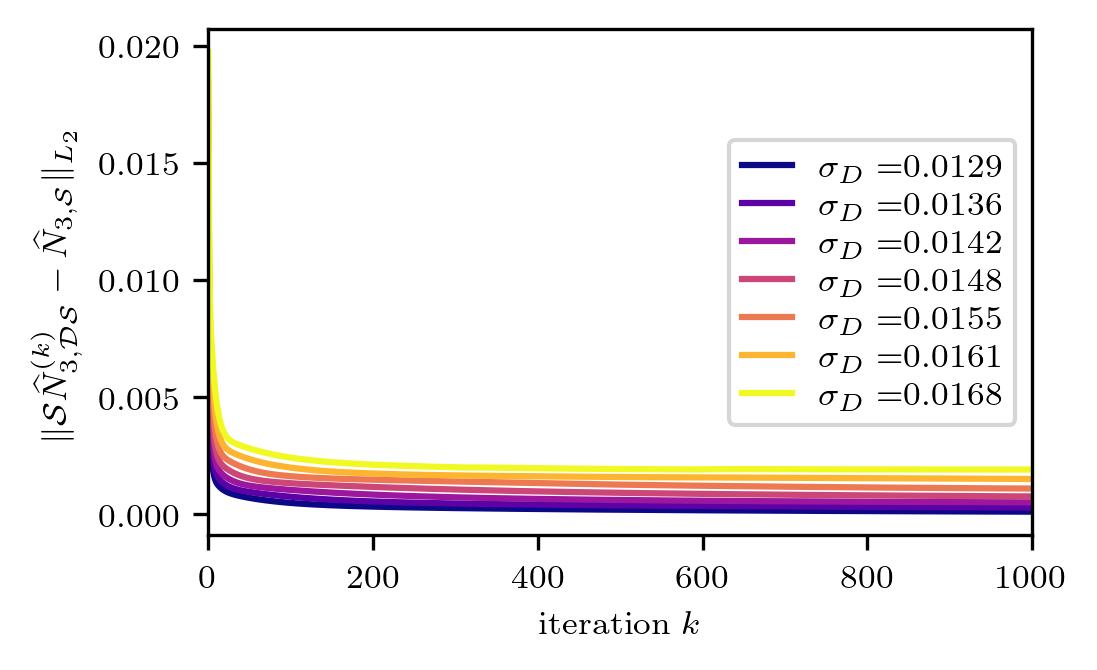

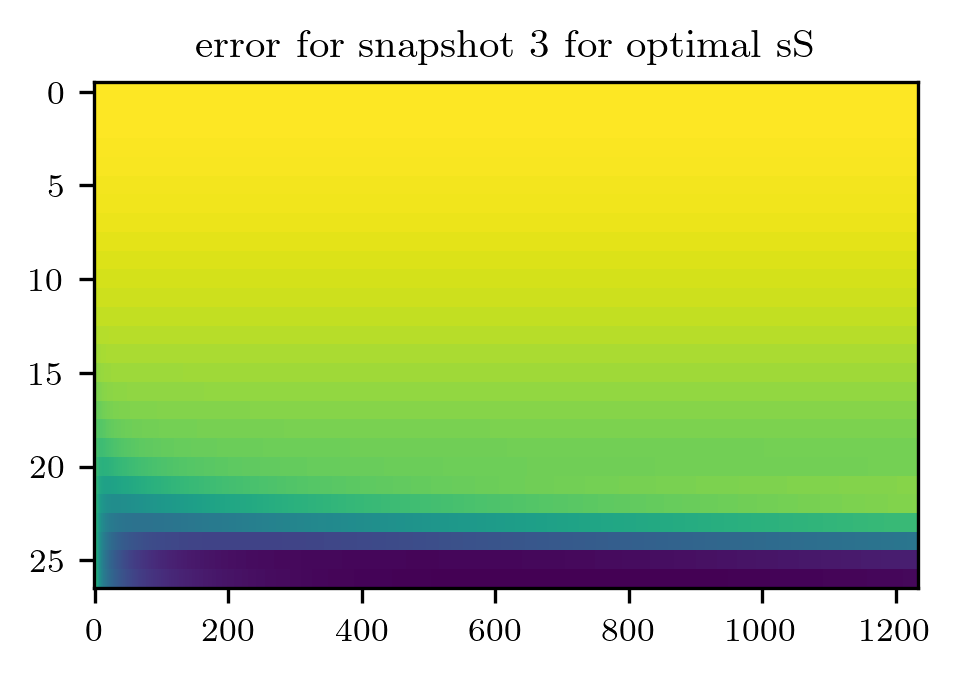

20 25 25 26 0.030451548611594517
0 0.0 20 0.05254571012611112
1 0.16666666666666666 21 0.05031486817355518
2 0.3333333333333333 22 0.047479839817117314
3 0.5 23 0.043549322682529125
4 0.6666666666666666 24 0.037383064259051635
5 0.8333333333333334 25 0.0309852887439659
6 1.0 26 0.030451548611594517


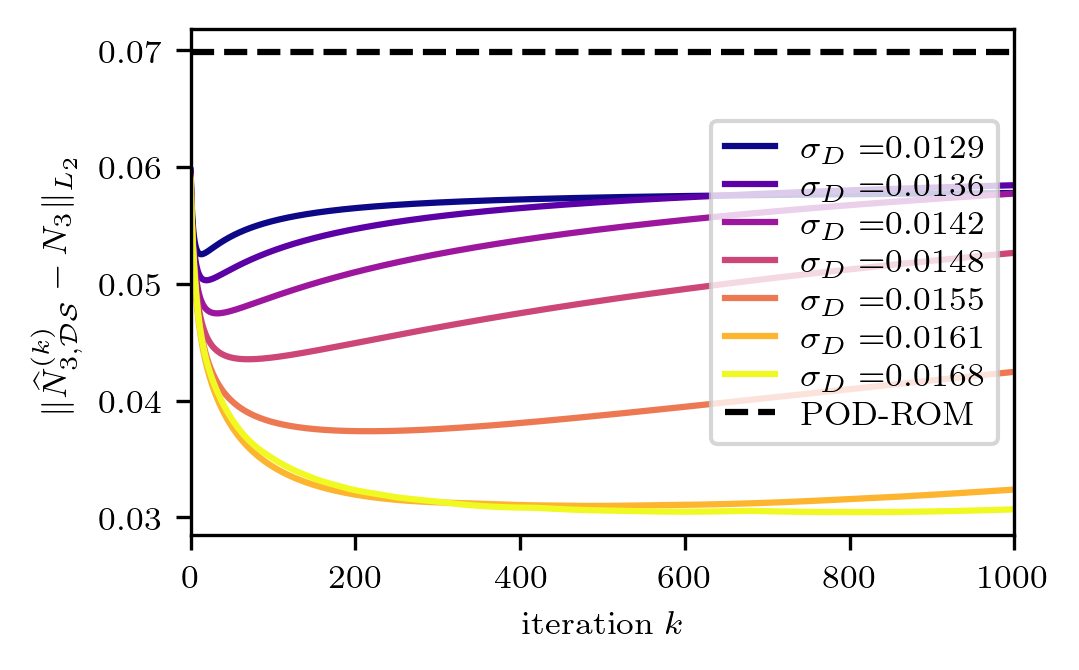

0 0.0 20 0.05254571012611112
1 0.16666666666666666 21 0.05031486817355518
2 0.3333333333333333 22 0.047479839817117314
3 0.5 23 0.043549322682529125
4 0.6666666666666666 24 0.037383064259051635
5 0.8333333333333334 25 0.0309852887439659
6 1.0 26 0.030451548611594517


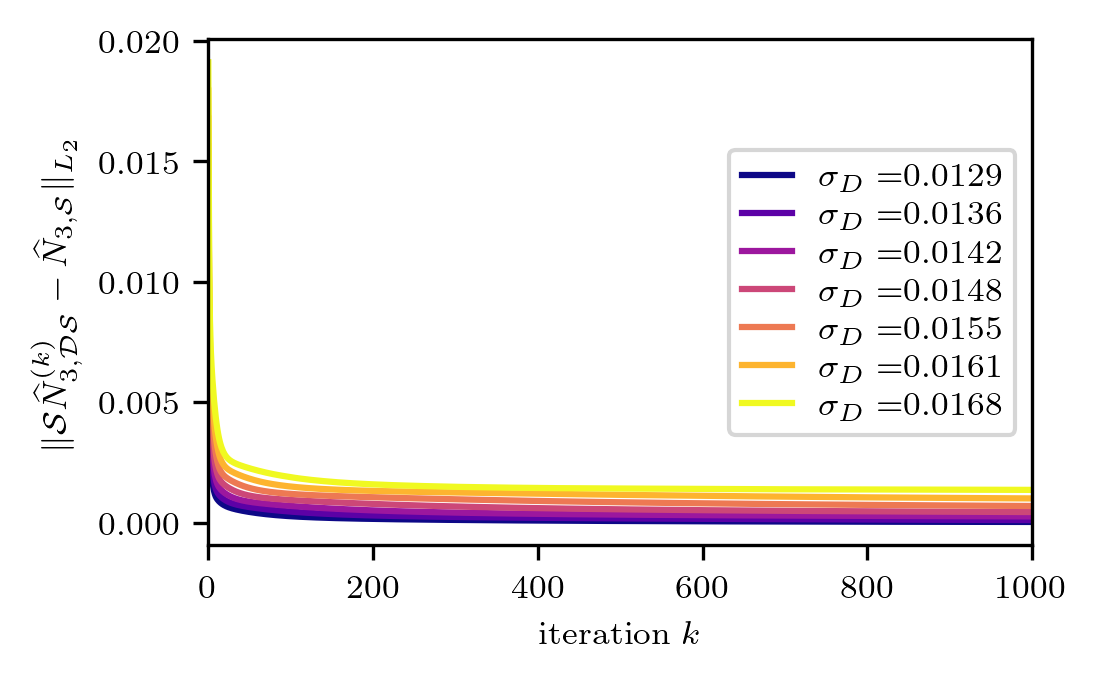

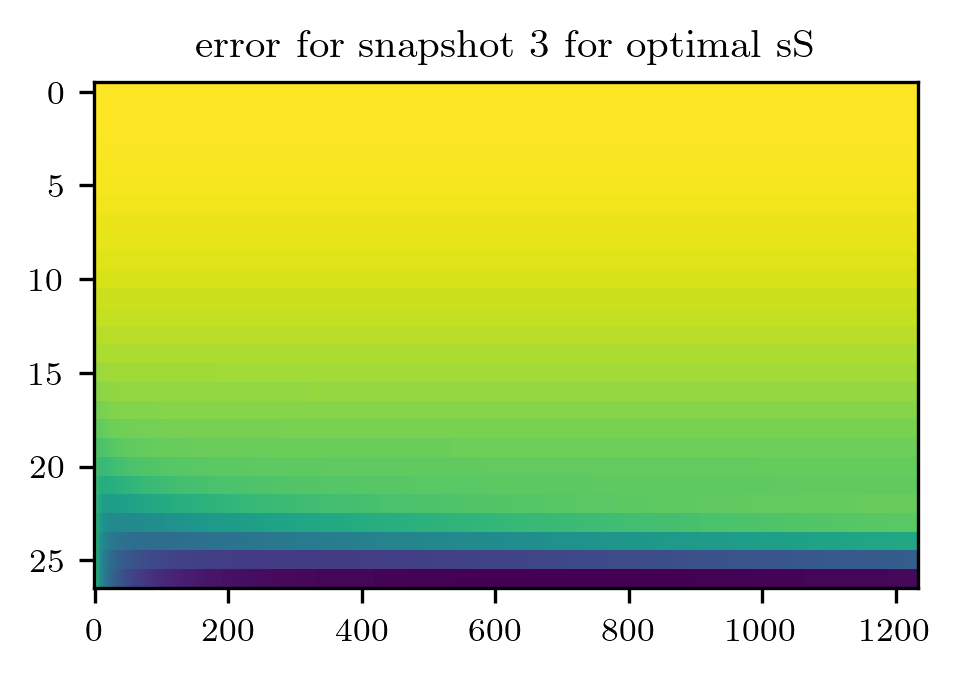

21 26 26 26 0.030853002617708347
0 0.0 21 0.052708286914949574
1 0.2 22 0.05042370603208639
2 0.4 23 0.04752005019870844
3 0.6 24 0.04347012674885216
4 0.8 25 0.03705166094576562
5 1.0 26 0.030853002617708347


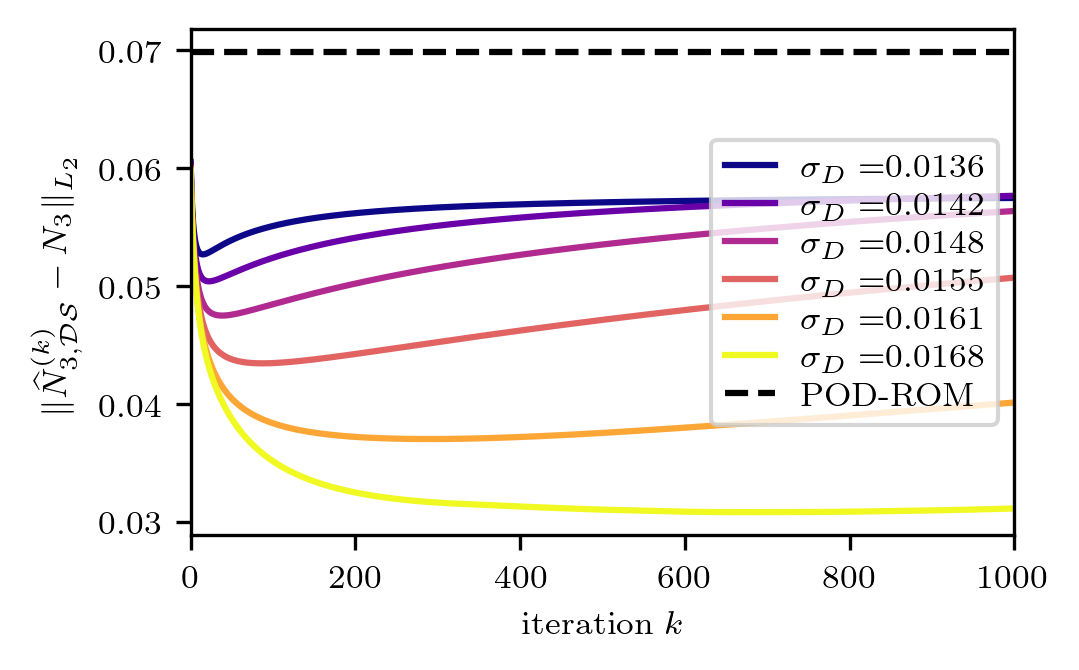

0 0.0 21 0.052708286914949574
1 0.2 22 0.05042370603208639
2 0.4 23 0.04752005019870844
3 0.6 24 0.04347012674885216
4 0.8 25 0.03705166094576562
5 1.0 26 0.030853002617708347


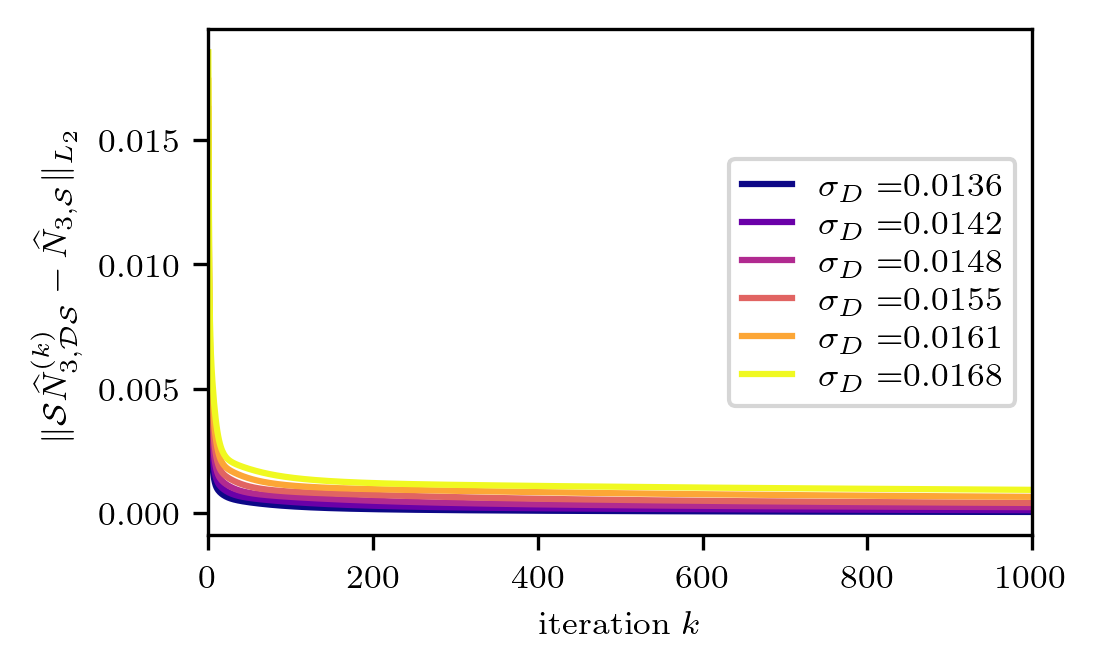

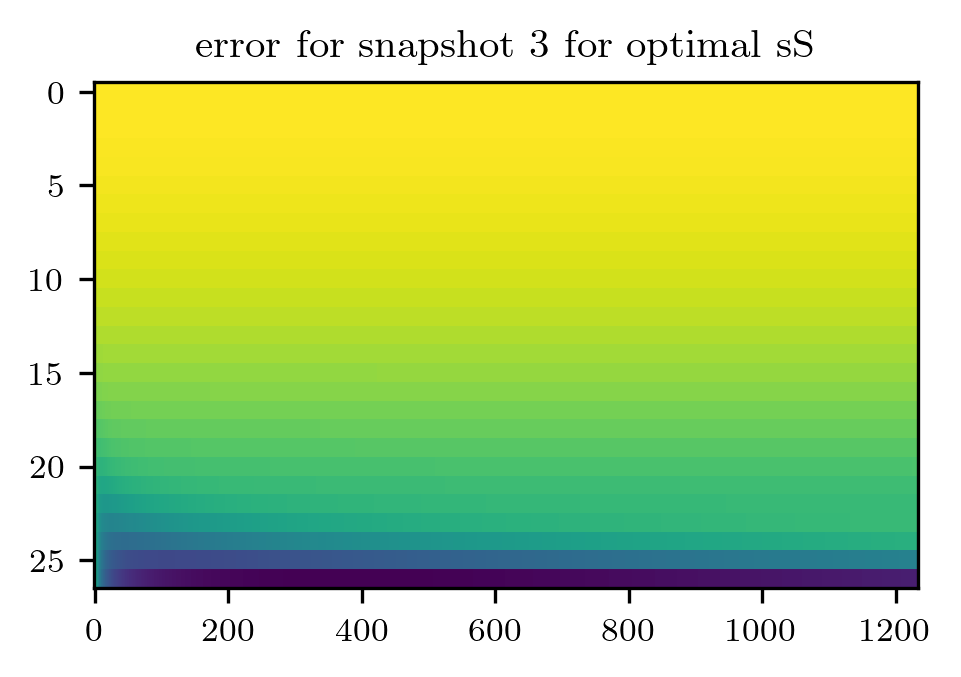

22 26 26 26 0.036810484217922296
0 0.0 21 0.05483909625570079
1 0.2 22 0.052909064032013065
2 0.4 23 0.05057566378454684
3 0.6 24 0.04761036567484207
4 0.8 25 0.043453717109775795
5 1.0 26 0.036810484217922296


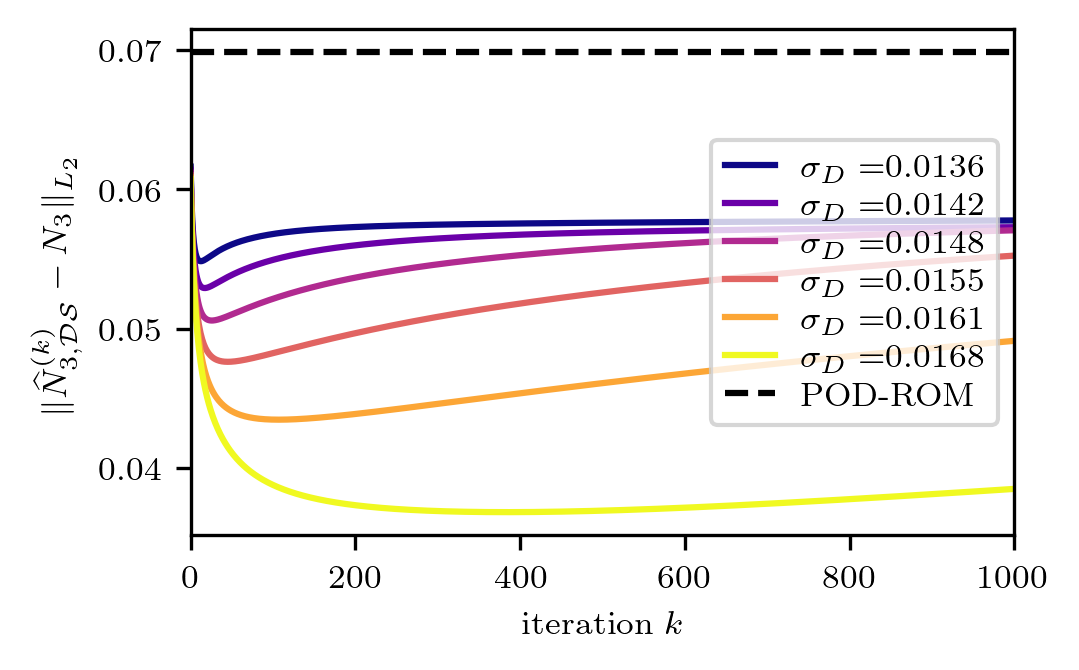

0 0.0 21 0.05483909625570079
1 0.2 22 0.052909064032013065
2 0.4 23 0.05057566378454684
3 0.6 24 0.04761036567484207
4 0.8 25 0.043453717109775795
5 1.0 26 0.036810484217922296


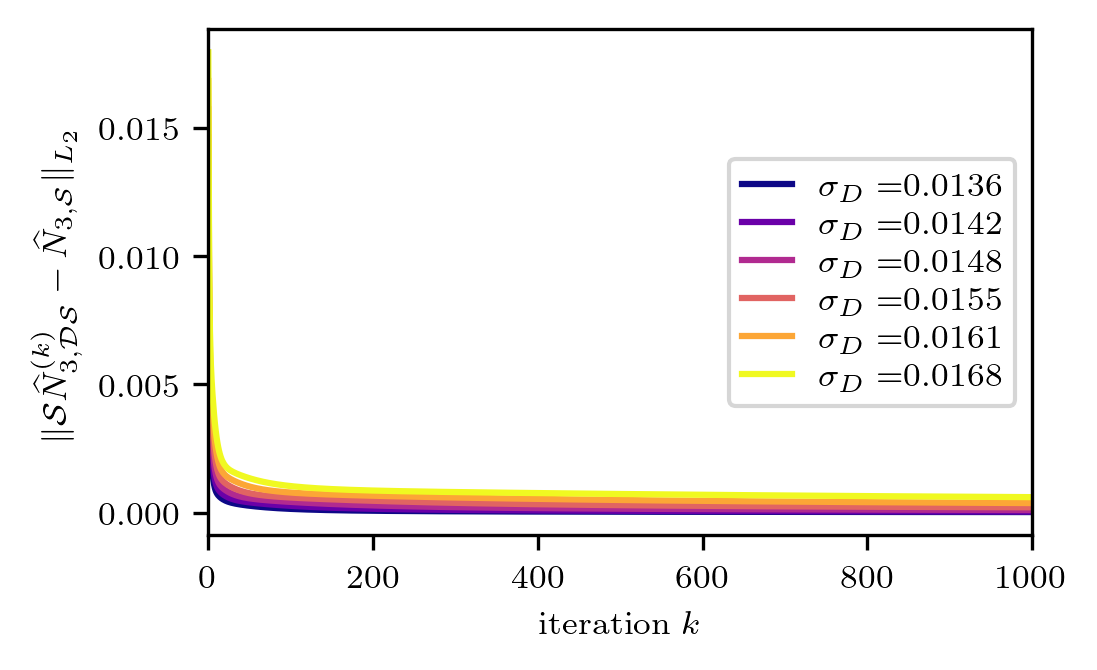

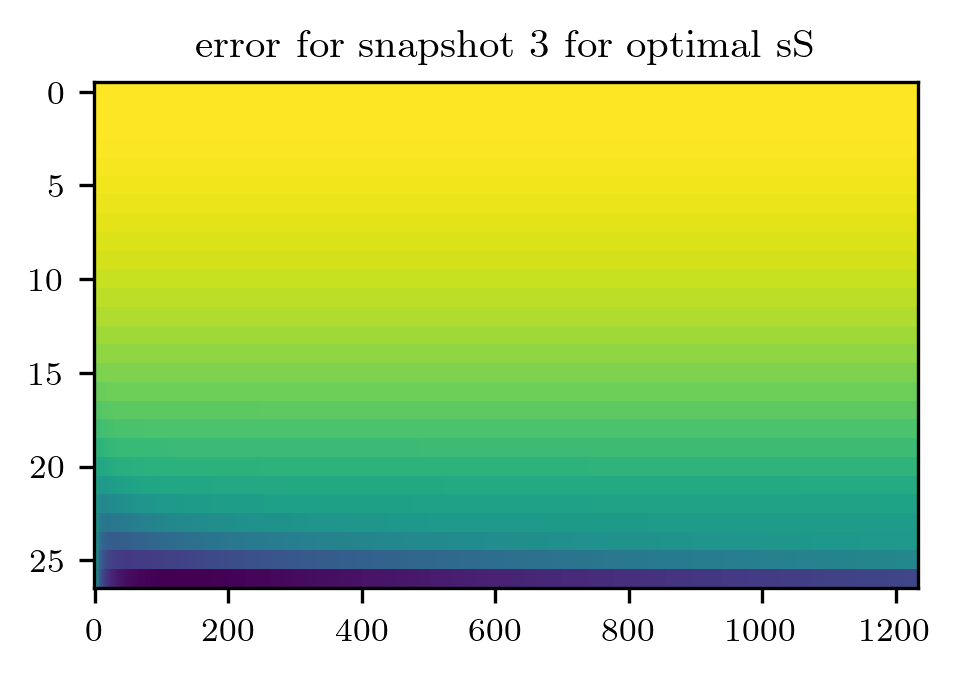

23 26 26 26 0.043494042559721016
0 0.0 21 0.05678992236509495
1 0.2 22 0.05511241420339557
2 0.4 23 0.05314293097660506
3 0.6 24 0.05076429731494793
4 0.8 25 0.04774430838253432
5 1.0 26 0.043494042559721016


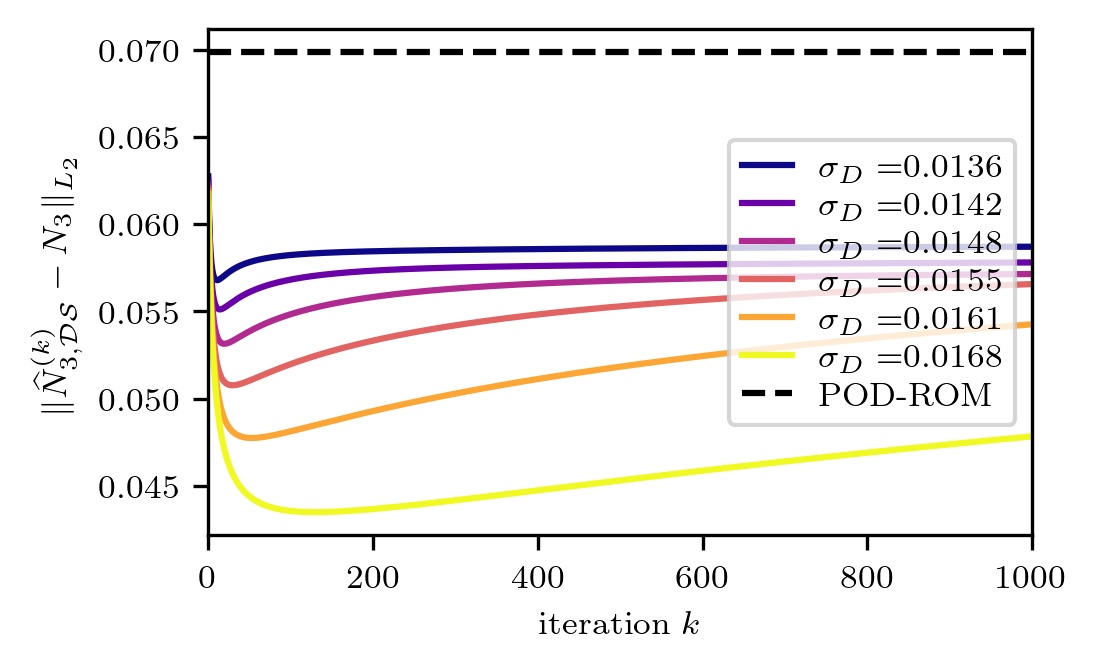

0 0.0 21 0.05678992236509495
1 0.2 22 0.05511241420339557
2 0.4 23 0.05314293097660506
3 0.6 24 0.05076429731494793
4 0.8 25 0.04774430838253432
5 1.0 26 0.043494042559721016


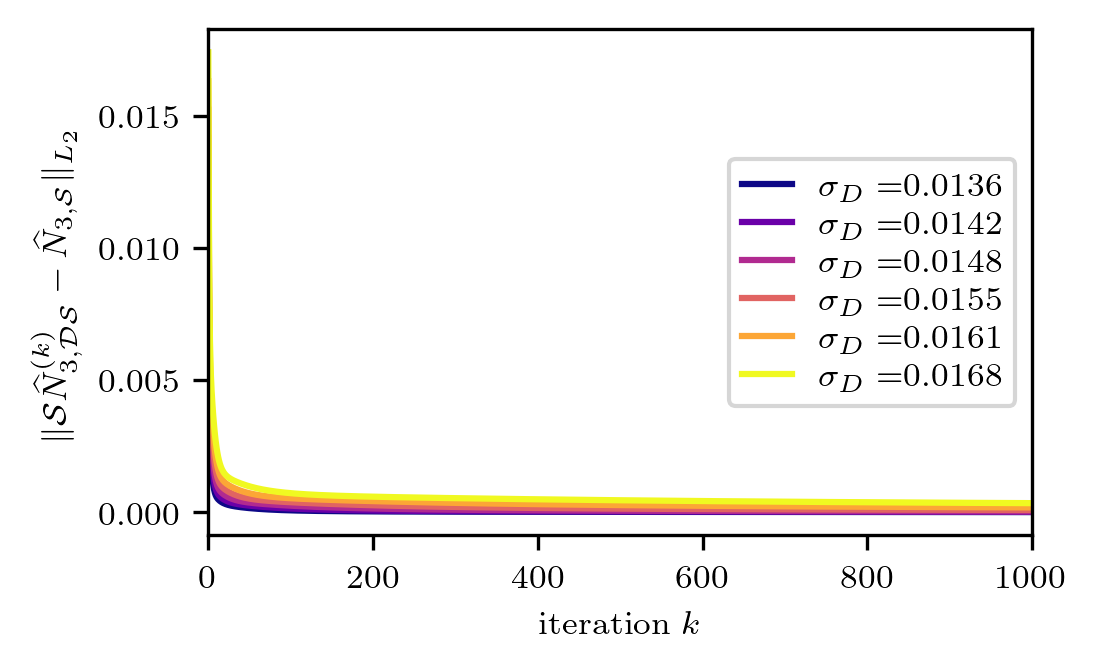

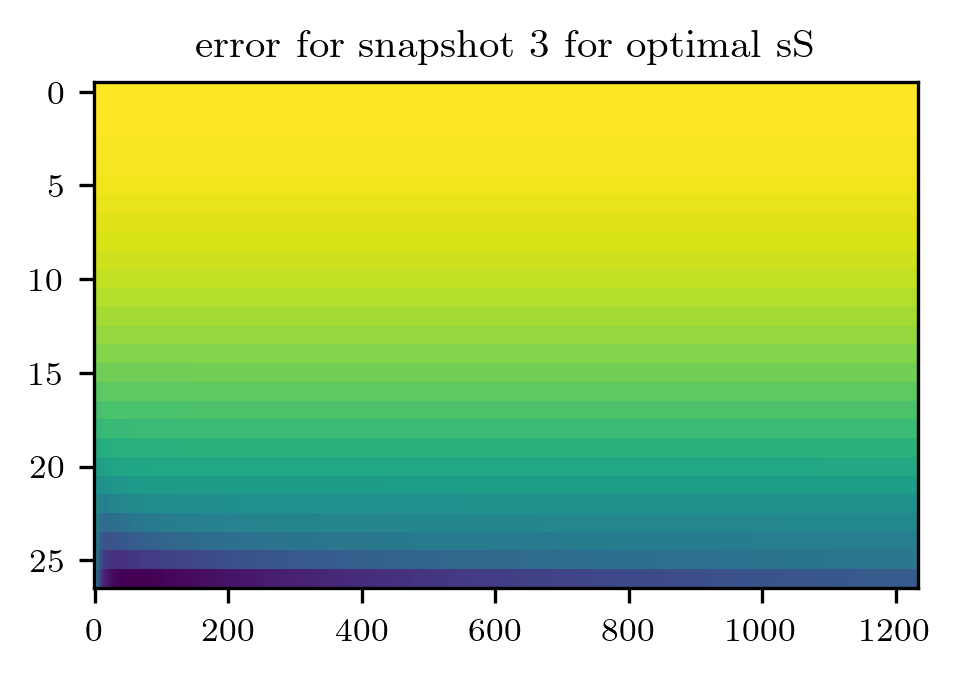

24 26 26 26 0.0479161599436727
0 0.0 21 0.05861334021214659
1 0.2 22 0.05712466008454132
2 0.4 23 0.05541125794910019
3 0.6 24 0.053403127864515856
4 0.8 25 0.05098433243379096
5 1.0 26 0.0479161599436727


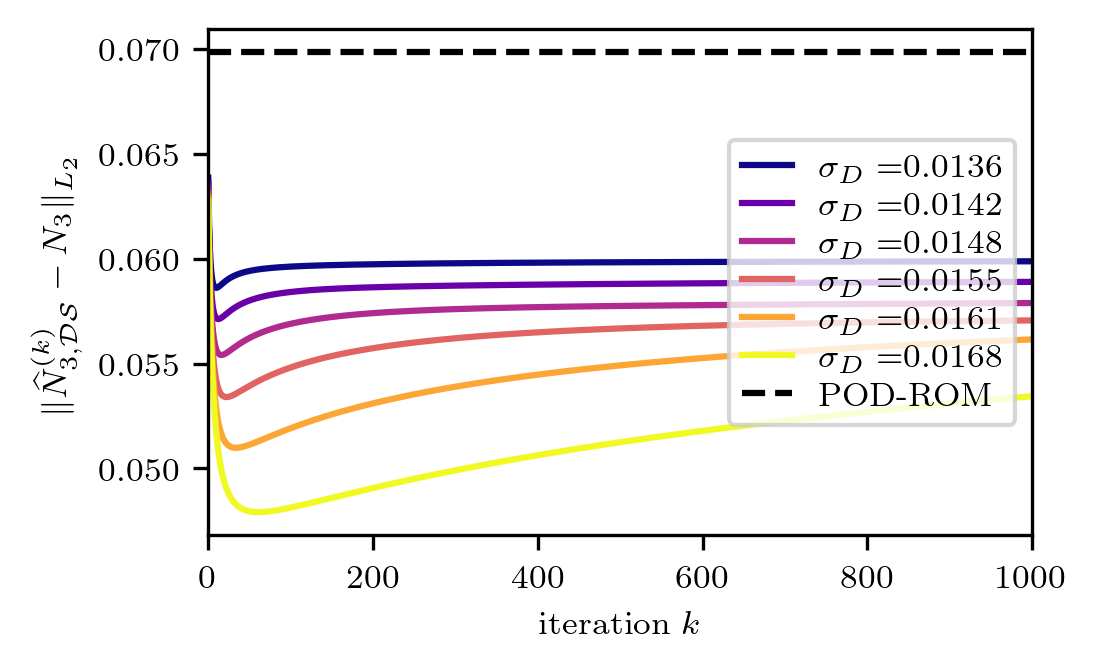

0 0.0 21 0.05861334021214659
1 0.2 22 0.05712466008454132
2 0.4 23 0.05541125794910019
3 0.6 24 0.053403127864515856
4 0.8 25 0.05098433243379096
5 1.0 26 0.0479161599436727


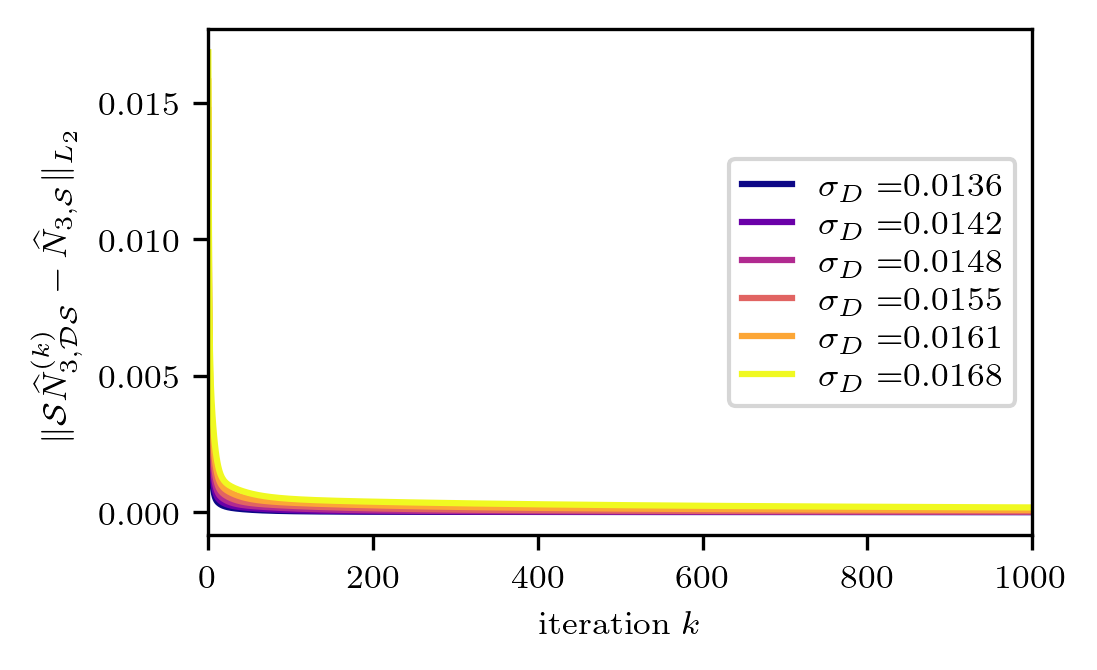

In [17]:
for isS in range(n_sS):
    fig, ax = plt.subplots()
    plt.imshow(error[isS, :, 3, :], interpolation="nearest")
    ax.set_aspect("auto")
    plt.title("error for snapshot 3 for optimal sS")
    plt.show()

    i_sDopt100 = np.argmin(error[isS, :, i_mu, 99])
    i_sDopt200 = np.argmin(error[isS, :, i_mu, 199])
    i_sDopt1000 = np.argmin(error[isS, :, i_mu, 999])
    
    print(isS, i_sDopt100, i_sDopt200, i_sDopt1000, np.min(error[isS, :, i_mu, :]))
    i_sD_all = np.arange(i_sDopt200-5, min(i_sDopt200+6, n_sD), 1)

    fig, ax = plt.subplots()
    for c, isD in enumerate(i_sD_all):
        print(c, c/(len(i_sD_all)-1), isD, np.min(error[isS, isD, i_mu, :]))
        plt.plot(iters, error[isS, isD, i_mu, :], label=r"$\sigma_D=$"+"{:.4f}".format(sD_all[isD]), color=cmap(c/(len(i_sD_all)-1)))
    plt.plot(iters, iters*0+e_ROM[i_mu], "k--", label="POD-ROM")
    plt.legend(loc="center right")
    #plt.title("error for snapshot 3 for optimal sS")
    plt.xlabel(r"iteration $k$")
    plt.ylabel(r"$\|\widehat{N}_{3,\mathcal{DS}}^{(k)} - N_{3}\|_{L_2}$")
    plt.xlim(0, 1000)
    if isS == i_sSopt:
        plt.savefig("../Plots/convergenceRL.pdf")
    plt.show()

    fig, ax = plt.subplots()
    for c, isD in enumerate(i_sD_all):
        print(c, c/(len(i_sD_all)-1), isD, np.min(error[isS, isD, i_mu, :]))
        plt.plot(iters, internal_error[isS, isD, i_mu, :], label=r"$\sigma_D=$"+"{:.4f}".format(sD_all[isD]), color=cmap(c/(len(i_sD_all)-1)))
    #plt.plot(iters, iters*0+e_ROM[i_mu], "k--", label="POD-ROM")
    plt.legend(loc="center right")
    #plt.title("error for snapshot 3 for optimal sS")
    plt.xlabel(r"iteration $k$")
    plt.ylabel(r"$\|\mathcal{S} \widehat{N}_{3,\mathcal{DS}}^{(k)} - \widehat{N}_{3,\mathcal{S}}\|_{L_2}$")
    plt.xlim(0, 1000)
    if isS == i_sSopt:
        plt.savefig("../Plots/convergenceRL2.pdf")
    plt.show()


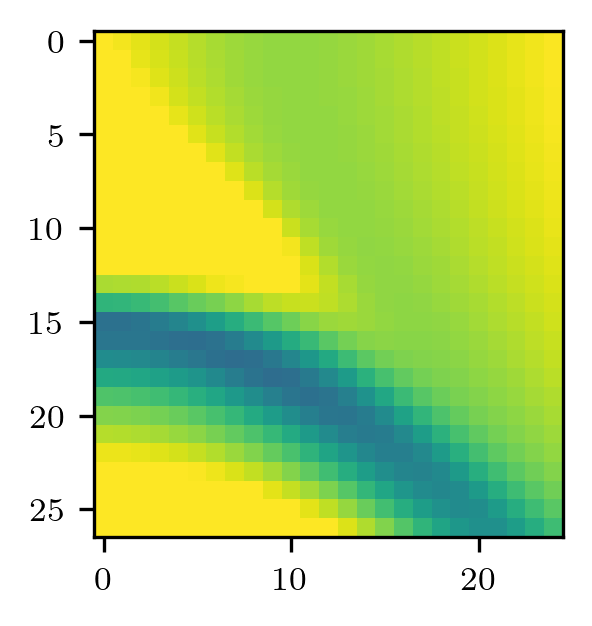

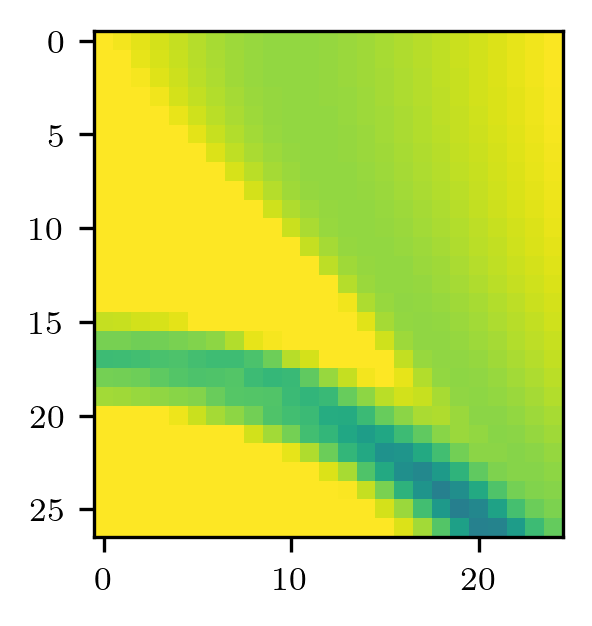

In [18]:
# best sS, sD for snapshot 3, fixed sD, 100 iter:
fig, ax = plt.subplots()
plt.imshow(error[:, :, 3, 100].T, vmin=0, vmax=vmax[3])
plt.show()

# best sS, sD for snapshot 3, fixed sD, 1000 iter:
fig, ax = plt.subplots()
plt.imshow(error[:, :, 3, 1000].T, vmin=0, vmax=vmax[3])
plt.show()

